# Power Outage Prediction EDA
#
**Goal:** Explore the relationship between power outages (`customers_out`, `severity`) and weather conditions, particularly extreme/rare events, to inform the development of a predictive model.

**Dataset:** Daily county-level power outage and weather data for US territories (2015-2024).

**Libraries:**

In [1]:
!wget "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_500k.zip"
!unzip cb_2020_us_county_500k.zip

--2025-04-27 12:21:38--  https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_500k.zip
Resolving www2.census.gov (www2.census.gov)... 172.65.90.24, 172.65.90.26, 172.65.90.27, ...
Connecting to www2.census.gov (www2.census.gov)|172.65.90.24|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12587934 (12M) [application/zip]
Saving to: ‘cb_2020_us_county_500k.zip’

cb_2020_us_county_5 100%[===================>]  12.00M  --.-KB/s    in 0.1s    

2025-04-27 12:21:39 (95.8 MB/s) - ‘cb_2020_us_county_500k.zip’ saved [12587934/12587934]

Archive:  cb_2020_us_county_500k.zip
  inflating: cb_2020_us_county_500k.shp.ea.iso.xml  
  inflating: cb_2020_us_county_500k.shp.iso.xml  
  inflating: cb_2020_us_county_500k.shp  
  inflating: cb_2020_us_county_500k.shx  
  inflating: cb_2020_us_county_500k.dbf  
  inflating: cb_2020_us_county_500k.prj  
 extracting: cb_2020_us_county_500k.cpg  


In [2]:
!pip install -q datasets umap-learn missingno statsmodels geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.6/323.6 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 128.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19

In [3]:
#%load_ext cudf.pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import ccf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from scipy.stats import spearmanr, pearsonr

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from datasets import load_dataset

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    print("umap-learn library not found. Skipping UMAP visualization.(OR install it, run:`!pip install -q umap-learn`")
    UMAP_AVAILABLE = False

import geopandas as gpd
GEOPANDAS_AVAILABLE = True

from tqdm.notebook import tqdm
import gc
import os
import warnings



# Ignore all warnings
warnings.filterwarnings("ignore")

# Set plot style and defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.options.display.max_columns = None # To show all

---
## A. Basic Data Inspection & Cleaning Prep
---

In [4]:
ds = load_dataset("mhdaw/US-PowerOutages-daily-mean")

df_train = ds["train"].to_pandas()
df_val = ds["validation"].to_pandas()
df_test = ds["test"].to_pandas()

README.md:   0%|          | 0.00/4.29k [00:00<?, ?B/s]

train-00000-of-00003.parquet:   0%|          | 0.00/50.7M [00:00<?, ?B/s]

train-00001-of-00003.parquet:   0%|          | 0.00/51.4M [00:00<?, ?B/s]

train-00002-of-00003.parquet:   0%|          | 0.00/54.2M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/28.3M [00:00<?, ?B/s]

test-00000-of-00002.parquet:   0%|          | 0.00/39.3M [00:00<?, ?B/s]

test-00001-of-00002.parquet:   0%|          | 0.00/39.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3763749 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/758056 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1716557 [00:00<?, ? examples/s]

In [5]:
df = df_train.copy() # smallest is val, we use sample to handle largness.

if 'log_customers_out' not in df.columns and 'customers_out' in df.columns:
     df['log_customers_out'] = np.log1p(df['customers_out'])

# column groups
target_col = 'customers_out'
log_target_col = 'log_customers_out'
severity_col = 'severity' # Categorical severity
weather_num_cols = ['tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wspd']
event_cols = [col for col in df.columns if col.startswith('event_count')]
geo_cols = ['state', 'county', 'fips_code']
time_features = ['year', 'month', 'day', 'hour', 'dayofweek','dayofyear', 'weekofyear', 'quarter', 'season', 'is_weekend']

# Filter out non-existent columns from lists
weather_num_cols = [col for col in weather_num_cols if col in df.columns]
event_cols = [col for col in event_cols if col in df.columns]
geo_cols = [col for col in geo_cols if col in df.columns]

# Ensure severity exists and is categorical
if severity_col in df.columns and not pd.api.types.is_categorical_dtype(df[severity_col]):
    df[severity_col] = df[severity_col].astype('category')

print(f"Using Target: {target_col}, Log Target: {log_target_col}")
print(f"Weather Cols: {weather_num_cols}")
print(f"Event Cols: {len(event_cols)}")
print(f"Geo Cols: {geo_cols}")

Using Target: customers_out, Log Target: log_customers_out
Weather Cols: ['tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wspd']
Event Cols: 55
Geo Cols: ['state', 'county', 'fips_code']


In [6]:
# 2. Initial Overview
print("--- Initial Overview ---")
print(f"Dataset Shape: {df.shape}")

print("\n-Data Type")
print(df.info()) # .info() is more comprehensive than .dtypes

# Ensure 'time' is datetime
if not pd.api.types.is_datetime64_any_dtype(df['time']):
    print("\nConverting 'time' column to datetime...")
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    # Check if conversion introduced NaNs
    if df['time'].isnull().any():
        print("Warning: Errors encountered during 'time' conversion, NaNs introduced.")

# Ensure 'fips_code' is treated as a string/object identifier
if pd.api.types.is_numeric_dtype(df['fips_code']):
    print("\nConverting 'fips_code' to string type...")
    # Handle potential leading zeros if read as integer
    try:
        df['fips_code'] = df['fips_code'].astype(int).astype(str).str.zfill(5)
    except:
        print("Could not convert FIPS code using zfill, converting directly to string.")
        df['fips_code'] = df['fips_code'].astype(str)
elif not pd.api.types.is_string_dtype(df['fips_code']):
     df['fips_code'] = df['fips_code'].astype(str)

print(f"\nFIPS Code data type: {df['fips_code'].dtype}")
print(f"Sample FIPS codes: {df['fips_code'].unique()[:5]}")

--- Initial Overview ---
Dataset Shape: (3763749, 79)

-Data Type
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3763749 entries, 0 to 3763748
Data columns (total 79 columns):
 #   Column                                  Dtype         
---  ------                                  -----         
 0   fips_code                               int32         
 1   time                                    datetime64[ns]
 2   county                                  object        
 3   state                                   object        
 4   customers_out                           float32       
 5   event_count_Astronomical Low Tide       float32       
 6   event_count_Avalanche                   float32       
 7   event_count_Blizzard                    float32       
 8   event_count_Coastal Flood               float32       
 9   event_count_Cold/Wind Chill             float32       
 10  event_count_Debris Flow                 float32       
 11  event_count_Dense Fog               

In [7]:
# TO DO: Drop all NUll cols

In [8]:
# 3. Missing Value Analysis
print("\n--- Missing Value Analysis ---")
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

if not missing_percentage.empty:
    print("Percentage of Missing Values per Column (> 0%):")
    print(missing_percentage)

    #print("\nVisualizing Missing Data Patterns:")
    #msno.matrix(df.sample(min(10000, len(df)))) # Sample for performance cuz large dataset
    #plt.title('Missing Data Matrix (Sampled)')
    #plt.show()

    #msno.heatmap(df)
    #plt.title('Missing Data Correlation Heatmap')
    #plt.show()
else:
    print("No missing values found.")


--- Missing Value Analysis ---
Percentage of Missing Values per Column (> 0%):
event_count_Marine Lightning              100.000000
event_count_Tsunami                        87.099884
event_count_Volcanic Ashfall               82.300626
event_count_Hurricane (Typhoon)            72.030627
snow                                       59.807229
event_count_Marine Dense Fog               53.597676
prcp                                       52.174840
event_count_Dense Smoke                    15.069257
event_count_Marine Hurricane/Typhoon       14.767297
event_count_Marine Tropical Storm          14.767297
event_count_Marine Tropical Depression     14.767297
event_count_Hurricane                      14.767297
event_count_Lakeshore Flood                14.767297
event_count_Seiche                         14.494617
wspd                                        4.552110
event_count_Excessive Heat                  1.867181
event_count_Dust Devil                      1.867181
event_count_Tropica

In [9]:
# 4. Duplicate Check
print("\nDuplicate Check")
n_duplicates = df.duplicated().sum()
print(f"Number of fully duplicate rows: {n_duplicates}")
if n_duplicates > 0:
    print("Investigating duplicate rows...")
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head())


Duplicate Check
Number of fully duplicate rows: 0


In [10]:
# 5. Basic Statistics
print("\nDescriptive Statistics (Numerical) ---")
# Identify numerical columns (excluding identifiers like year, month etc.)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
time_features = ['year', 'month', 'day', 'hour', 'dayofweek', 'dayofyear', 'weekofyear', 'quarter']

numerical_cols_for_desc = [col for col in numerical_cols if col not in time_features + ['is_weekend']]
print(df[numerical_cols_for_desc].describe().T)

print("\nDescriptive Statistics (Categorical/Object) ---")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(df[categorical_cols].describe().T)

print("\nUnique Value Counts (Categorical/Identifiers) ---")
identifier_cols = ['fips_code', 'county', 'state', 'severity', 'season', 'weather_source']
for col in identifier_cols:
    if col in df.columns:
        print(f"\nUnique values in '{col}' (Top 5):")
        print(df[col].value_counts().head())
        print(f"Total unique values: {df[col].nunique()}")
        if df[col].nunique() > 1000 and col == 'county': # Avoid printing too many counties
             print("(Skipping full list for county)")


Descriptive Statistics (Numerical) ---
                                       count       mean          std  \
customers_out                      3763749.0  80.458733  1538.924438   
event_count_Astronomical Low Tide  3763749.0   0.000032     0.005897   
event_count_Avalanche              3763749.0   0.000002     0.001214   
event_count_Blizzard               3763749.0   0.000186     0.013338   
event_count_Coastal Flood          3763749.0   0.000317     0.017846   
...                                      ...        ...          ...   
tmax                               3763749.0  13.113050    12.822623   
prcp                               1800019.0   0.805044     5.532259   
snow                               1512755.0   0.018485     1.173332   
wspd                               3592419.0   6.698788     6.879704   
log_customers_out                  3763749.0   2.365490     1.570363   

                                         min       25%        50%        75%  \
customers_out  

---
## B. Univariate Analysis (Understanding Individual Variables)
---

Univariate Analysis: Target Variables


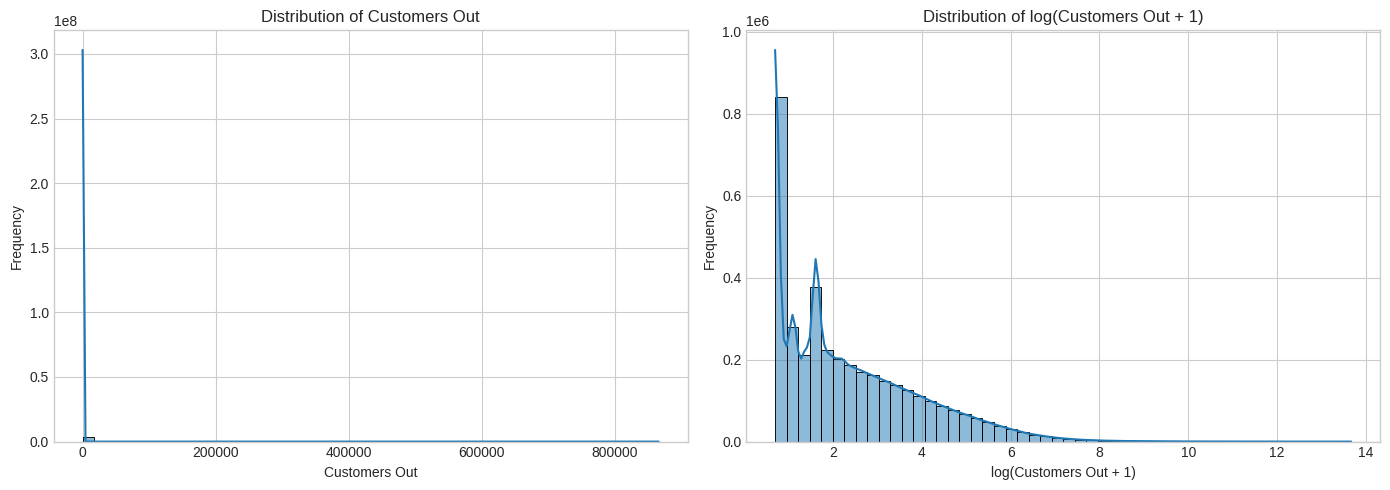

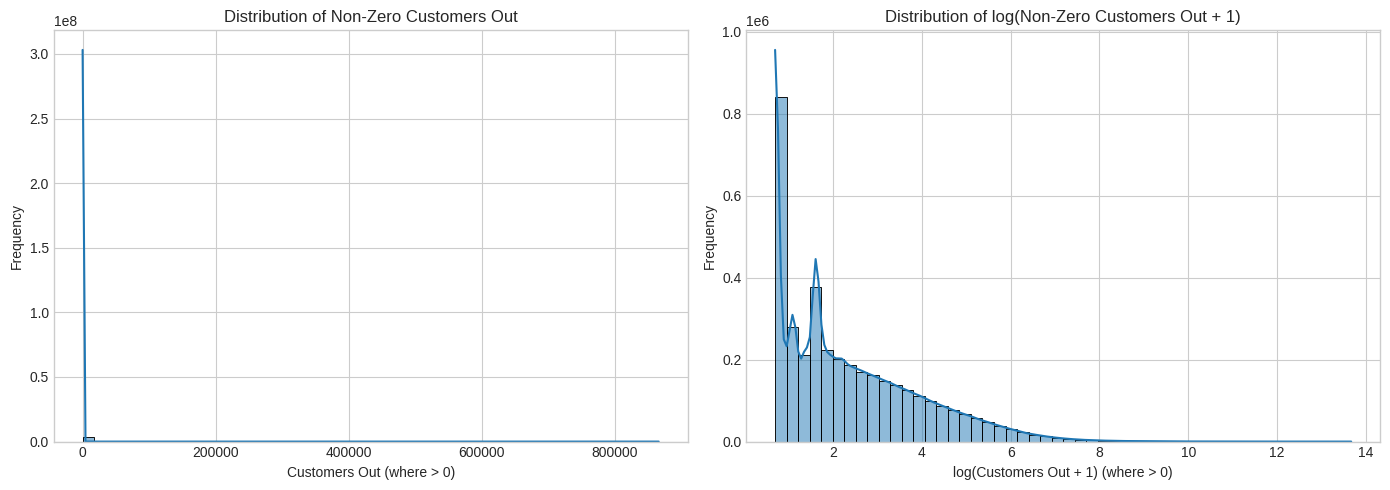

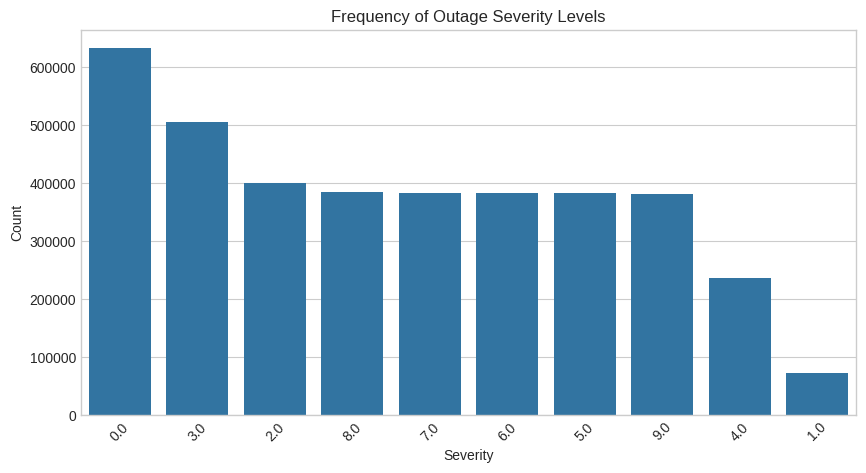

In [11]:
# 1. Target Variables (`customers_out`, `severity`)
print("Univariate Analysis: Target Variables")
target_col = 'customers_out'
severity_col = 'severity'

# Distribution of customers_out
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[target_col], kde=True, bins=50)
plt.title('Distribution of Customers Out')
plt.xlabel('Customers Out')
plt.ylabel('Frequency')

# Distribution of log(customers_out + 1) - useful for highly skewed data
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df[target_col]), kde=True, bins=50)
plt.title('Distribution of log(Customers Out + 1)')
plt.xlabel('log(Customers Out + 1)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Distribution of non-zero customers_out
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
non_zero_outages = df[df[target_col] > 0][target_col]
if not non_zero_outages.empty:
    sns.histplot(non_zero_outages, kde=True, bins=50)
    plt.title('Distribution of Non-Zero Customers Out')
    plt.xlabel('Customers Out (where > 0)')
    plt.ylabel('Frequency')
else:
    plt.text(0.5, 0.5, 'No non-zero outages found', ha='center', va='center')
    plt.title('Distribution of Non-Zero Customers Out')


# Distribution of log(non-zero customers_out)
plt.subplot(1, 2, 2)
if not non_zero_outages.empty:
    sns.histplot(np.log1p(non_zero_outages), kde=True, bins=50)
    plt.title('Distribution of log(Non-Zero Customers Out + 1)')
    plt.xlabel('log(Customers Out + 1) (where > 0)')
    plt.ylabel('Frequency')
else:
    plt.text(0.5, 0.5, 'No non-zero outages found', ha='center', va='center')
    plt.title('Distribution of log(Non-Zero Customers Out + 1)')

plt.tight_layout()
plt.show()


# Frequency of severity levels
if severity_col in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=severity_col, order=df[severity_col].value_counts().index)
    plt.title('Frequency of Outage Severity Levels')
    plt.xlabel('Severity')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()
else:
    print(f"'{severity_col}' column not found.")

Univariate Analysis: Numerical Weather Variables
Plotting distributions for numerical weather variables...


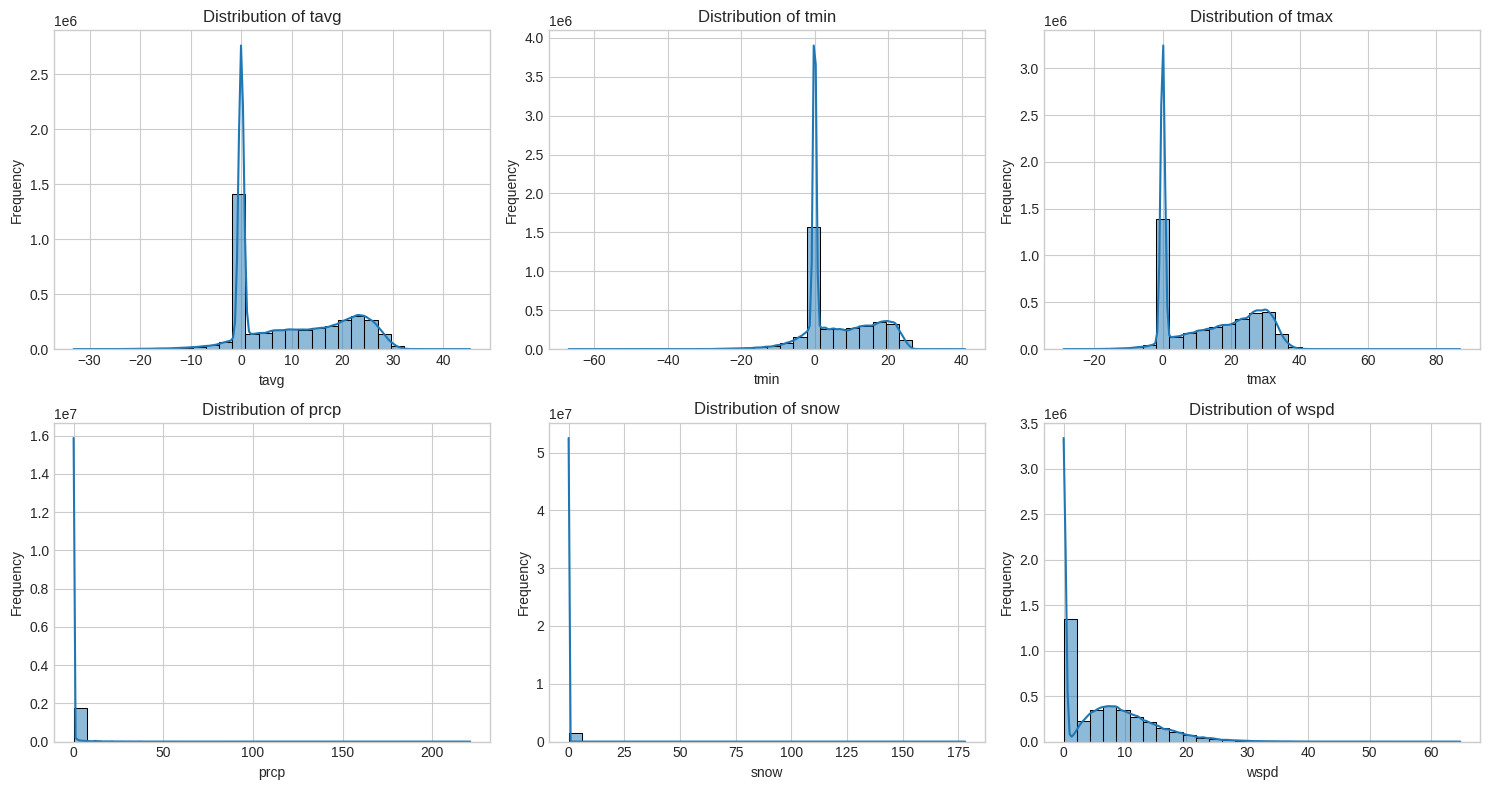


Plotting box plots for numerical weather variables...


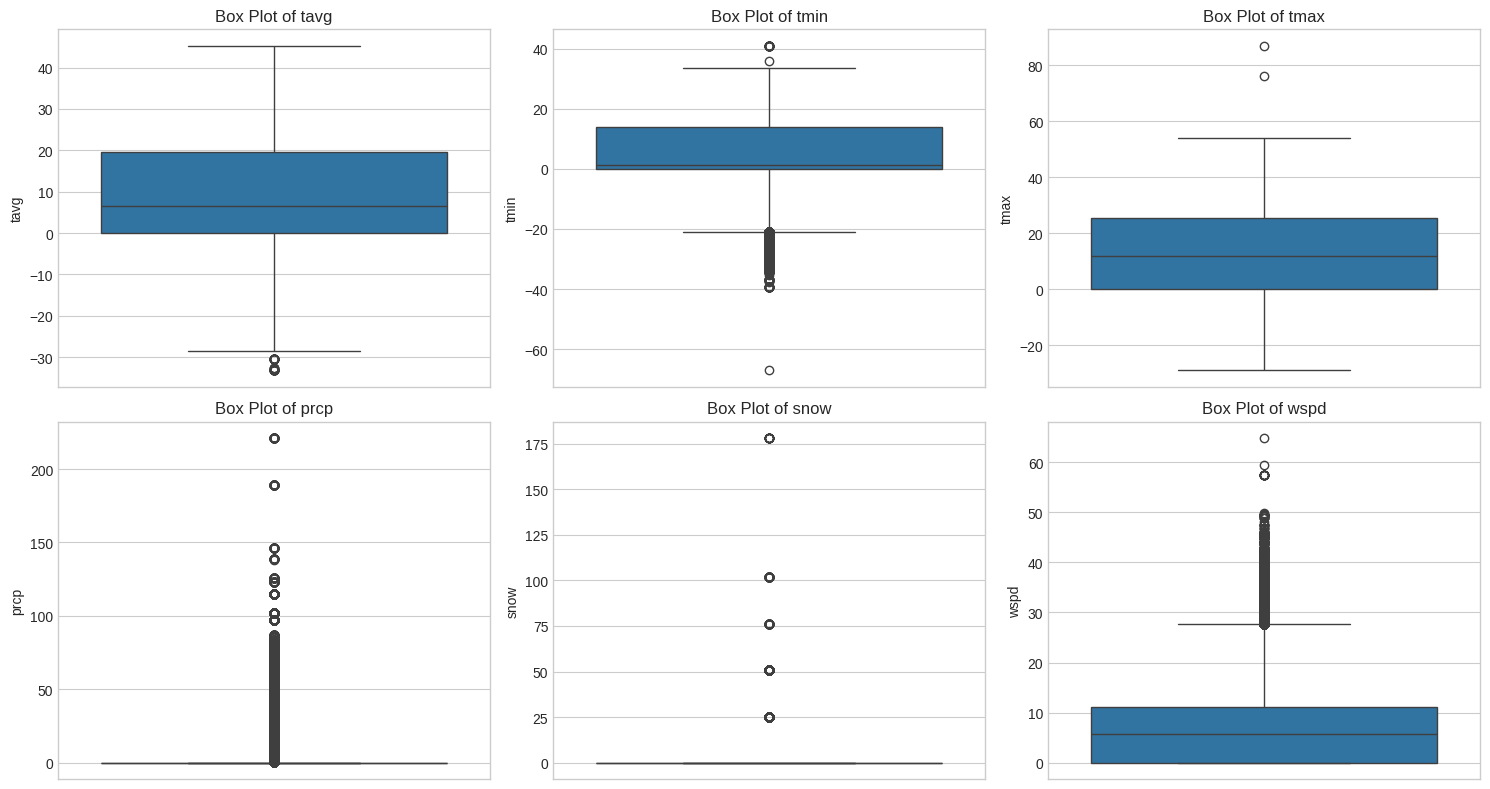

In [12]:
# 2. Weather Variables (Numerical)
print("Univariate Analysis: Numerical Weather Variables")
weather_num_cols = ['tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wspd']

# Plot distributions (Histograms and KDE)
print("Plotting distributions for numerical weather variables...")
n_cols = 3
n_rows = (len(weather_num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten() # Flatten to 1D array for easy iteration

for i, col in enumerate(weather_num_cols):
    if col in df.columns:
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
    else:
        axes[i].set_title(f'{col} not found')
        axes[i].axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Plot box plots (Identify outliers)
print("\nPlotting box plots for numerical weather variables...")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(weather_num_cols):
     if col in df.columns:
        sns.boxplot(y=df[col].dropna(), ax=axes[i])
        axes[i].set_title(f'Box Plot of {col}')
        axes[i].set_ylabel(col)
     else:
        axes[i].set_title(f'{col} not found')
        axes[i].axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Univariate Analysis: Event Count Variables
Found 55 event count columns.

Sparsity (Percentage of Days with Event > 0):
event_count_Marine Thunderstorm Wind      0.000000
event_count_Marine High Wind              0.000000
event_count_Marine Strong Wind            0.000000
event_count_Marine Tropical Storm         0.000000
event_count_Marine Dense Fog              0.000000
event_count_Marine Hail                   0.000000
event_count_Tsunami                       0.000000
event_count_Marine Lightning              0.000000
event_count_Marine Tropical Depression    0.000000
event_count_Marine Hurricane/Typhoon      0.000000
event_count_Volcanic Ashfall              0.000000
event_count_Waterspout                    0.000000
event_count_Sneakerwave                   0.000053
event_count_Freezing Fog                  0.000266
event_count_Seiche                        0.000266
event_count_Avalanche                     0.000425
event_count_Dust Devil                    0.000691
event_count_H

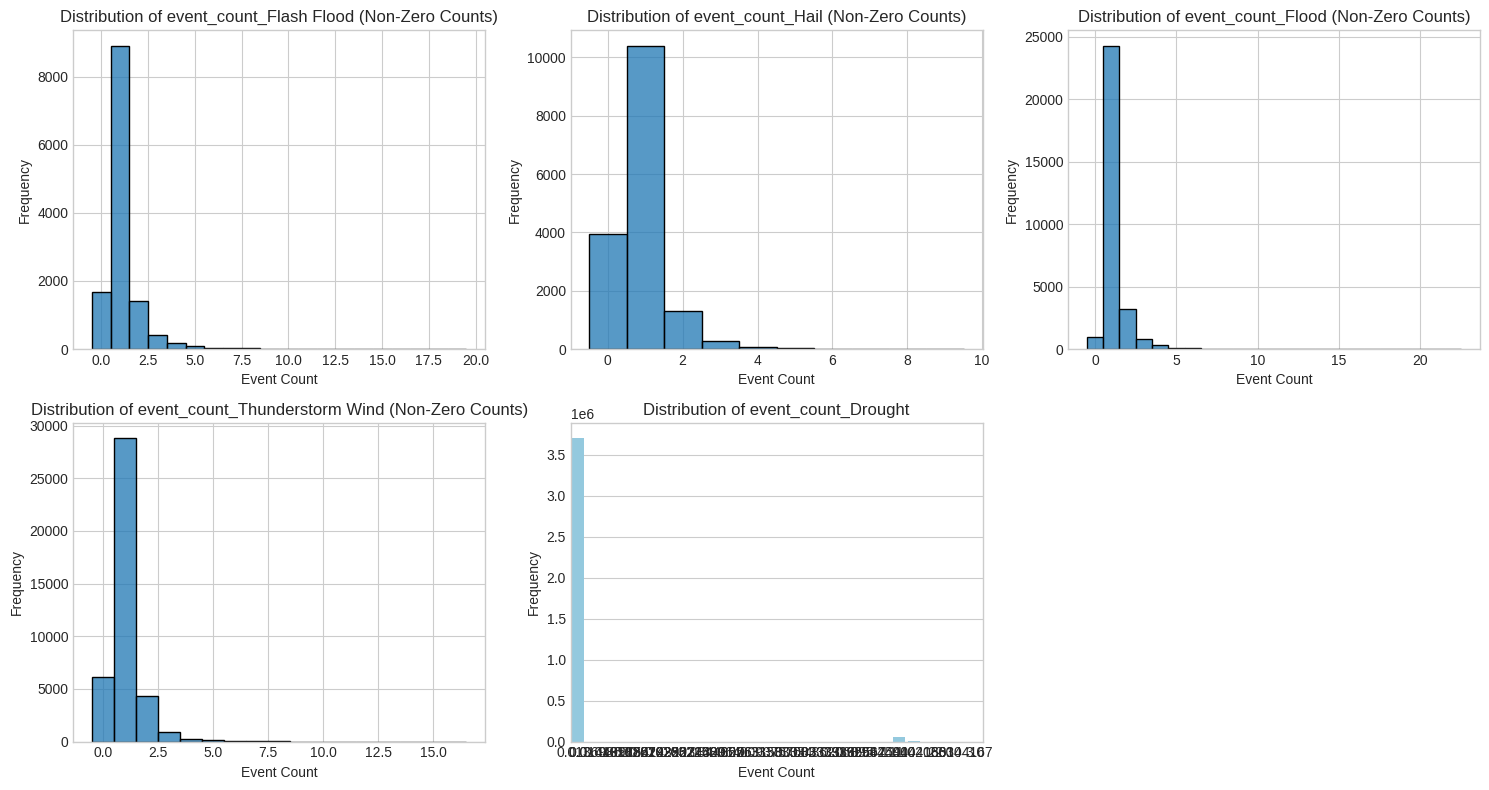

In [13]:
# 3. Event Count Variables (`event_count_*`)
print("Univariate Analysis: Event Count Variables")
event_cols = [col for col in df.columns if col.startswith('event_count')]

if not event_cols:
    print("No columns starting with 'event_count' found.")
else:
    print(f"Found {len(event_cols)} event count columns.")

    # Calculate sparsity (percentage of non-zero entries)
    sparsity = {}
    for col in event_cols:
        sparsity[col] = (df[col] > 0).mean() * 100

    sparsity_series = pd.Series(sparsity).sort_values()
    print("\nSparsity (Percentage of Days with Event > 0):")
    print(sparsity_series)

    print("\nMost Frequent Event Types (Top 10 by non-zero days):")
    print(sparsity_series.tail(10))

    print("\nLeast Frequent Event Types (Bottom 10 by non-zero days):")
    print(sparsity_series.head(10))

    cols_to_plot = sparsity_series.tail(5).index.tolist() # Plot top 5 most frequent
    print(f"\nPlotting distributions for selected event types: {cols_to_plot}")

    if cols_to_plot:
        n_plots = len(cols_to_plot)
        n_cols_hist = 3
        n_rows_hist = (n_plots + n_cols_hist - 1) // n_cols_hist
        fig_hist, axes_hist = plt.subplots(n_rows_hist, n_cols_hist, figsize=(n_cols_hist * 5, n_rows_hist * 4), squeeze=False)
        axes_hist = axes_hist.flatten()

        for i, col in enumerate(cols_to_plot):
            # Use value_counts for sparse, discrete data like counts
            counts = df[col].value_counts().sort_index()
            # Limit the number of bars if there are many unique counts (e.g., > 50)
            if len(counts) > 50:
                 # For very non-sparse counts, a histplot might be better
                 sns.histplot(df[col][df[col]>0], ax=axes_hist[i], discrete=True)
                 axes_hist[i].set_title(f'Distribution of {col} (Non-Zero Counts)')

            else:
                sns.barplot(x=counts.index, y=counts.values, ax=axes_hist[i], color='skyblue')
                axes_hist[i].set_title(f'Distribution of {col}')

            axes_hist[i].set_xlabel('Event Count')
            axes_hist[i].set_ylabel('Frequency')

        # Hide any unused subplots
        for j in range(i + 1, len(axes_hist)):
            fig_hist.delaxes(axes_hist[j])

        plt.tight_layout()
        plt.show()
    else:
        print("No event columns selected for plotting.")

Univariate Analysis: Temporal Features


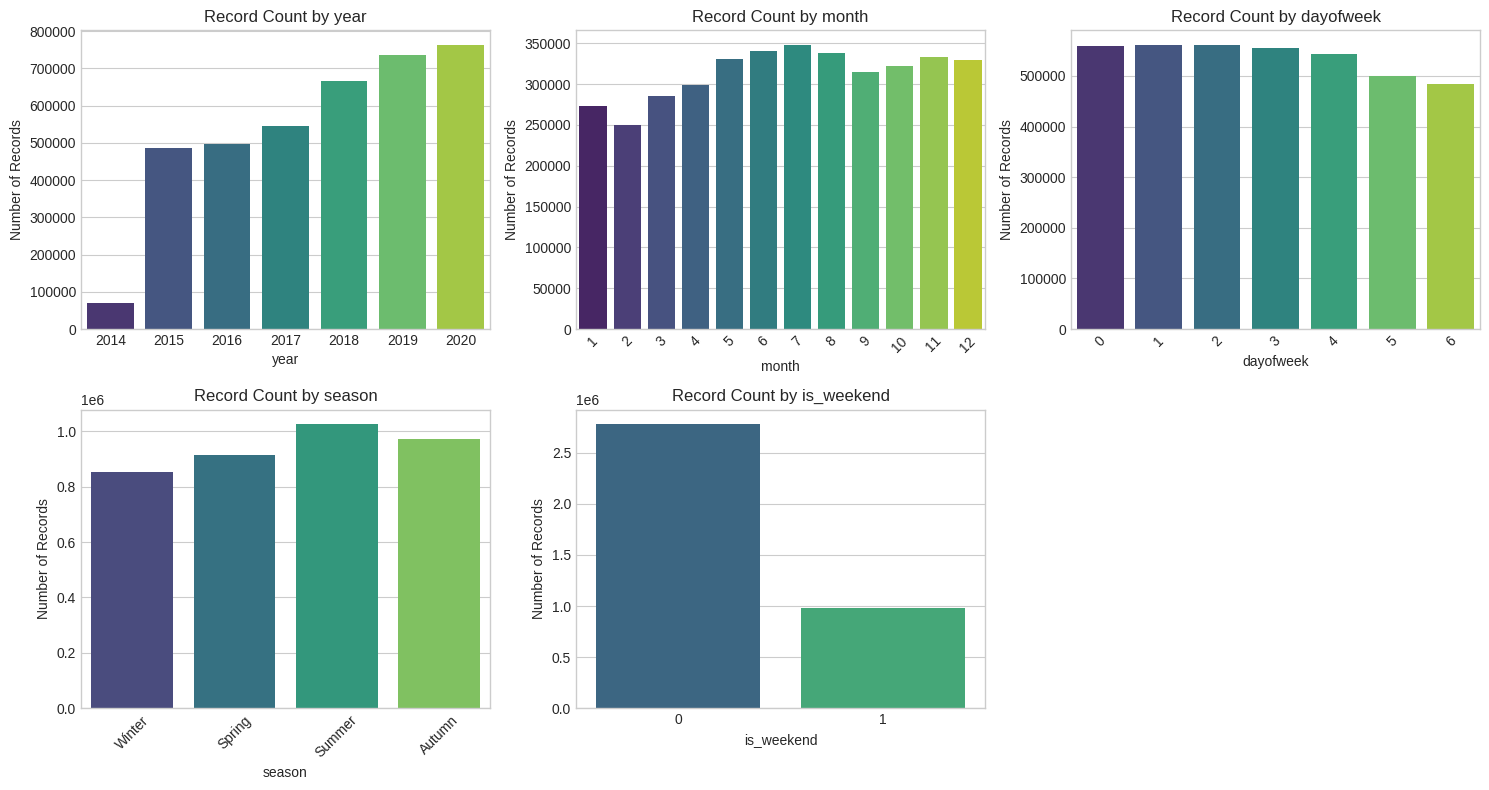

In [14]:
# 4. Temporal Features
print("Univariate Analysis: Temporal Features")
temporal_features = ['year', 'month', 'dayofweek', 'season', 'is_weekend']

n_cols_temp = 3
n_rows_temp = (len(temporal_features) + n_cols_temp - 1) // n_cols_temp
fig_temp, axes_temp = plt.subplots(n_rows_temp, n_cols_temp, figsize=(n_cols_temp * 5, n_rows_temp * 4))
axes_temp = axes_temp.flatten()

for i, col in enumerate(temporal_features):
    if col in df.columns:
        order = None
        if col == 'month': order = sorted(df[col].unique())
        if col == 'dayofweek': order = sorted(df[col].unique()) # 0=Mon, 6=Sun
        if col == 'season': order = ['Winter', 'Spring', 'Summer', 'Autumn']

        sns.countplot(data=df, x=col, ax=axes_temp[i], order=order, palette='viridis')
        axes_temp[i].set_title(f'Record Count by {col}')
        axes_temp[i].set_xlabel(col)
        axes_temp[i].set_ylabel('Number of Records')
        if col in ['month', 'dayofweek', 'season']:
             axes_temp[i].tick_params(axis='x', rotation=45)
    else:
        axes_temp[i].set_title(f'{col} not found')
        axes_temp[i].axis('off')

# Hide unused subplots
for j in range(i + 1, len(axes_temp)):
    fig_temp.delaxes(axes_temp[j])

plt.tight_layout()
plt.show()

Univariate Analysis: Geospatial Features


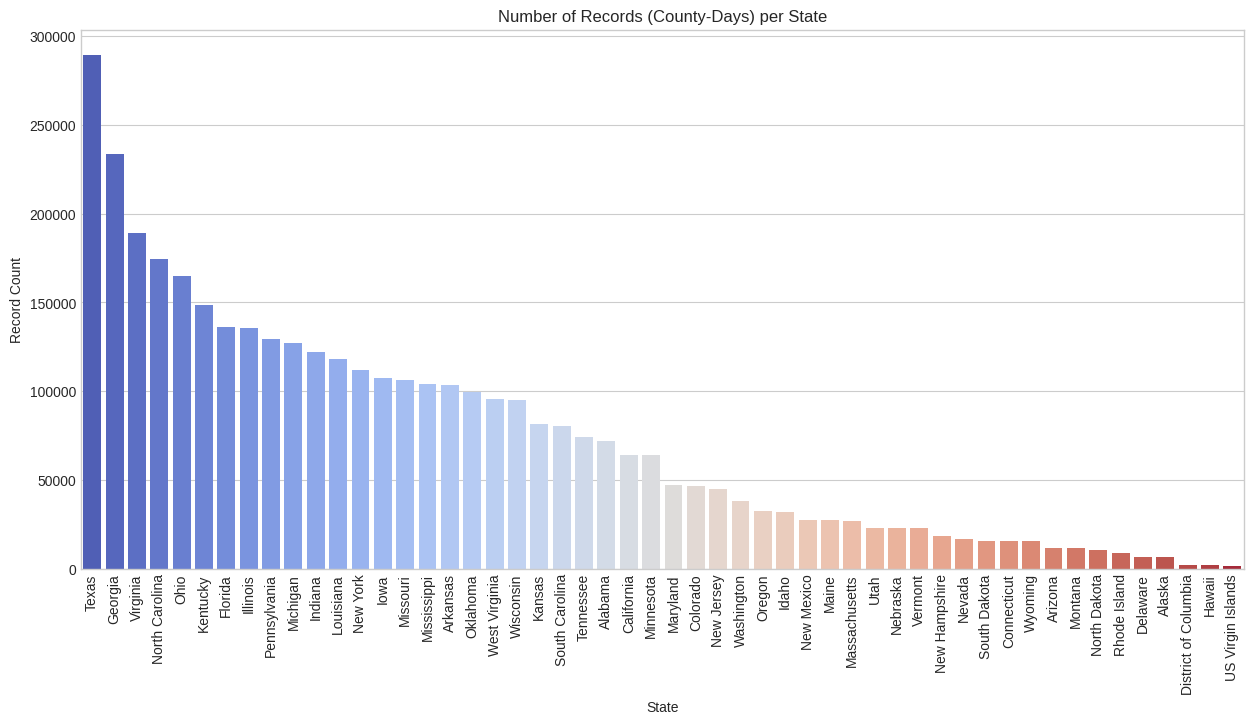


Top 30 Counties by Record Count:
county
Washington    46659
Jefferson     38069
Franklin      34660
Jackson       28919
Montgomery    28459
Madison       27515
Monroe        25731
Lincoln       24398
Marion        23962
Warren        20742
Union         20573
Wayne         18878
Greene        17640
Clay          17635
Fayette       16712
Carroll       16263
Pike          16151
Lee           16097
Orange        14895
Polk          14759
Adams         14436
Crawford      14364
Johnson       14347
Lake          13939
Henry         13774
Douglas       13724
Hancock       13516
Cass          13389
Clark         13271
Scott         12823
Name: count, dtype: int64


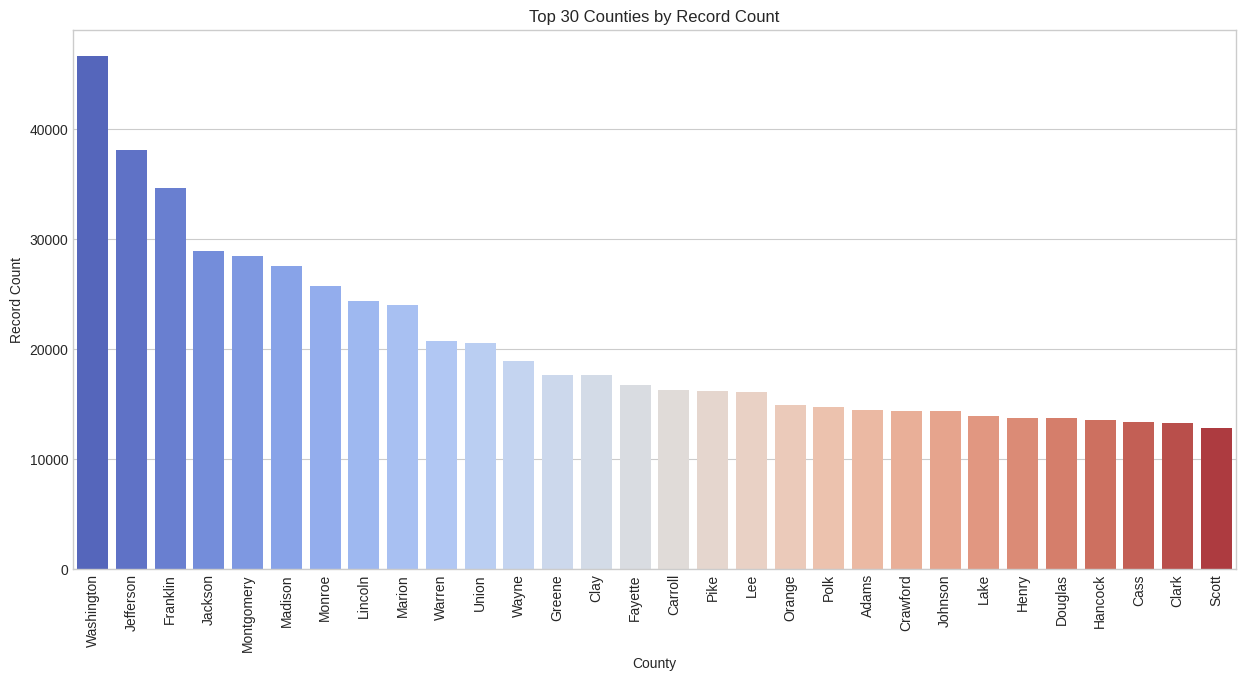

In [15]:
# 5. Geospatial Features (`state`, `county`)
print("Univariate Analysis: Geospatial Features")

# Records per State
if 'state' in df.columns:
    plt.figure(figsize=(15, 7))
    state_counts = df['state'].value_counts()
    sns.barplot(x=state_counts.index, y=state_counts.values, palette='coolwarm')
    plt.title('Number of Records (County-Days) per State')
    plt.xlabel('State')
    plt.ylabel('Record Count')
    plt.xticks(rotation=90)
    plt.show()
else:
    print("'state' column not found.")

# Records per County (Top N)
if 'county' in df.columns:
    county_counts = df['county'].value_counts()
    n_top_counties = 30
    print(f"\nTop {n_top_counties} Counties by Record Count:")
    print(county_counts.head(n_top_counties))

    if county_counts.nunique() > 1: # Check if there's more than one county to plot
        plt.figure(figsize=(15, 7))
        top_counties = county_counts.head(n_top_counties)
        sns.barplot(x=top_counties.index, y=top_counties.values, palette='coolwarm')
        plt.title(f'Top {n_top_counties} Counties by Record Count')
        plt.xlabel('County')
        plt.ylabel('Record Count')
        plt.xticks(rotation=90)
        plt.show()
    else:
        print("Only one unique county found, skipping county plot.")
else:
    print("'county' column not found.")

---
## C. Bivariate Analysis (Relationships between Two Variables)
---
Using log-transformed target for visualization where appropriate due to skewness

Bivariate Analysis: Target vs. Numerical Weather
Plotting scatter plots for Target vs Weather (using 10.0% sample if large)...


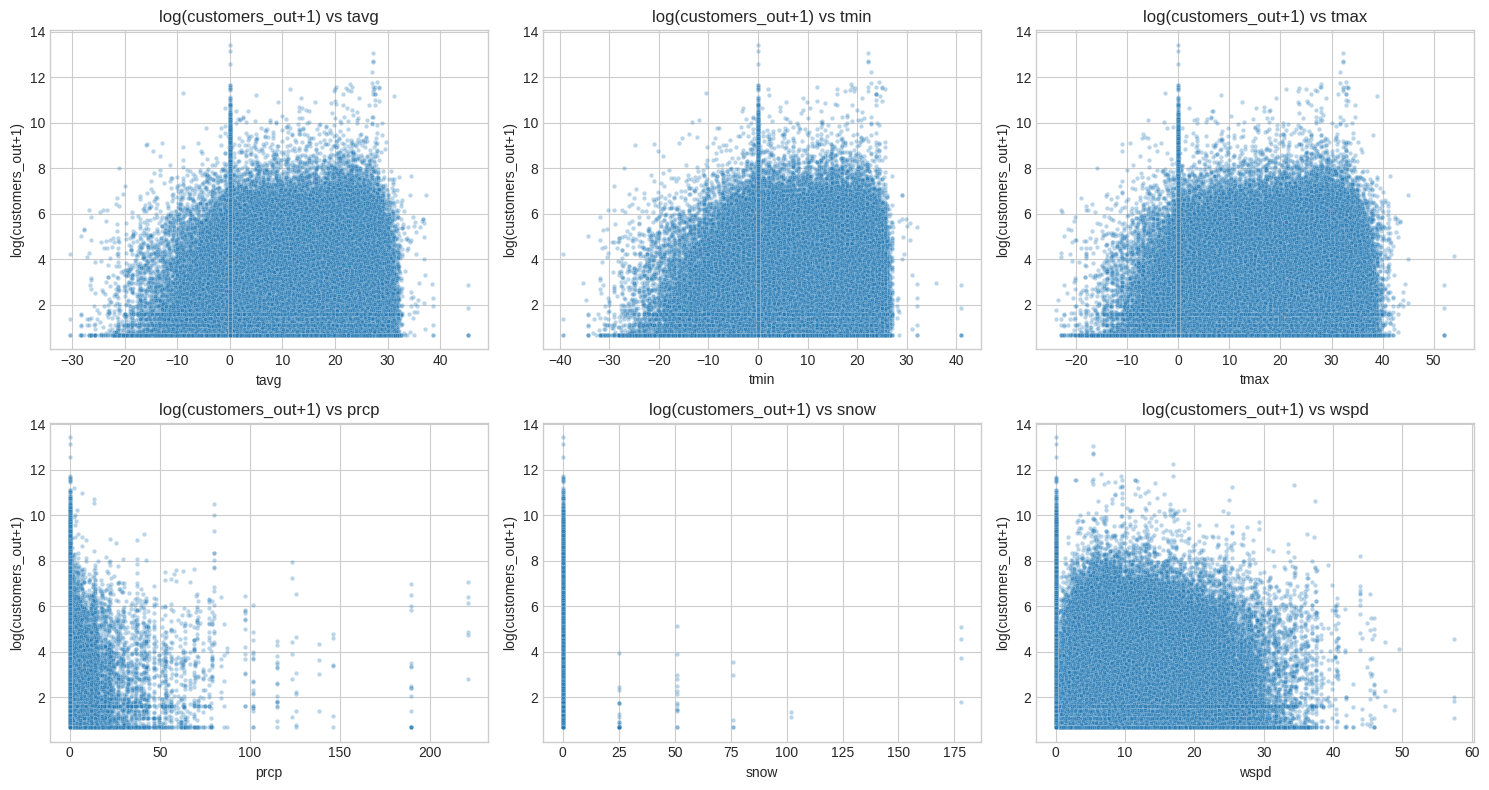


Calculating Correlation Matrix (Spearman for robustness to outliers/non-linearity)...


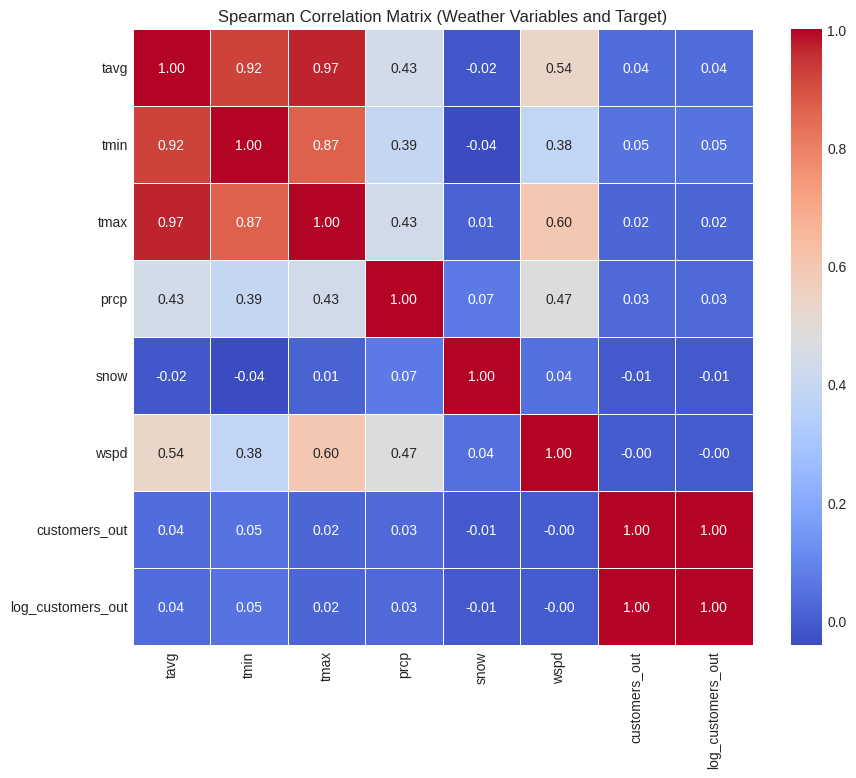


Correlations with target variable:
customers_out        1.000000
log_customers_out    1.000000
tmin                 0.053350
tavg                 0.037246
prcp                 0.029652
tmax                 0.022653
wspd                -0.004856
snow                -0.008253
Name: customers_out, dtype: float64

Correlations with log-transformed target variable:
log_customers_out    1.000000
customers_out        1.000000
tmin                 0.053350
tavg                 0.037246
prcp                 0.029652
tmax                 0.022653
wspd                -0.004856
snow                -0.008253
Name: log_customers_out, dtype: float64


In [16]:
df['log_customers_out'] = np.log1p(df[target_col])

# 1. Target vs. Numerical Weather
print("Bivariate Analysis: Target vs. Numerical Weather")

# Scatter plots
sample_fraction = 0.1
df_sample = df.sample(frac=sample_fraction, random_state=42) if len(df) > 50000 else df

print(f"Plotting scatter plots for Target vs Weather (using {sample_fraction*100:.1f}% sample if large)...")
n_cols_scatter = 3
n_rows_scatter = (len(weather_num_cols) + n_cols_scatter - 1) // n_cols_scatter
fig_scatter, axes_scatter = plt.subplots(n_rows_scatter, n_cols_scatter, figsize=(n_cols_scatter * 5, n_rows_scatter * 4))
axes_scatter = axes_scatter.flatten()

for i, col in enumerate(weather_num_cols):
    if col in df.columns:
        sns.scatterplot(data=df_sample, x=col, y='log_customers_out', ax=axes_scatter[i], alpha=0.3, s=10)
        axes_scatter[i].set_title(f'log({target_col}+1) vs {col}')
        axes_scatter[i].set_xlabel(col)
        axes_scatter[i].set_ylabel(f'log({target_col}+1)')
    else:
        axes_scatter[i].set_title(f'{col} not found')
        axes_scatter[i].axis('off')

# Hide unused subplots
for j in range(i + 1, len(axes_scatter)):
    fig_scatter.delaxes(axes_scatter[j])

plt.tight_layout()
plt.show()

# Correlation Matrix (Numerical Weather + Target)
print("\nCalculating Correlation Matrix (Spearman for robustness to outliers/non-linearity)...")
cols_for_corr = weather_num_cols + [target_col, 'log_customers_out']
valid_cols_for_corr = [col for col in cols_for_corr if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]

if len(valid_cols_for_corr) > 1:
    correlation_matrix = df[valid_cols_for_corr].corr(method='spearman') # Spearman is often better for skewed data or non-linear relationships

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Spearman Correlation Matrix (Weather Variables and Target)')
    plt.show()

    print("\nCorrelations with target variable:")
    print(correlation_matrix[target_col].sort_values(ascending=False))
    print("\nCorrelations with log-transformed target variable:")
    print(correlation_matrix['log_customers_out'].sort_values(ascending=False))
else:
    print("Not enough valid numerical columns found for correlation matrix.")

Bivariate Analysis: Target vs. Event Counts

Calculating Correlations (Spearman) between Target and Event Counts...

Top 10 Event Counts Correlated with customers_out:
event_count_Thunderstorm Wind    0.088552
event_count_Flash Flood          0.049043
event_count_Hail                 0.030059
event_count_Tornado              0.026686
event_count_Heavy Rain           0.021860
event_count_High Wind            0.021050
event_count_Lightning            0.020025
event_count_Strong Wind          0.017449
event_count_Flood                0.015172
event_count_Tropical Storm       0.014769
Name: customers_out, dtype: float64

Top 10 Event Counts Correlated with log(customers_out+1):
event_count_Thunderstorm Wind    0.088552
event_count_Flash Flood          0.049043
event_count_Hail                 0.030059
event_count_Tornado              0.026686
event_count_Heavy Rain           0.021860
event_count_High Wind            0.021050
event_count_Lightning            0.020025
event_count_Strong Wind

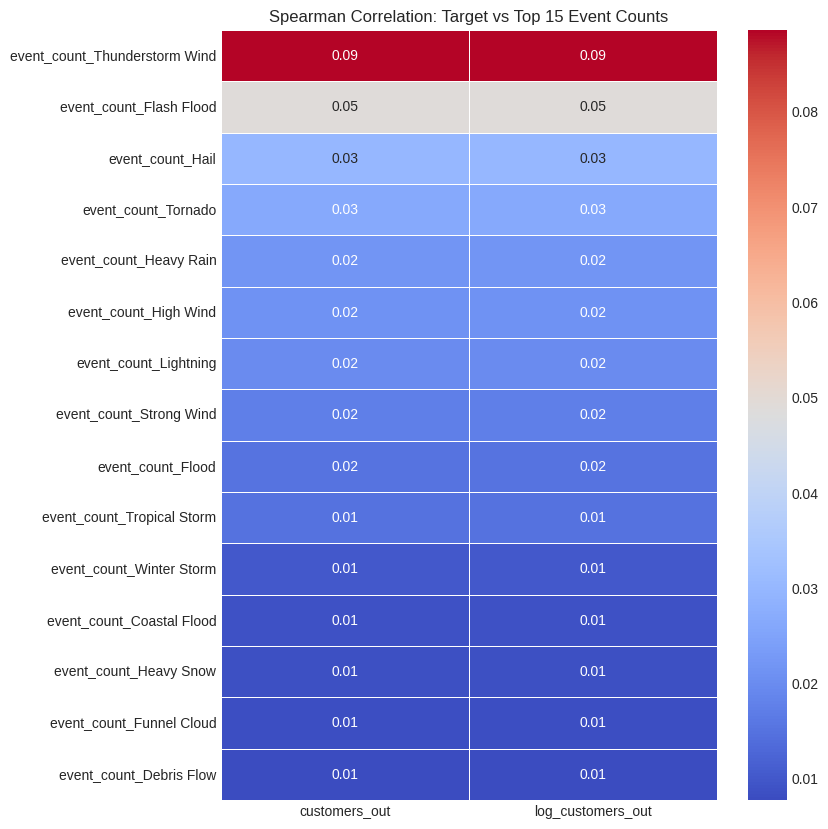


Comparing Outages for Days With vs Without Specific Events: ['event_count_Thunderstorm Wind', 'event_count_Flash Flood', 'event_count_Hail', 'event_count_Tornado', 'event_count_Heavy Rain']


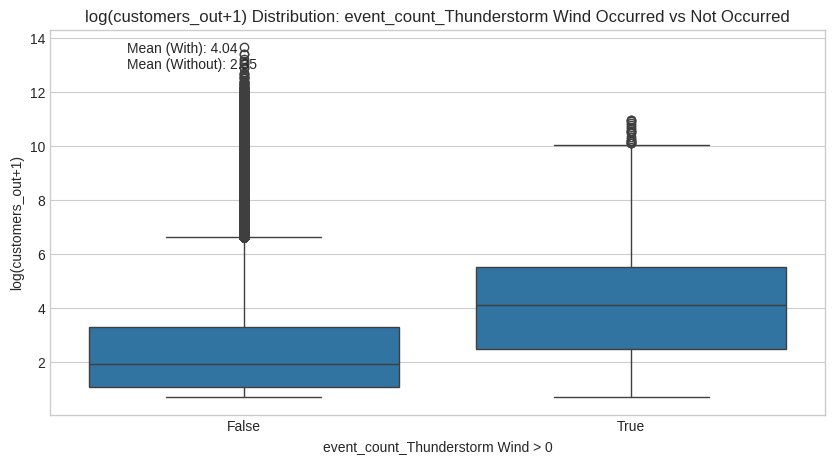

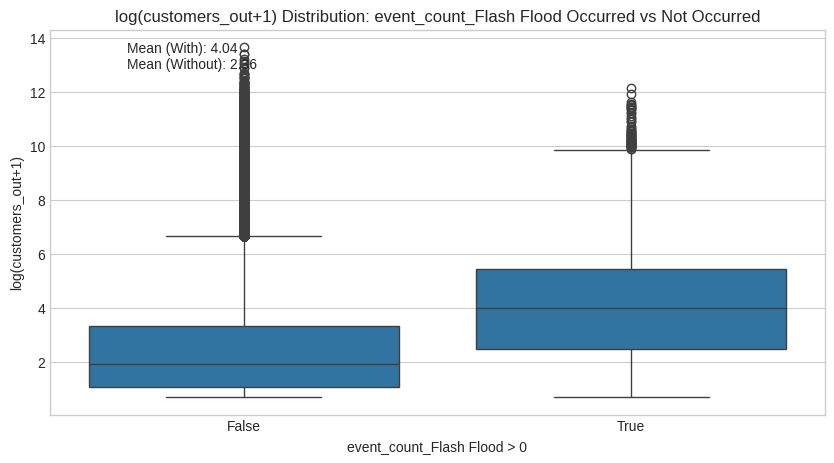

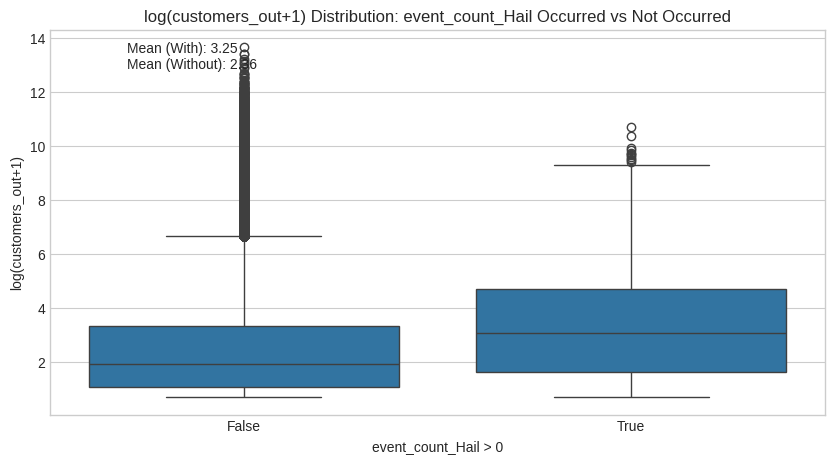

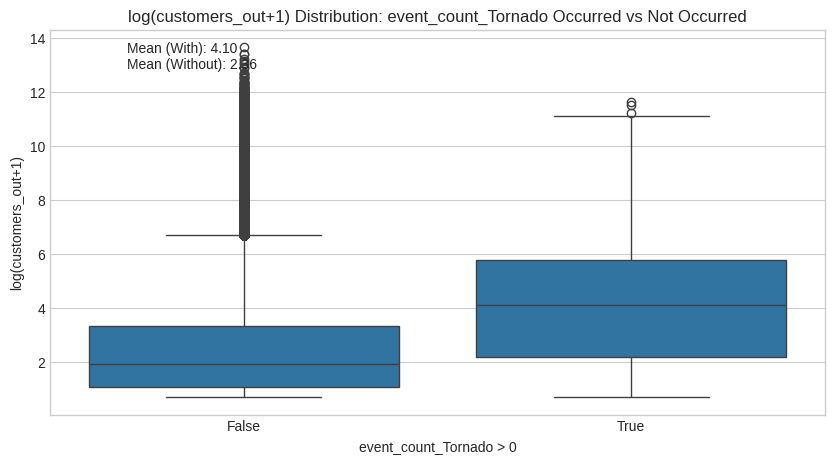

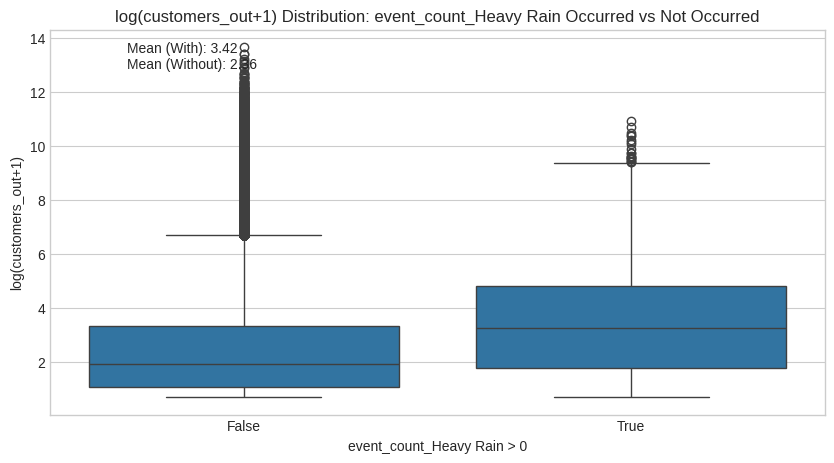

In [17]:
# 2. Target vs. Event Counts
print("Bivariate Analysis: Target vs. Event Counts")

if event_cols:
    # Correlation Analysis (Target vs. Event Counts)
    print("\nCalculating Correlations (Spearman) between Target and Event Counts...")
    event_corr_cols = event_cols + [target_col, 'log_customers_out']
    valid_event_corr_cols = [col for col in event_corr_cols if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]

    if len(valid_event_corr_cols) > 1:
        event_correlation_matrix = df[valid_event_corr_cols].corr(method='spearman')
        target_event_corr = event_correlation_matrix[[target_col, 'log_customers_out']].drop([target_col, 'log_customers_out'])
        print(f"\nTop 10 Event Counts Correlated with {target_col}:")
        print(target_event_corr[target_col].abs().sort_values(ascending=False).head(10))
        print(f"\nTop 10 Event Counts Correlated with log({target_col}+1):")
        print(target_event_corr['log_customers_out'].abs().sort_values(ascending=False).head(10))

        top_n_events = target_event_corr['log_customers_out'].abs().sort_values(ascending=False).head(15).index.tolist()
        if top_n_events:
            plt.figure(figsize=(8, 10))
            sns.heatmap(target_event_corr.loc[top_n_events], annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
            plt.title(f'Spearman Correlation: Target vs Top {len(top_n_events)} Event Counts')
            plt.show()

    else:
        print("Not enough valid event count columns found for correlation analysis.")


    events_to_analyze = target_event_corr['log_customers_out'].abs().sort_values(ascending=False).head(5).index.tolist()
    print(f"\nComparing Outages for Days With vs Without Specific Events: {events_to_analyze}")

    for event in events_to_analyze:
        if event in df.columns:
            plt.figure(figsize=(10, 5))
            # Using log scale for y-axis due to skewness
            sns.boxplot(x=(df[event] > 0), y=df['log_customers_out'])
            plt.title(f'log({target_col}+1) Distribution: {event} Occurred vs Not Occurred')
            plt.xlabel(f'{event} > 0')
            plt.ylabel(f'log({target_col}+1)')
            # Add mean comparison text
            mean_with = df.loc[df[event] > 0, 'log_customers_out'].mean()
            mean_without = df.loc[df[event] == 0, 'log_customers_out'].mean()
            plt.text(0.1, 0.9, f"Mean (With): {mean_with:.2f}\nMean (Without): {mean_without:.2f}", transform=plt.gca().transAxes)
            plt.show()
        else:
            print(f"Column {event} not found for grouped analysis.")

else:
    print("No event count columns found for bivariate analysis.")

Bivariate Analysis: Target vs. Temporal Features


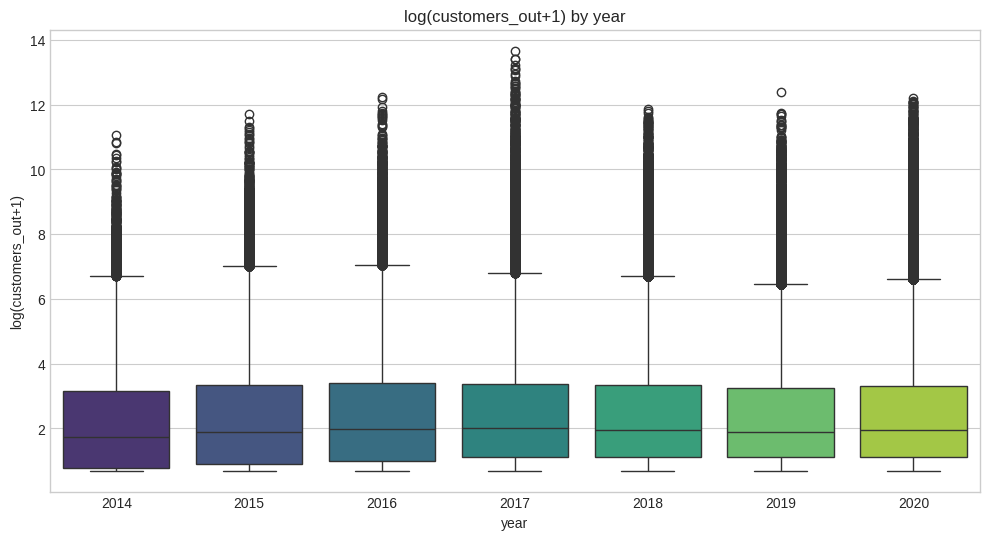

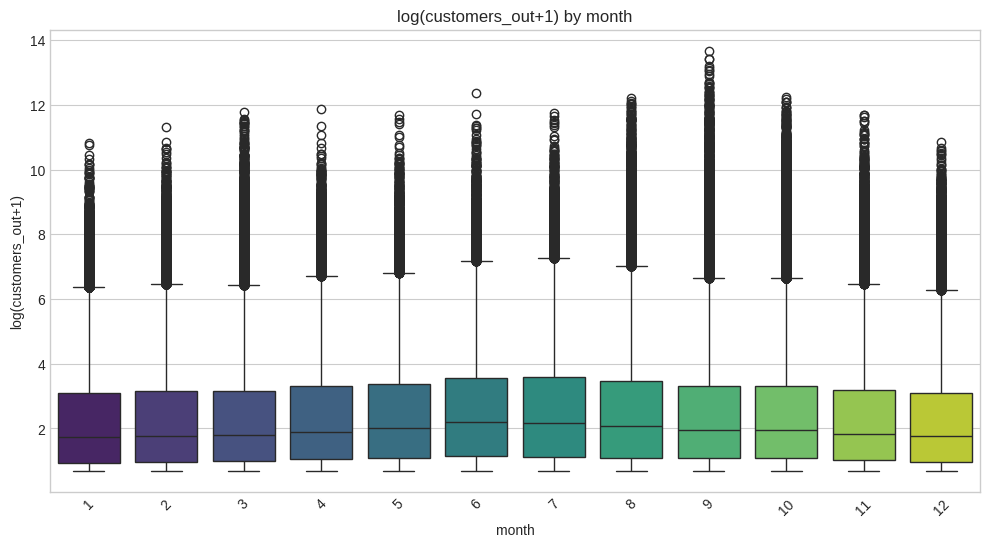

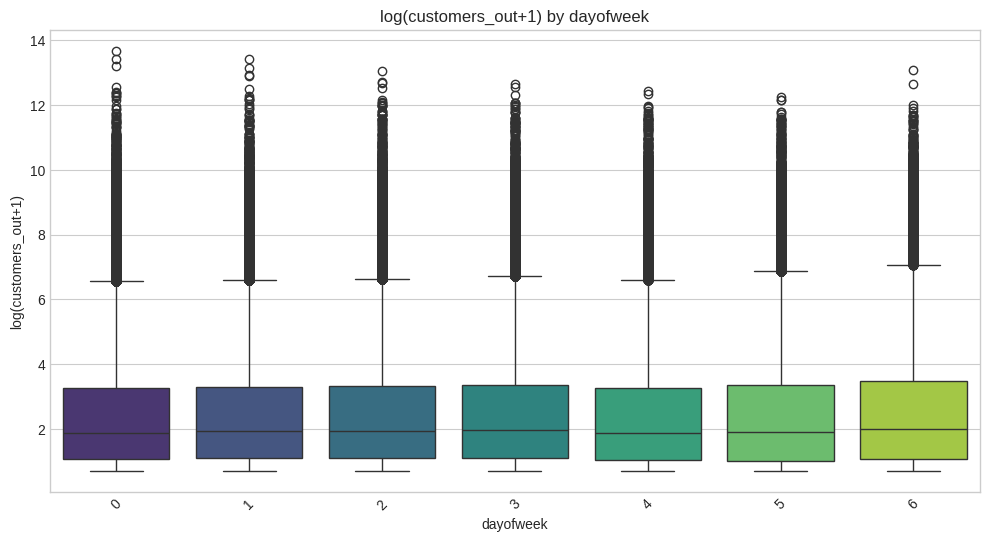

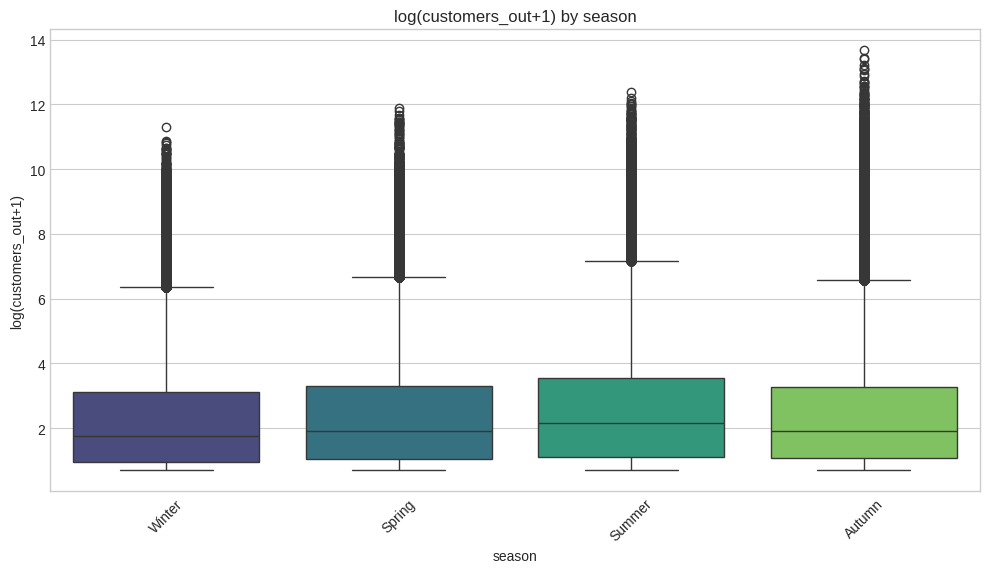

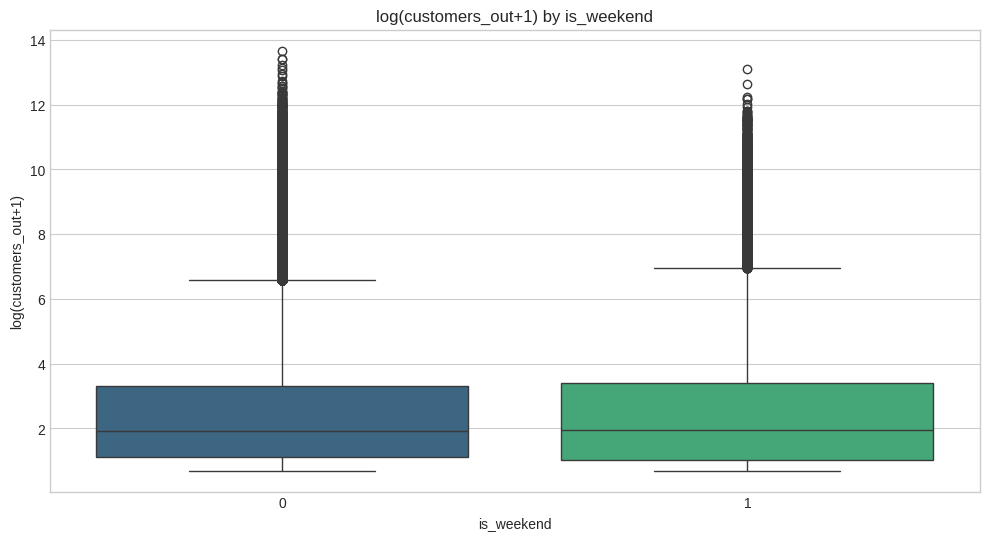


Plotting average outages over time...


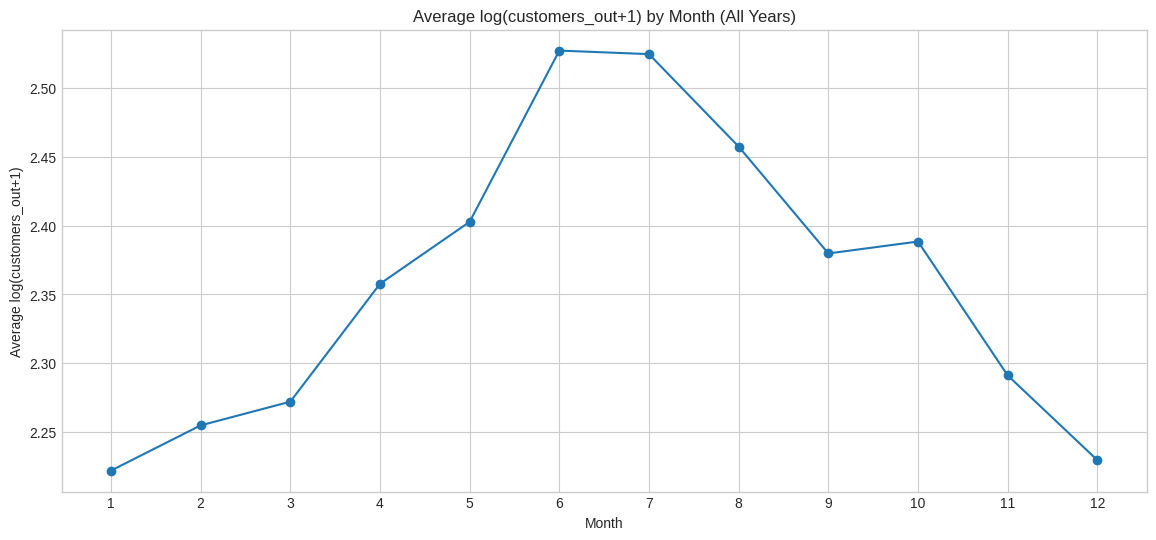

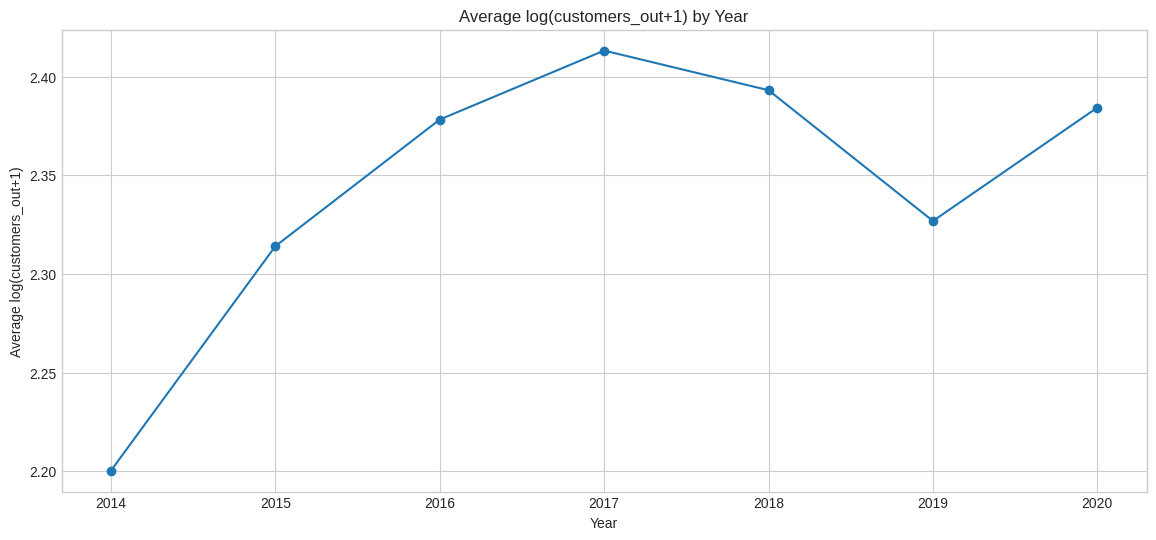

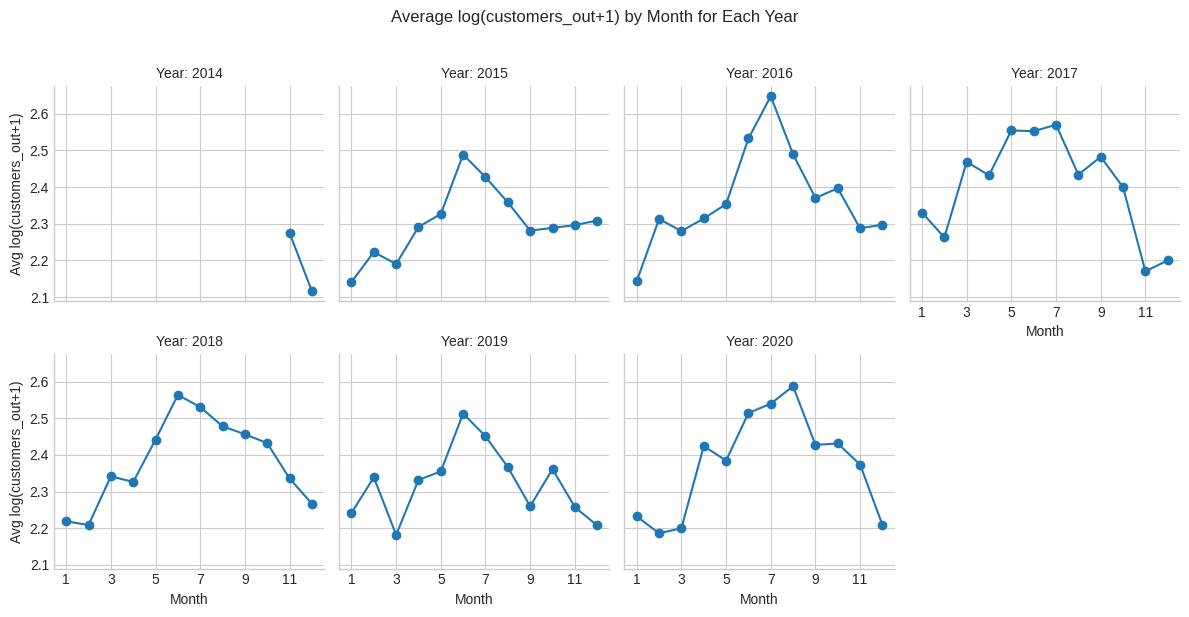

In [18]:
# 3. Target vs. Temporal Features
print("Bivariate Analysis: Target vs. Temporal Features")

# Box plots/Violin plots: log(customers_out) grouped by temporal features
for col in temporal_features:
    if col in df.columns:
        plt.figure(figsize=(12, 6))
        order = None
        if col == 'month': order = sorted(df[col].unique())
        if col == 'dayofweek': order = sorted(df[col].unique()) # 0=Mon, 6=Sun
        if col == 'season': order = ['Winter', 'Spring', 'Summer', 'Autumn']

        # Using boxplot, violinplot is also an option
        sns.boxplot(data=df, x=col, y='log_customers_out', order=order, palette='viridis')
        plt.title(f'log({target_col}+1) by {col}')
        plt.xlabel(col)
        plt.ylabel(f'log({target_col}+1)')
        if col in ['month', 'dayofweek', 'season']:
             plt.xticks(rotation=45)
        plt.show()
    else:
        print(f"Column {col} not found for temporal analysis.")

# Line plots: Average log(customers_out) per month/season over the years
print("\nPlotting average outages over time...")
plt.figure(figsize=(14, 6))
df.groupby('month')['log_customers_out'].mean().plot(marker='o')
plt.title(f'Average log({target_col}+1) by Month (All Years)')
plt.xlabel('Month')
plt.ylabel(f'Average log({target_col}+1)')
plt.xticks(ticks=range(1, 13))
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 6))
df.groupby('year')['log_customers_out'].mean().plot(marker='o')
plt.title(f'Average log({target_col}+1) by Year')
plt.xlabel('Year')
plt.ylabel(f'Average log({target_col}+1)')
plt.grid(True)
plt.show()

# Monthly pattern faceted by year
if 'year' in df.columns and 'month' in df.columns:
    monthly_avg = df.groupby(['year', 'month'])['log_customers_out'].mean().reset_index()
    g = sns.FacetGrid(monthly_avg, col='year', col_wrap=4, height=3)
    g.map(plt.plot, 'month', 'log_customers_out', marker='o')
    g.set_titles("Year: {col_name}")
    g.set_axis_labels("Month", f"Avg log({target_col}+1)")
    plt.xticks(ticks=range(1, 13, 2)) # Adjust x-ticks for clarity
    plt.suptitle(f'Average log({target_col}+1) by Month for Each Year', y=1.02)
    plt.tight_layout()
    plt.show()

Bivariate Analysis: Target vs. Geospatial Features

Top 10 States by Total Customers Out:
             state  total_outages  mean_outages  median_outages  \
9          Florida     35305444.0    259.566406       14.111111   
4       California     20421988.0    317.540588       46.454544   
33  North Carolina     14826954.0     85.070107        5.200000   
43           Texas     14820110.0     51.246613        4.700000   
32        New York     14474950.0    129.600494       14.125000   
18       Louisiana     13988990.0    118.419296        9.864865   
22        Michigan     13100413.0    103.027924        5.909091   
47        Virginia     12061327.0     63.750771        6.525000   
10         Georgia     11742772.0     50.266563        4.000000   
38    Pennsylvania     11024642.0     85.345901       11.941519   

      max_outages  days_with_outages  record_count  outage_frequency  \
9   865675.500000             136017        136017               1.0   
4   122384.257812           

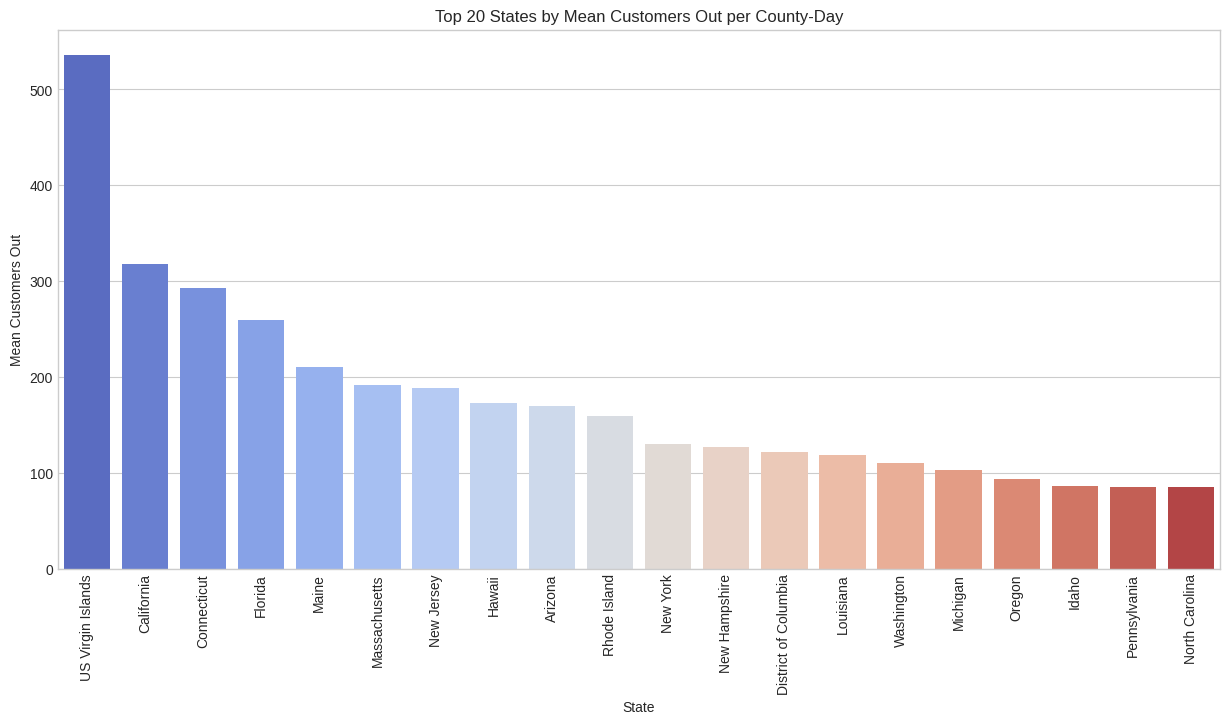


Top 20 Counties by Total Customers Out:
            state          county  total_outages  mean_outages  \
332       Florida      Miami-Dade    4148915.000   1859.666016   
181    California     Los Angeles    3870254.000   1733.208252   
295       Florida         Broward    2853960.000   1279.229004   
1080    Louisiana       Calcasieu    2383698.500   1063.201782   
1269     Michigan           Wayne    2202091.500   1194.840698   
339       Florida      Palm Beach    2142684.250    960.844971   
341       Florida        Pinellas    2098745.250    938.615967   
2110     Oklahoma        Oklahoma    2088335.875   1066.565796   
304       Florida           Duval    1446699.375    647.582520   
353       Florida         Volusia    1433824.375    640.386047   
337       Florida          Orange    1414239.750    629.110229   
300       Florida         Collier    1301606.750    583.942017   
324       Florida             Lee    1290389.000    578.390381   
294       Florida         Brevard  

In [19]:
# 4. Target vs. Geospatial Features
print("Bivariate Analysis: Target vs. Geospatial Features")

# Aggregate customers_out by state
if 'state' in df.columns:
    state_agg = df.groupby('state').agg(
        total_outages=(target_col, 'sum'),
        mean_outages=(target_col, 'mean'),
        median_outages=(target_col, 'median'),
        max_outages=(target_col, 'max'),
        days_with_outages=(target_col, lambda x: (x > 0).sum()),
        record_count=(target_col, 'count')
    ).reset_index()
    state_agg['outage_frequency'] = state_agg['days_with_outages'] / state_agg['record_count']
    state_agg['mean_outages_when_occur'] = state_agg['total_outages'] / state_agg['days_with_outages'].replace(0, np.nan)


    print("\nTop 10 States by Total Customers Out:")
    print(state_agg.sort_values('total_outages', ascending=False).head(10))

    print("\nTop 10 States by Mean Customers Out per County-Day:")
    print(state_agg.sort_values('mean_outages', ascending=False).head(10))

    print("\nTop 10 States by Outage Frequency (Days with Outages / Total Days):")
    print(state_agg.sort_values('outage_frequency', ascending=False).head(10))

    # Plotting top N states by mean outages
    top_n_states_plot = 20
    state_agg_sorted = state_agg.sort_values('mean_outages', ascending=False).head(top_n_states_plot)
    plt.figure(figsize=(15, 7))
    sns.barplot(data=state_agg_sorted, x='state', y='mean_outages', palette='coolwarm')
    plt.title(f'Top {top_n_states_plot} States by Mean Customers Out per County-Day')
    plt.xlabel('State')
    plt.ylabel('Mean Customers Out')
    plt.xticks(rotation=90)
    plt.show()

else:
    print("'state' column not found.")

# Aggregate by County (Show top N - mapping would be better)
if 'county' in df.columns and 'state' in df.columns:
    county_agg = df.groupby(['state', 'county']).agg(
        total_outages=(target_col, 'sum'),
        mean_outages=(target_col, 'mean'),
        median_outages=(target_col, 'median'),
        max_outages=(target_col, 'max'),
         days_with_outages=(target_col, lambda x: (x > 0).sum()),
         record_count=(target_col, 'count')
    ).reset_index()
    county_agg['outage_frequency'] = county_agg['days_with_outages'] / county_agg['record_count']
    county_agg['mean_outages_when_occur'] = county_agg['total_outages'] / county_agg['days_with_outages'].replace(0, np.nan)


    print("\nTop 20 Counties by Total Customers Out:")
    print(county_agg.sort_values('total_outages', ascending=False).head(20))

    print("\nTop 20 Counties by Mean Customers Out per County-Day:")
    print(county_agg.sort_values('mean_outages', ascending=False).head(20))
    # TO DO USE GEOPANDAS!
else:
    print("'county' or 'state' column not found for county-level aggregation.")

Bivariate Analysis: Weather vs. Weather


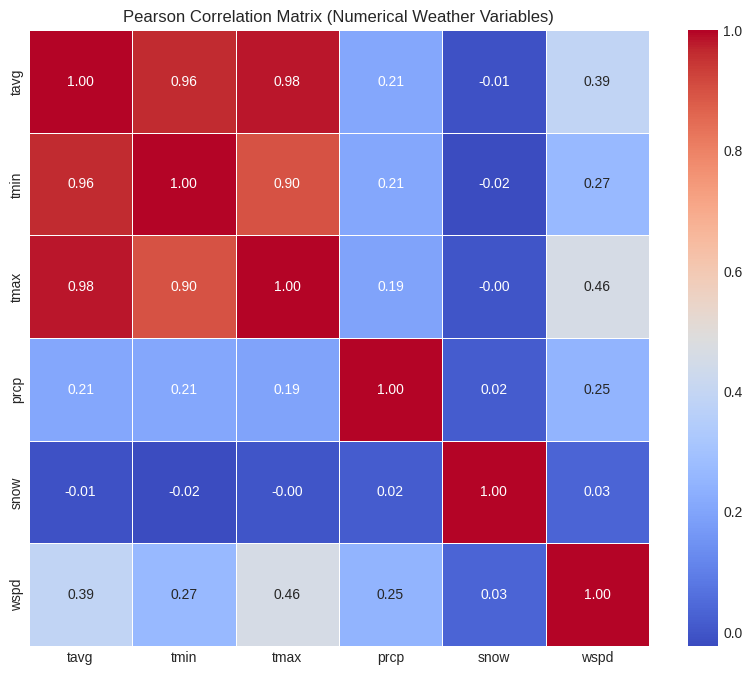

Note: High correlations observed (e.g., between tavg, tmin, tmax) indicate multicollinearity, which should be considered during modeling.


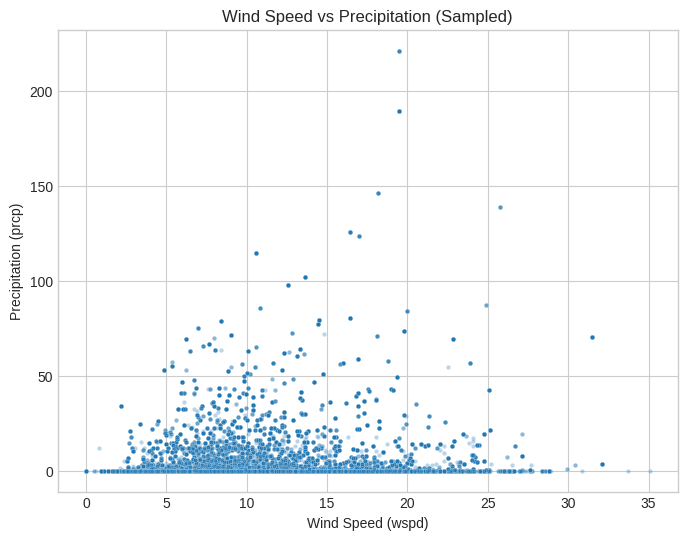

In [20]:
# 5. Weather vs. Weather (Multicollinearity Check)
print("Bivariate Analysis: Weather vs. Weather")

# Correlation matrix for numerical weather variables
if len(weather_num_cols) > 1:
    weather_corr_matrix = df[weather_num_cols].corr(method='pearson') # Pearson is common for weather inter-correlation

    plt.figure(figsize=(10, 8))
    sns.heatmap(weather_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Pearson Correlation Matrix (Numerical Weather Variables)')
    plt.show()

    print("Note: High correlations observed (e.g., between tavg, tmin, tmax) indicate multicollinearity, which should be considered during modeling.")
else:
    print("Not enough numerical weather columns for correlation matrix.")

# Scatter plots for selected pairs (wind vs precipitation)
if 'wspd' in df.columns and 'prcp' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_sample, x='wspd', y='prcp', alpha=0.3, s=10)
    plt.title('Wind Speed vs Precipitation (Sampled)')
    plt.xlabel('Wind Speed (wspd)')
    plt.ylabel('Precipitation (prcp)')
    plt.show()

---
## D. Time Series Analysis
---

D. Time Series Analysis

Aggregating outages across all counties...


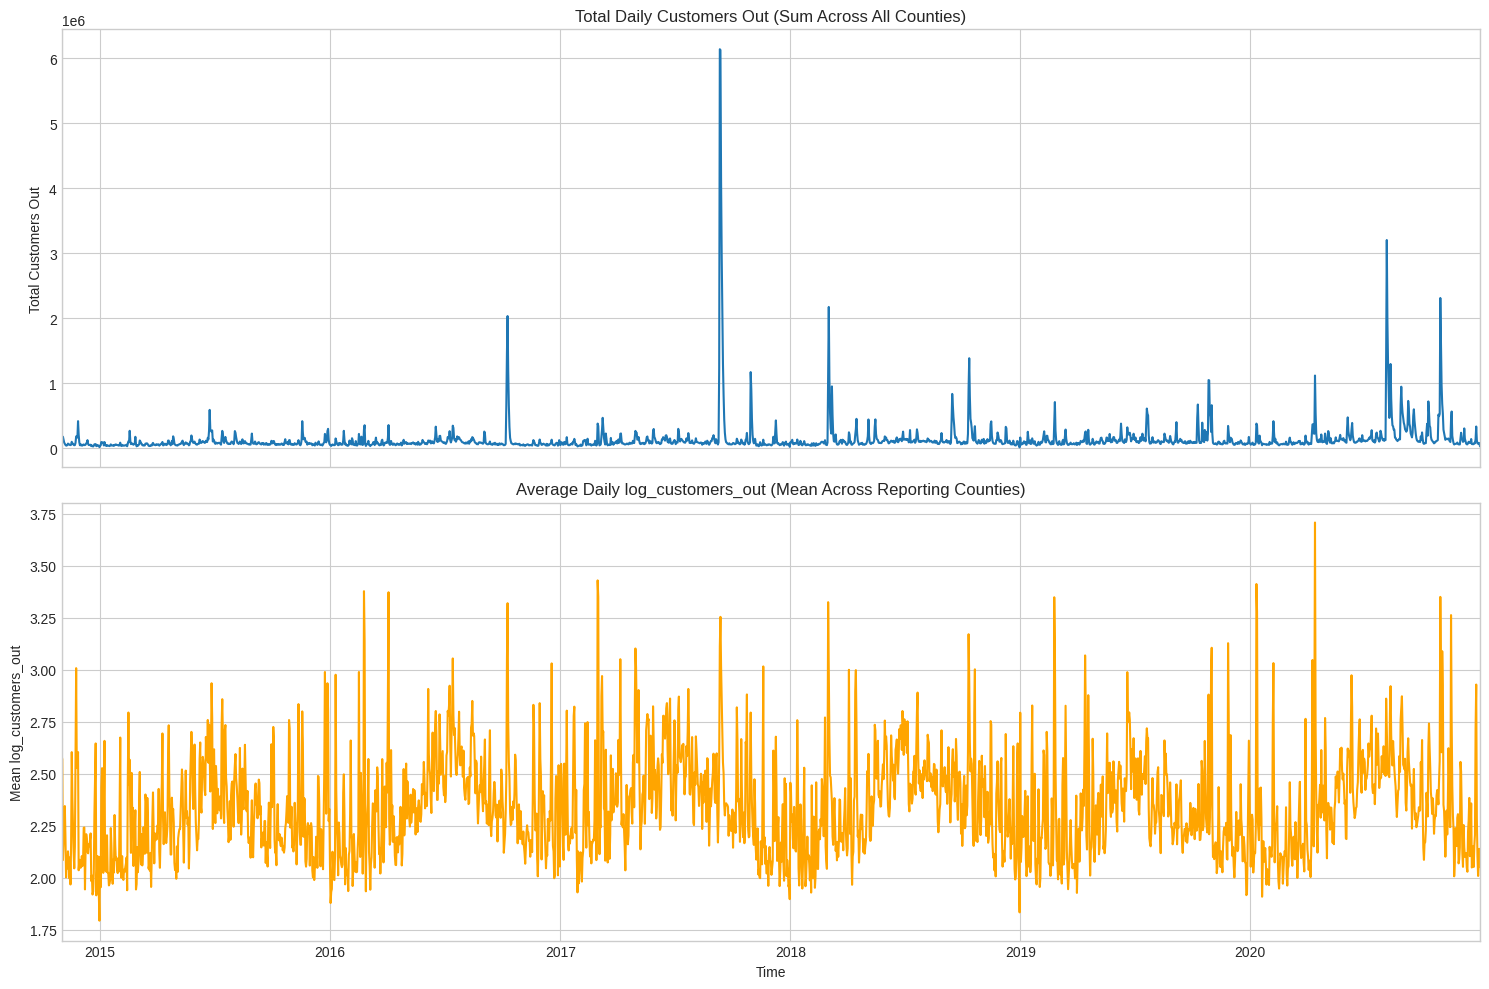


Decomposing aggregated daily mean log outage time series...


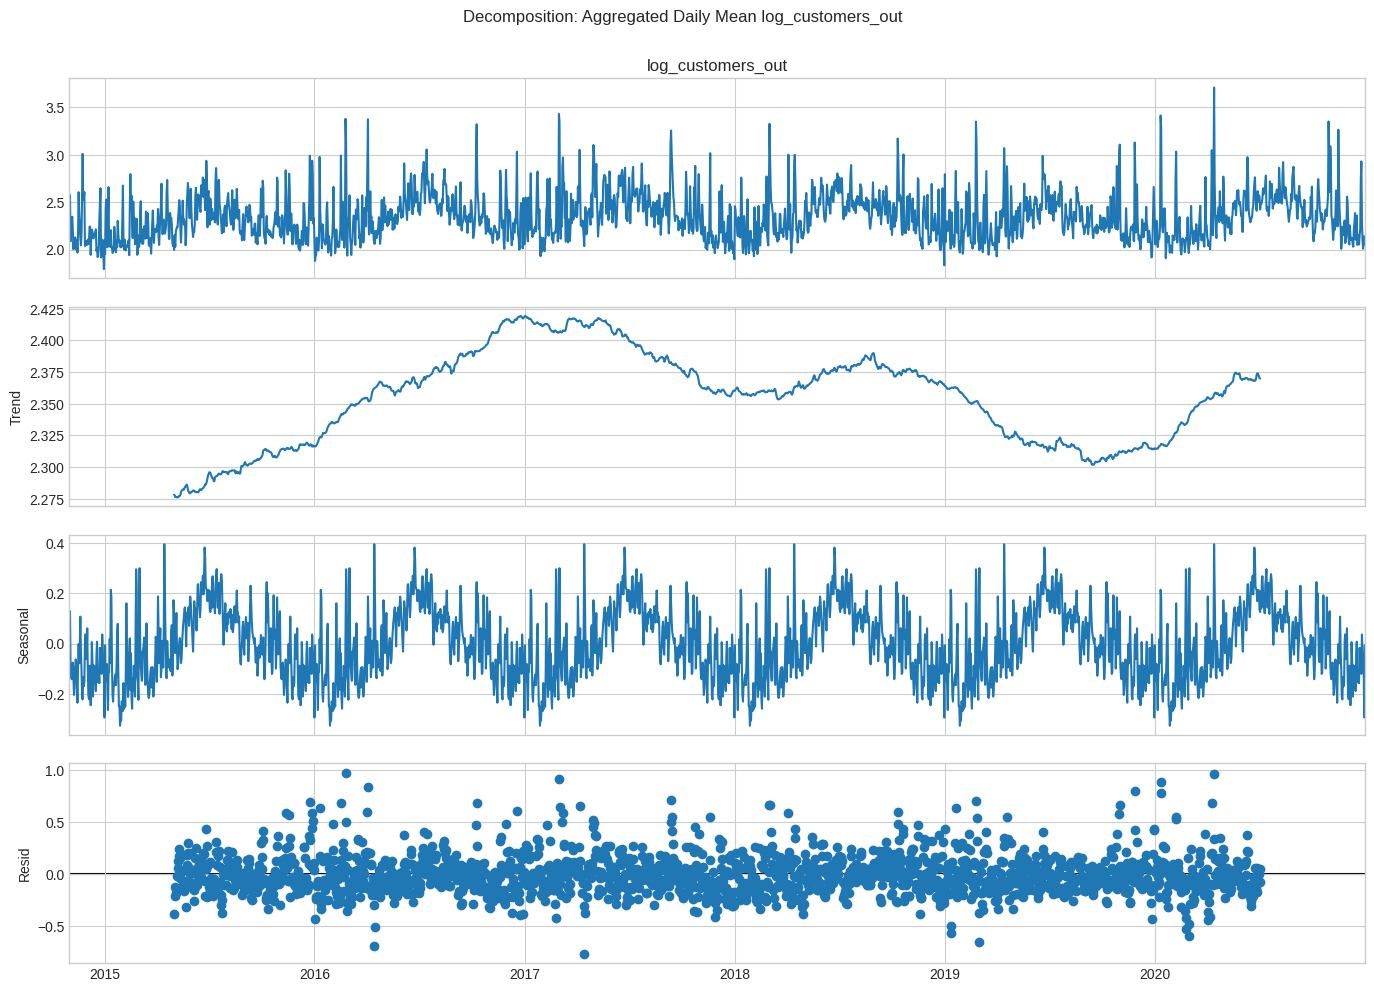


Aggregating and plotting weather time series...
Daily aggregated weather data calculated.


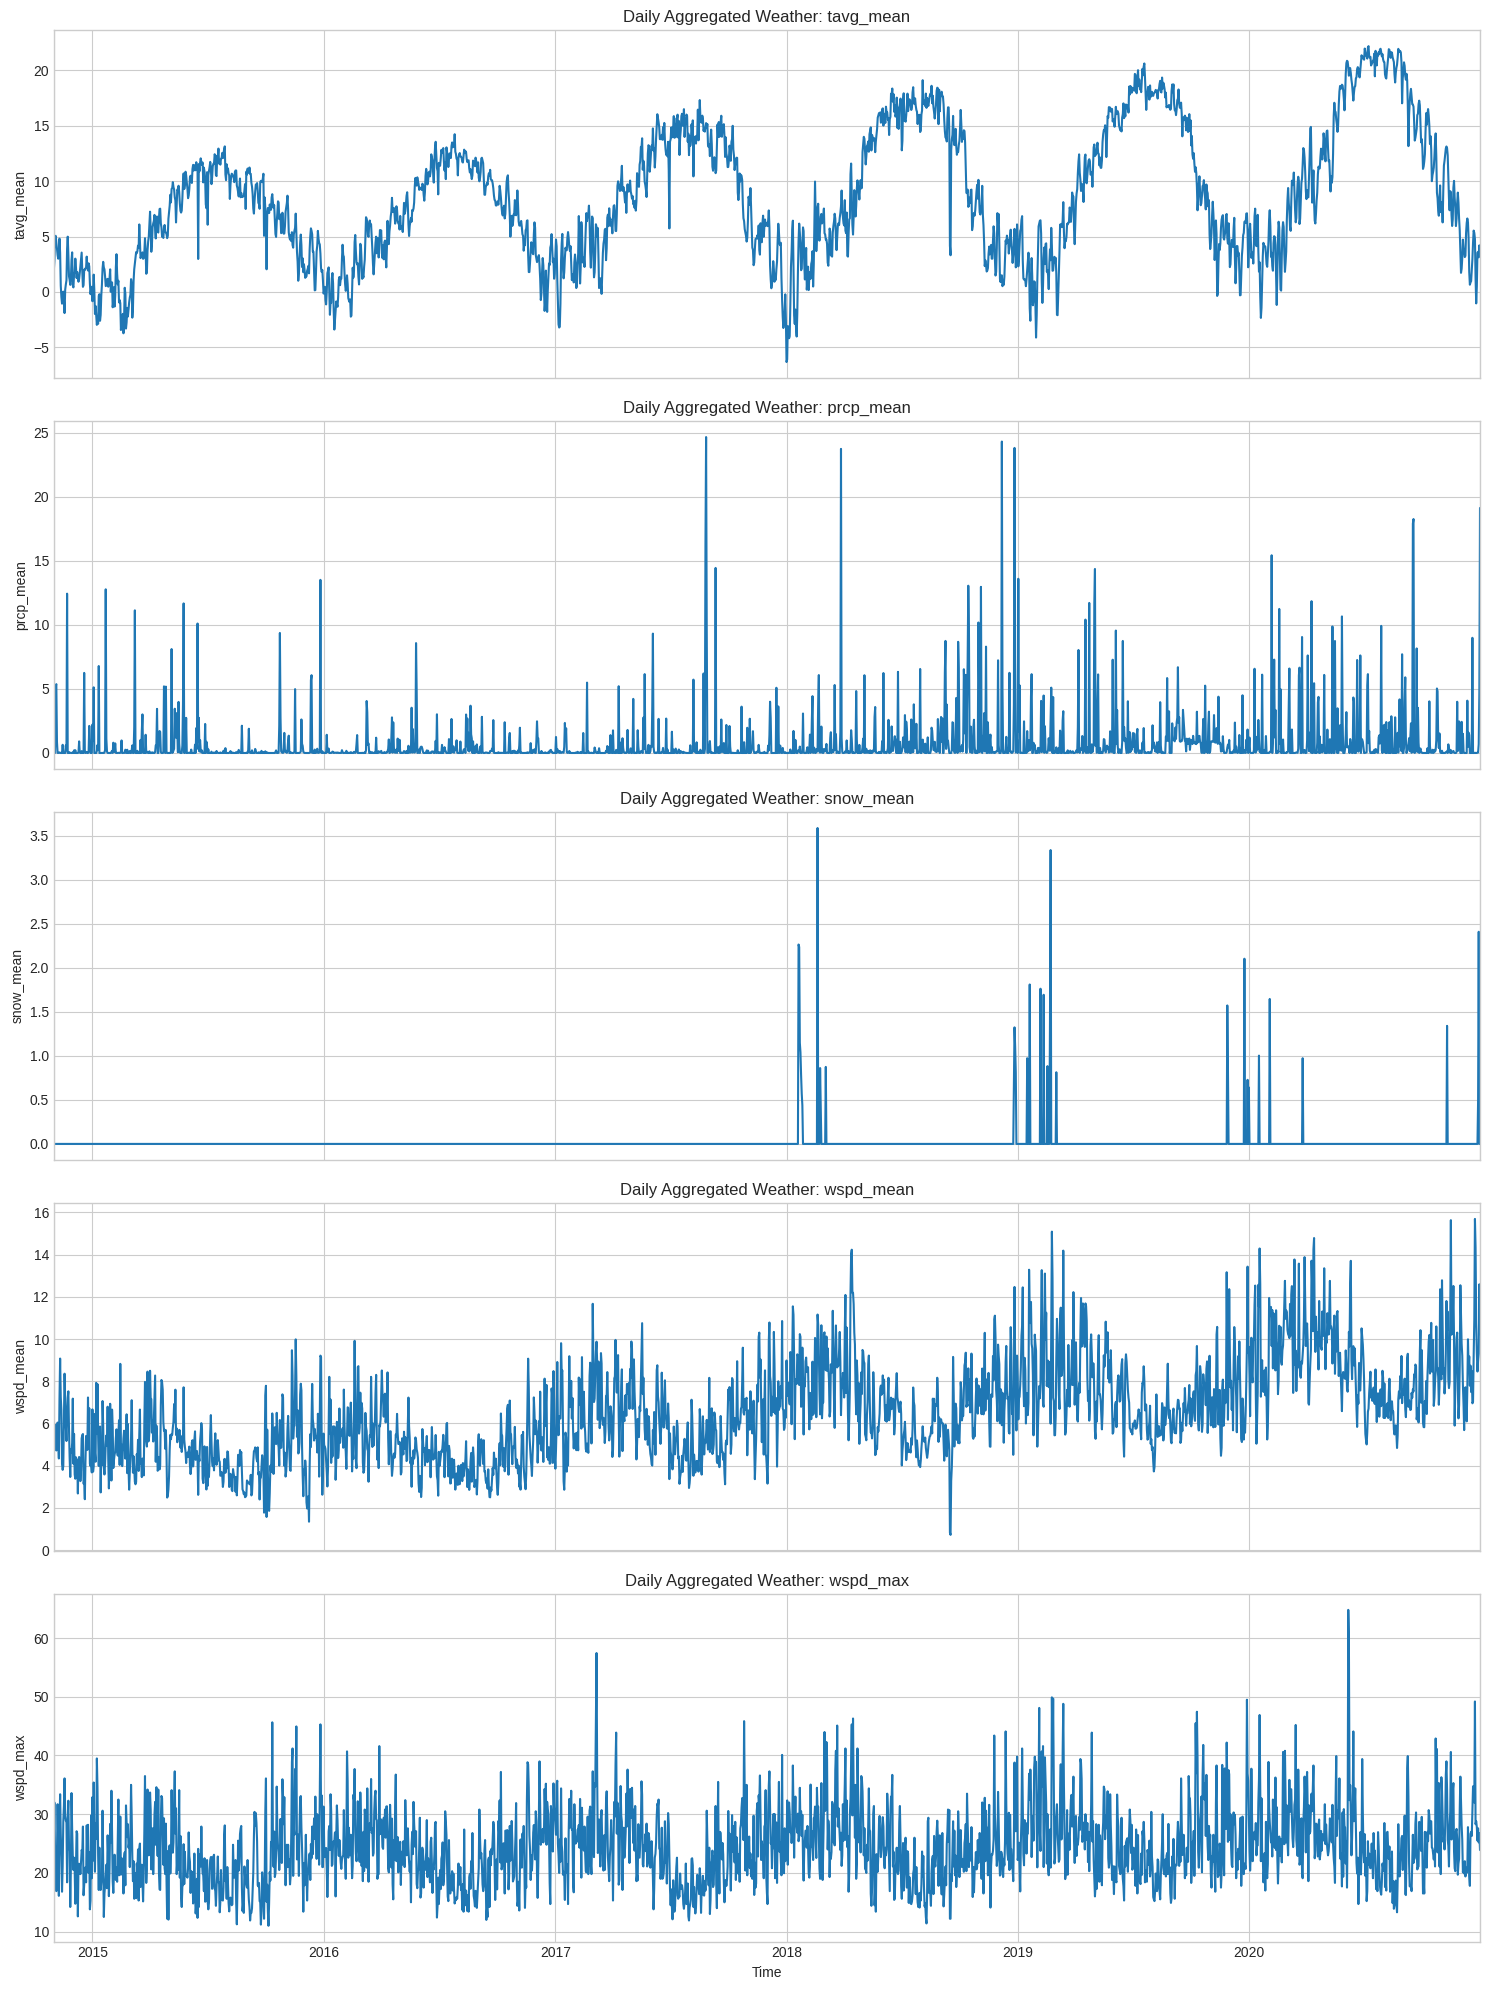


Decomposing aggregated daily temperature (tavg_mean)...


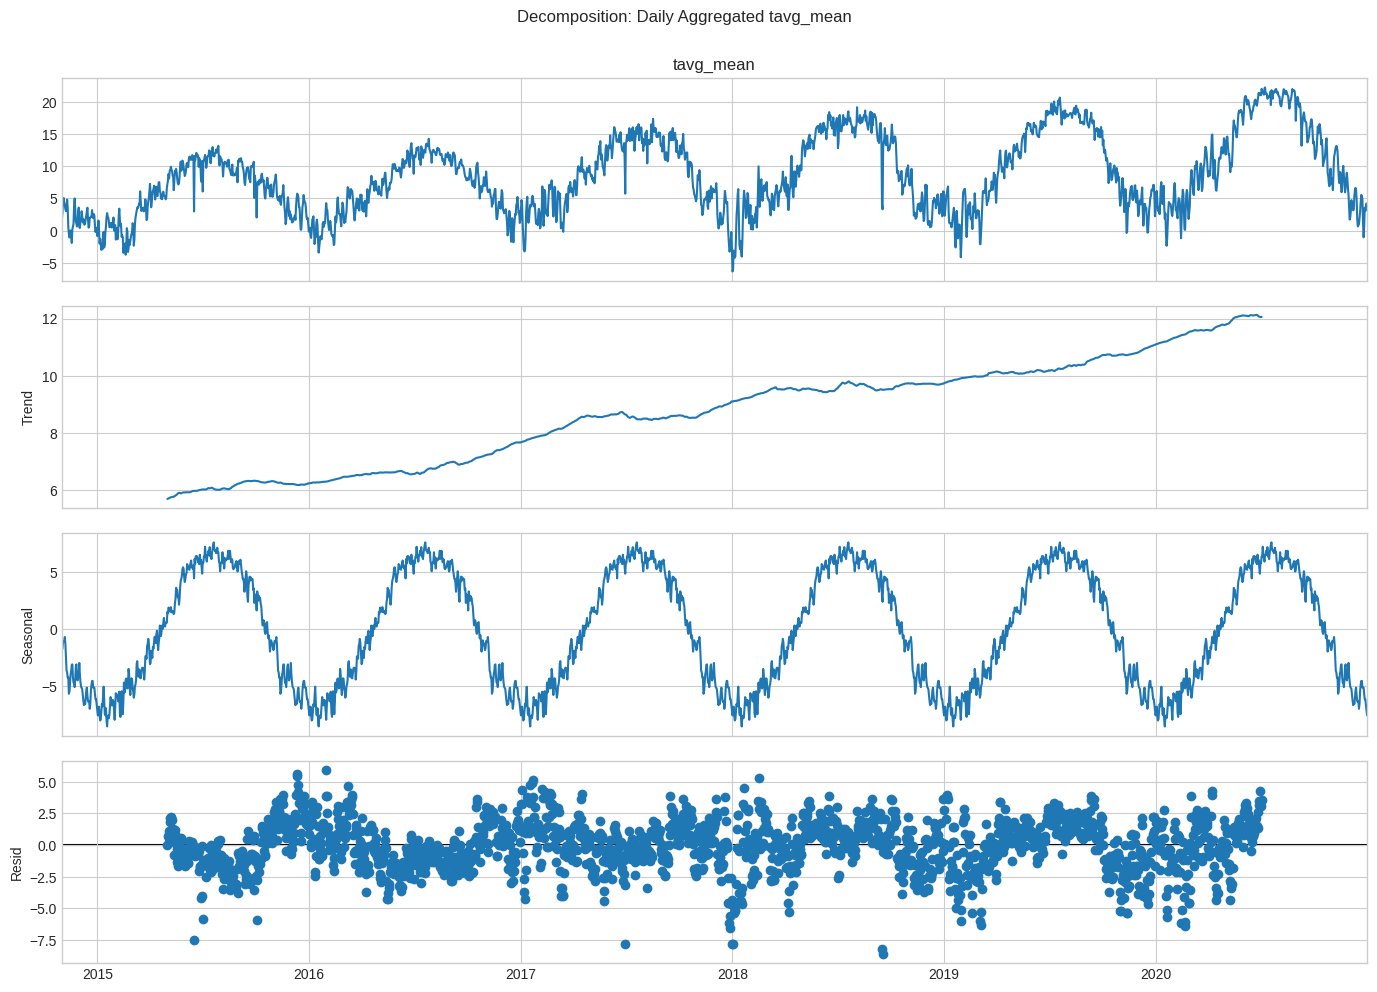

In [21]:
print("D. Time Series Analysis")

df_ts = df.set_index('time')
if not isinstance(df_ts.index, pd.DatetimeIndex):
    print("Skipping Time Series plots: DataFrame does not have a DatetimeIndex.")
else:
    # 1. Aggregate Outages
    print("\nAggregating outages across all counties...")
    daily_total_outages = df_ts.groupby(df_ts.index)[target_col].sum()
    daily_mean_log_outages = df_ts.groupby(df_ts.index)[log_target_col].mean() # Using mean log

    # Plot Aggregated Outages
    fig, ax = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    daily_total_outages.plot(ax=ax[0], label='Total Outages')
    ax[0].set_title('Total Daily Customers Out (Sum Across All Counties)')
    ax[0].set_ylabel('Total Customers Out')
    ax[0].grid(True)

    daily_mean_log_outages.plot(ax=ax[1], label='Mean Log Outages', color='orange')
    ax[1].set_title(f'Average Daily {log_target_col} (Mean Across Reporting Counties)')
    ax[1].set_ylabel(f'Mean {log_target_col}')
    ax[1].grid(True)
    plt.xlabel('Time')
    plt.tight_layout()
    plt.show()

    daily_mean_log_outages_filled = daily_mean_log_outages.fillna(0) # Simple fill for demo
    if len(daily_mean_log_outages_filled) > 365 * 2:
        print("\nDecomposing aggregated daily mean log outage time series...")
        try:
            decomposition_outages = seasonal_decompose(daily_mean_log_outages_filled, model='additive', period=365)
            fig_decomp_outages = decomposition_outages.plot()
            fig_decomp_outages.set_size_inches(14, 10)
            plt.suptitle(f'Decomposition: Aggregated Daily Mean {log_target_col}', y=1.01)
            plt.show()
        except Exception as e:
            print(f"Could not decompose outage series: {e}")
    else:
         print("\nSkipping outage time series decomposition: Not enough data (< 2 years).")


    # --- NEW: Aggregate and Plot Weather Time Series ---
    print("\nAggregating and plotting weather time series...")
    weather_agg_ops = {
        'tavg': 'mean',
        'prcp': 'mean', # Mean precip per county reporting
        'snow': 'mean', # Mean snow per county reporting
        'wspd': ['mean', 'max'] # Avg and Max wind speed across counties
    }
    # Filter ops for columns actually present in the DataFrame
    valid_weather_agg_ops = {k: v for k, v in weather_agg_ops.items() if k in df.columns}

    if valid_weather_agg_ops:
        daily_agg_weather = df_ts.groupby(df_ts.index)[weather_num_cols].agg(valid_weather_agg_ops)
        # Flatten MultiIndex columns (e.g., ('wspd', 'mean') -> 'wspd_mean')
        daily_agg_weather.columns = ['_'.join(col).strip('_') for col in daily_agg_weather.columns.values]
        print("Daily aggregated weather data calculated.")

        # Plot Aggregated Weather
        weather_cols_to_plot = daily_agg_weather.columns.tolist()
        n_plots = len(weather_cols_to_plot)
        n_cols = 1 # Plot each on its own row for clarity
        fig_w, axes_w = plt.subplots(n_plots, n_cols, figsize=(15, n_plots * 4), sharex=True)
        if n_plots == 1: # Ensure axes_w is always iterable
             axes_w = [axes_w]

        for i, col in enumerate(weather_cols_to_plot):
            daily_agg_weather[col].plot(ax=axes_w[i])
            axes_w[i].set_title(f'Daily Aggregated Weather: {col}')
            axes_w[i].set_ylabel(col)
            axes_w[i].grid(True)

        plt.xlabel('Time')
        plt.tight_layout()
        plt.show()

        temp_col = 'tavg_mean'
        if temp_col in daily_agg_weather.columns:
            temp_series_filled = daily_agg_weather[temp_col].fillna(method='ffill').fillna(0) # Ffill then 0
            if len(temp_series_filled) > 365 * 2:
                print(f"\nDecomposing aggregated daily temperature ({temp_col})...")
                try:
                    decomposition_temp = seasonal_decompose(temp_series_filled, model='additive', period=365)
                    fig_decomp_temp = decomposition_temp.plot()
                    fig_decomp_temp.set_size_inches(14, 10)
                    plt.suptitle(f'Decomposition: Daily Aggregated {temp_col}', y=1.01)
                    plt.show()
                except Exception as e:
                    print(f"Could not decompose temperature series: {e}")
            else:
                print("\nSkipping temperature decomposition: Not enough data (< 2 years).")

    else:
        print("No valid weather columns found for aggregation and plotting.")
    gc.collect()

In [22]:
# 2. Autocorrelation (ACF and PACF)
# Use the aggregated series
print("\nPlotting ACF and PACF for Aggregated Daily Mean Outages...")
# Limit lags shown for clarity
lags = min(60, len(daily_mean_outages_filled)//2 - 1) # Ensure lags < N/2

if lags > 0:
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    plot_acf(daily_mean_outages_filled, lags=lags, ax=ax[0])
    ax[0].set_title('Autocorrelation Function (ACF)')
    plot_pacf(daily_mean_outages_filled, lags=lags, ax=ax[1])
    ax[1].set_title('Partial Autocorrelation Function (PACF)')
    plt.tight_layout()
    plt.show()
    print("ACF/PACF plots help identify autocorrelation and seasonality patterns.")
else:
    print("Skipping ACF/PACF plot: Not enough data points.")


Plotting ACF and PACF for Aggregated Daily Mean Outages...


NameError: name 'daily_mean_outages_filled' is not defined

Lag Analysis (Simplified Cross-Correlation)
Calculating correlation between lagged weather and current outages...

Spearman Correlation of log(Outages+1) with Lagged Predictors:
   event_count_Tornado  event_count_High Wind  event_count_Flood      wspd  \
0             0.026686               0.021050           0.015172 -0.004856   
1             0.028335               0.015323           0.007780 -0.019269   
2             0.008668               0.005261           0.000339 -0.032073   
3             0.004242               0.002475          -0.001741 -0.033221   
4             0.002950               0.001391          -0.001798 -0.032100   
5             0.002257               0.001202          -0.002413 -0.032512   
6             0.001440               0.001168          -0.002385 -0.033284   
7             0.002813               0.000425          -0.002780 -0.033111   

       snow  event_count_Lightning      prcp      tmax  \
0 -0.008253               0.020025  0.029652  0.022653   
1 -

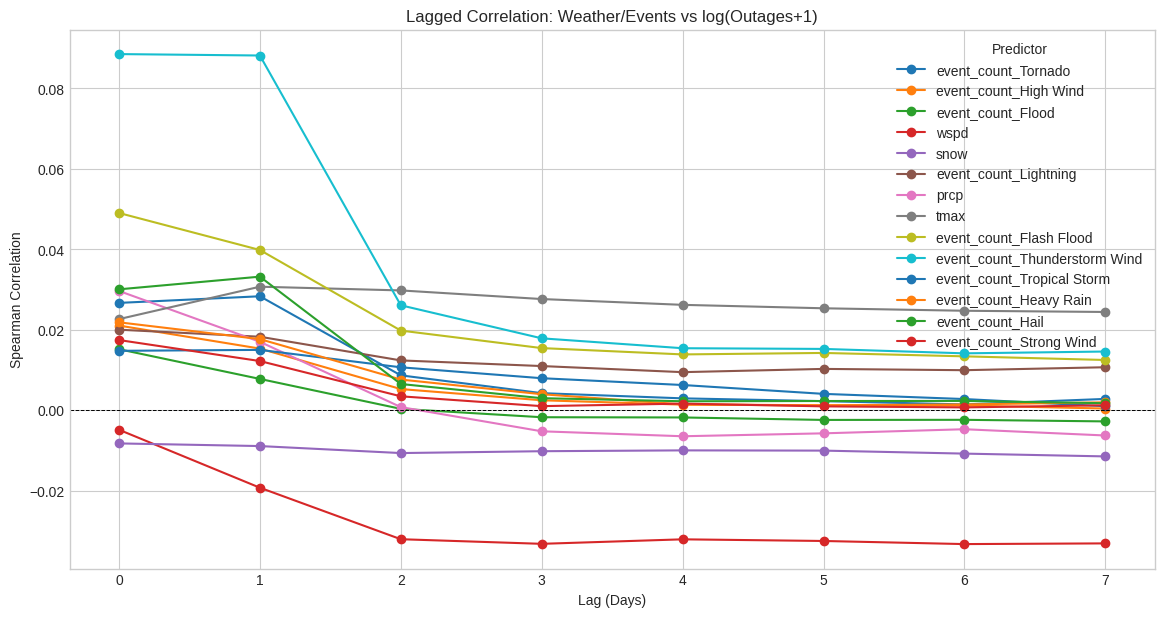

This plot shows how strongly weather/events from 7 days ago correlate with today's outages.
Peaks indicate potentially useful lags for feature engineering.
Cleaned up temporary lagged columns.


In [23]:
# 3. Lag Analysis (Cross-Correlation) - Simplified Approach
# Calculate correlations between lagged weather features and current outages
print("Lag Analysis (Simplified Cross-Correlation)")
print("Calculating correlation between lagged weather and current outages...")

# Focus on key predictors identified earlier or known impact factors
lag_predictors = ['wspd', 'prcp', 'snow', 'tmax']

# Select one or more high-impact event counts if identified
if 'target_event_corr' in locals():
    high_corr_events = target_event_corr['log_customers_out'].abs().nlargest(10).index.tolist()
    lag_predictors.extend(high_corr_events)

# Ensure predictors are unique and exist
lag_predictors = list(set([p for p in lag_predictors if p in df.columns]))

if not lag_predictors:
    print("No key predictors identified or found for lag analysis.")
else:
    max_lag = 7 # Check lags up to 7 days
    lag_corr_results = {}

    # Use log_customers_out as target for potentially better linear relationship detection
    lag_target = 'log_customers_out'

    for predictor in lag_predictors:
        corrs = {}
        for lag in range(max_lag + 1): # Include lag 0 (contemporary)
            lagged_col_name = f'{predictor}_lag{lag}'
            # Shift introduces NaNs at the beginning, which corr() handles by default
            # Group by county before shifting to prevent data leakage across counties?
            # Simple approach first: shift the whole column
            df[lagged_col_name] = df[predictor].shift(lag)

            # Calculate Spearman correlation (robust)
            valid_data = df[[lag_target, lagged_col_name]].dropna()
            if len(valid_data) > 1:
                corr, _ = spearmanr(valid_data[lag_target], valid_data[lagged_col_name])
                corrs[lag] = corr
            else:
                corrs[lag] = np.nan

            # Clean up the temporary lagged column
            # del df[lagged_col_name]

        lag_corr_results[predictor] = corrs

    # Plot the results
    lag_corr_df = pd.DataFrame(lag_corr_results)
    print("\nSpearman Correlation of log(Outages+1) with Lagged Predictors:")
    print(lag_corr_df)

    lag_corr_df.plot(marker='o', figsize=(14, 7))
    plt.title('Lagged Correlation: Weather/Events vs log(Outages+1)')
    plt.xlabel('Lag (Days)')
    plt.ylabel('Spearman Correlation')
    plt.grid(True)
    plt.axhline(0, color='black', linestyle='--', linewidth=0.7)
    plt.legend(title='Predictor')
    plt.show()
    print(f"This plot shows how strongly weather/events from {max_lag} days ago correlate with today's outages.")
    print("Peaks indicate potentially useful lags for feature engineering.")

    # Cleanup lagged columns created for analysis
    lagged_cols_to_drop = [f'{predictor}_lag{lag}' for predictor in lag_predictors for lag in range(max_lag + 1) if f'{predictor}_lag{lag}' in df.columns]
    if lagged_cols_to_drop:
        df.drop(columns=lagged_cols_to_drop, inplace=True)
        print("Cleaned up temporary lagged columns.")

In [24]:
# 4. Stationarity Check (Example on aggregated series)
print("Stationarity Check (ADF Test)")

print("Performing Augmented Dickey-Fuller test on aggregated daily mean outages...")
try:
    adf_result = adfuller(daily_mean_outages_filled)
    print(f'ADF Statistic: {adf_result[0]}')
    print(f'p-value: {adf_result[1]}')
    print('Critical Values:')
    for key, value in adf_result[4].items():
        print(f'\t{key}: {value}')

    if adf_result[1] <= 0.05:
        print("Result: The time series is likely stationary (Reject H0).")
    else:
        print("Result: The time series is likely non-stationary (Fail to reject H0). Differencing might be needed for some models.")
except Exception as e:
    print(f"ADF test failed: {e}. Check data length and NaNs.")

Stationarity Check (ADF Test)
Performing Augmented Dickey-Fuller test on aggregated daily mean outages...
ADF test failed: name 'daily_mean_outages_filled' is not defined. Check data length and NaNs.


---
## E. Geospatial Analysis
---

---
## 2. Geospatial Patterns: Weather by State/County
---

2. Geospatial Patterns: Weather by State/County

Calculating average and extreme weather statistics per state...

State Weather Summary (Mean Values):
        state  tavg_mean  tmin_mean  tmax_mean  prcp_mean  snow_mean  \
0     Alabama  18.254351  13.095672  24.134407  45.882278        0.0   
1      Alaska   2.961839  -1.445537   7.196640   0.314286        0.0   
2     Arizona  16.152037   8.433237  23.868721   0.194386        0.0   
3    Arkansas   3.040143   2.147501   3.970403   0.000000        0.0   
4  California  13.981021   6.335145  19.816170   1.593647        0.0   

   wspd_mean  
0   7.136289  
1   5.145794  
2   8.600219  
3   0.000000  
4   7.610122  

Top 5 States by Max Recorded Wind Speed:
           state   wspd_max
45          Utah  64.800003
34  North Dakota  57.449997
35          Ohio  49.900002
28        Nevada  49.700001
16        Kansas  46.700001

Top 5 States by Max Recorded Precipitation:
        state    prcp_max
0     Alabama  221.100006
43      Texas  189.

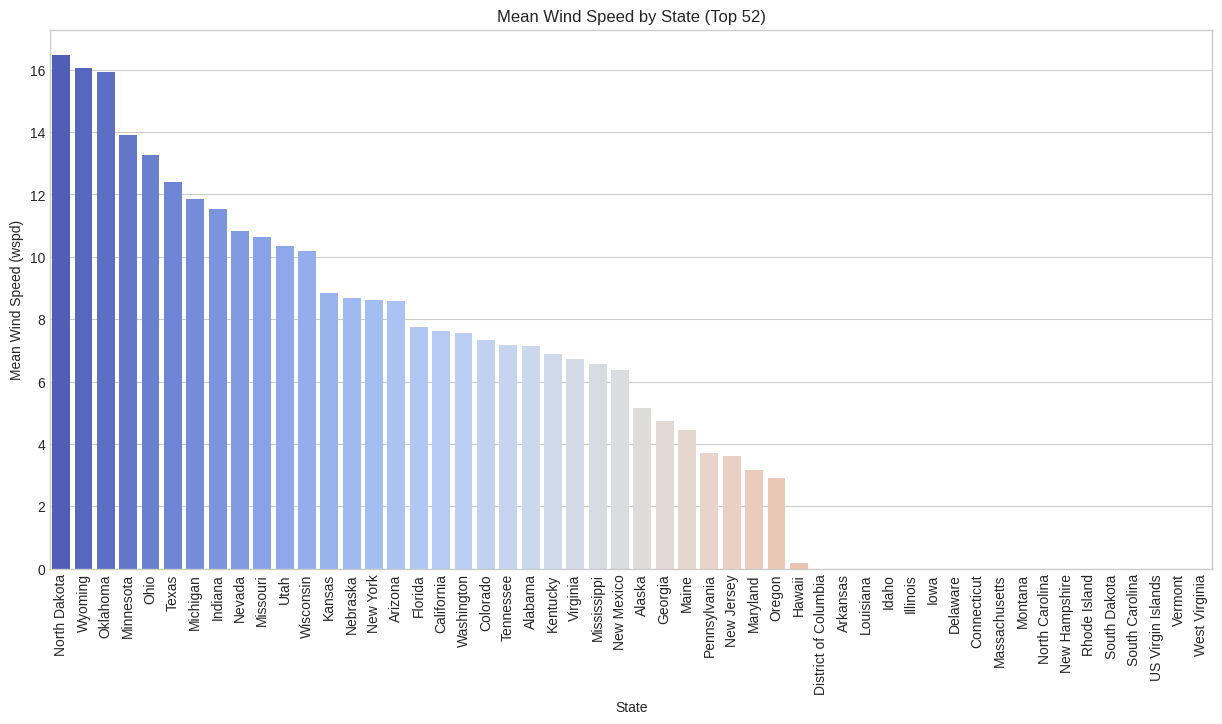


Top 10 Counties by Max Recorded Wind Speed:
             state     county       mean        max
2710          Utah   San Juan  10.994089  64.800003
1959  North Dakota      Stark  16.007183  57.449997
1922  North Dakota   Burleigh  16.215895  57.449997
1921  North Dakota      Burke  16.742058  57.449997
1943  North Dakota     Mercer  16.402054  57.449997
1965  North Dakota       Ward  16.212593  57.449997
1967  North Dakota   Williams  16.198101  57.449997
1944  North Dakota     Morton  16.907143  57.449997
1945  North Dakota  Mountrail  17.687315  57.449997
1929  North Dakota     Emmons  17.695555  57.449997


In [25]:
print("2. Geospatial Patterns: Weather by State/County")

# Aggregate weather statistics by State
if 'state' in geo_cols:
    print("\nCalculating average and extreme weather statistics per state...")
    state_weather_agg = df.groupby('state')[weather_num_cols].agg(['mean', 'median', 'max', 'min', 'std']).reset_index()
    # Flatten MultiIndex columns
    state_weather_agg.columns = ['_'.join(col).strip('_') for col in state_weather_agg.columns.values]

    print("\nState Weather Summary (Mean Values):")
    print(state_weather_agg[[col for col in state_weather_agg.columns if 'mean' in col or col == 'state']].head())

    # Identify states with highest max wind speed, precipitation, snow
    print("\nTop 5 States by Max Recorded Wind Speed:")
    if 'wspd_max' in state_weather_agg.columns:
      print(state_weather_agg.sort_values('wspd_max', ascending=False).head(5)[['state', 'wspd_max']])
    else: print("'wspd_max' not found.")


    print("\nTop 5 States by Max Recorded Precipitation:")
    if 'prcp_max' in state_weather_agg.columns:
      print(state_weather_agg.sort_values('prcp_max', ascending=False).head(5)[['state', 'prcp_max']])
    else: print("'prcp_max' not found.")

    print("\nTop 5 States by Max Recorded Snow:")
    if 'snow_max' in state_weather_agg.columns:
      print(state_weather_agg.sort_values('snow_max', ascending=False).head(5)[['state', 'snow_max']])
    else: print("'snow_max' not found.")


    # Plotting distribution of a key weather variable across states (e.g., Mean Wind Speed)
    if 'wspd_mean' in state_weather_agg.columns:
        plt.figure(figsize=(15, 7))
        # Plot top/bottom N states for clarity
        top_n = 30
        plot_data = state_weather_agg.sort_values('wspd_mean', ascending=False) #.head(top_n)
        sns.barplot(data=plot_data, x='state', y='wspd_mean', palette='coolwarm')
        plt.title(f'Mean Wind Speed by State (Top {len(plot_data)})')
        plt.xlabel('State')
        plt.ylabel('Mean Wind Speed (wspd)')
        plt.xticks(rotation=90)
        plt.show()
    else:
        print("Cannot plot mean wind speed by state ('wspd_mean' not found).")

else:
    print("'state' column not found for geospatial weather analysis.")


if 'county' in geo_cols and 'state' in geo_cols and 'wspd' in df.columns:
    county_weather_agg = df.groupby(['state', 'county'])['wspd'].agg(['mean', 'max']).reset_index()
    print("\nTop 10 Counties by Max Recorded Wind Speed:")
    print(county_weather_agg.sort_values('max', ascending=False).head(10))

---
## 3. Geospatial Patterns: Events by State/County
---

In [26]:
print("3. Geospatial Patterns: Events by State/County")

if 'state' in geo_cols and event_cols:
    print("\nCalculating event frequencies per state...")
    # Calculate sum of event occurrences and frequency per state
    state_event_agg = df.groupby('state')[event_cols].agg(['sum', lambda x: (x > 0).mean()]).reset_index()
    # Flatten columns (e.g., 'event_count_xyz_sum', 'event_count_xyz_<lambda>')
    state_event_agg.columns = ['_'.join(col).replace('_<lambda>','_freq').strip('_') for col in state_event_agg.columns.values]

    # Identify events with most geographic variation (highest standard deviation in frequency across states)
    event_freq_cols = [col for col in state_event_agg.columns if col.endswith('_freq')]
    if event_freq_cols:
        event_variation = state_event_agg[event_freq_cols].std().sort_values(ascending=False)
        print("\nTop 5 Events with Most Variation in Frequency Across States:")
        print(event_variation.head())

        # Plot frequency of a high-variation event across states
        most_variable_event_freq = event_variation.index[0] # the top one
        plt.figure(figsize=(15, 7))
        plot_data_event = state_event_agg.sort_values(most_variable_event_freq, ascending=False)
        sns.barplot(data=plot_data_event, x='state', y=most_variable_event_freq, palette='viridis')
        event_name = most_variable_event_freq.replace('_freq', '')
        plt.title(f'Frequency of Days with {event_name} by State')
        plt.xlabel('State')
        plt.ylabel('Frequency (Proportion of Days)')
        plt.xticks(rotation=90)
        plt.show()
    else:
        print("No event frequency columns found for variation analysis.")


    # Find which states have the highest sum of a specific event (e.g., a high-impact event)
    example_event = event_cols[min(9, len(event_cols)-1)] # Pick ~10th event col as example
    example_event_sum_col = f'{example_event}_sum'
    if example_event_sum_col in state_event_agg.columns:
        print(f"\nTop 5 States by Total Occurrences of '{example_event}':")
        print(state_event_agg.sort_values(example_event_sum_col, ascending=False).head(5)[['state', example_event_sum_col]])
    else:
        print(f"Sum column for example event '{example_event}' not found.")

else:
    print("'state' column or event count columns not found for geospatial event analysis.")

3. Geospatial Patterns: Events by State/County

Calculating event frequencies per state...
No event frequency columns found for variation analysis.

Top 5 States by Total Occurrences of 'event_count_Extreme Cold/Wind Chill':
           state  event_count_Extreme Cold/Wind Chill_sum
23     Minnesota                               214.196075
38  Pennsylvania                               166.286148
32      New York                               149.680725
15          Iowa                               144.402512
35          Ohio                               105.256569


---
## 4. Geospatial Patterns: Severity by State/County
---

4. Geospatial Patterns: Severity by State/County

Analyzing outage severity distribution per state...

Severity Distribution (Proportion) per State:
severity         0.0       1.0       2.0       3.0       4.0       5.0  \
state                                                                    
Alabama     0.059540  0.005923  0.058167  0.227881  0.091571  0.120384   
Alaska      0.151226  0.033606  0.129181  0.107446  0.047325  0.088485   
Arizona     0.074668  0.007973  0.040806  0.054951  0.041063  0.098328   
Arkansas    0.145196  0.012219  0.128223  0.148668  0.070901  0.119245   
California  0.064046  0.011879  0.050487  0.046631  0.029823  0.062009   

severity         6.0       7.0       8.0       9.0  
state                                               
Alabama     0.117069  0.118234  0.112421  0.088811  
Alaska      0.104208  0.102204  0.102667  0.133652  
Arizona     0.116245  0.116931  0.165109  0.283926  
Arkansas    0.107161  0.100218  0.086746  0.081422  
California  0.

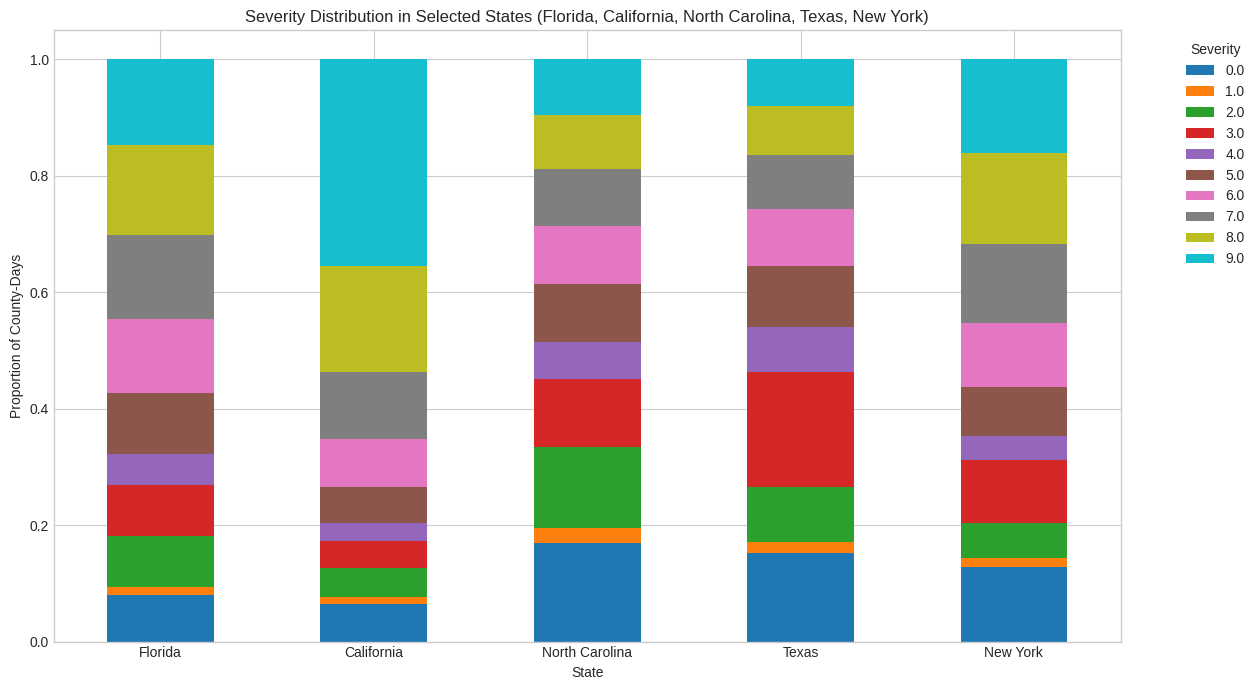


Calculating mean outage magnitude (on days with outages > 0) per state...

Top 10 States by Mean Outage Magnitude (when > 0):
state
US Virgin Islands    535.557251
California           317.540588
Connecticut          293.269989
Florida              259.566406
Maine                209.967560
Massachusetts        191.924332
New Jersey           188.785919
Hawaii               172.880936
Arizona              169.293640
Rhode Island         159.375687
Name: customers_out, dtype: float32


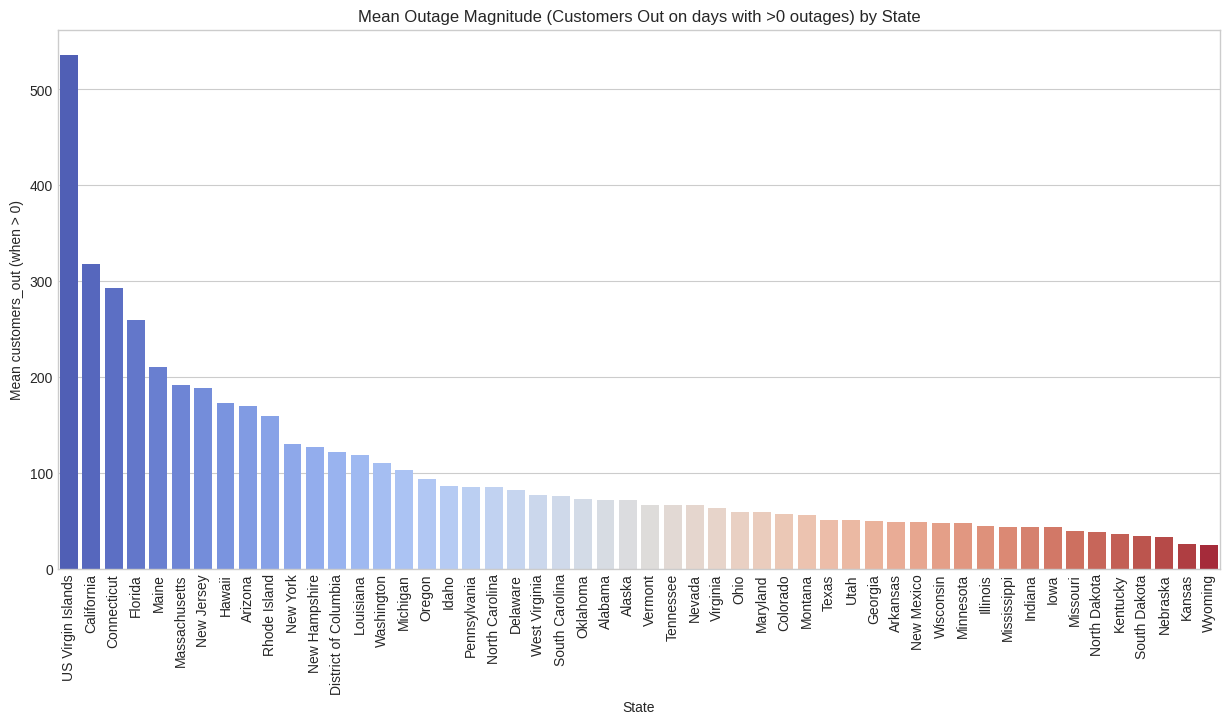

In [27]:
print("4. Geospatial Patterns: Severity by State/County")

if 'state' in geo_cols and severity_col in df.columns and target_col in df.columns:
    print("\nAnalyzing outage severity distribution per state...")

    # Calculate the proportion of each severity level within each state
    severity_dist = df.groupby('state')[severity_col].value_counts(normalize=True).unstack(fill_value=0)
    print("\nSeverity Distribution (Proportion) per State:")
    print(severity_dist.head())

    # Plot distribution for a few states (top 5 by total outages)
    if 'state_agg' in locals():
         top_states = state_agg.sort_values('total_outages', ascending=False)['state'].head(5).tolist()
    else: # Or just pick first 5 states
        top_states = df['state'].unique()[:5]

    if len(top_states)>0:
        severity_dist.loc[top_states].plot(kind='bar', stacked=True, figsize=(15, 7), colormap='tab10')
        plt.title(f'Severity Distribution in Selected States ({", ".join(top_states)})')
        plt.xlabel('State')
        plt.ylabel('Proportion of County-Days')
        plt.xticks(rotation=0)
        plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.show()
    else:
        print("No states selected for plotting severity distribution.")


    # Calculate average outage magnitude *when outages occur*
    print("\nCalculating mean outage magnitude (on days with outages > 0) per state...")
    df_with_outages = df[df[target_col] > 0].copy()
    if not df_with_outages.empty:
        mean_magnitude_state = df_with_outages.groupby('state')[target_col].mean().sort_values(ascending=False)
        print("\nTop 10 States by Mean Outage Magnitude (when > 0):")
        print(mean_magnitude_state.head(10))

        # Plot this
        plt.figure(figsize=(15, 7))
        plot_data_mag = mean_magnitude_state.reset_index() #.head(top_n)
        sns.barplot(data=plot_data_mag, x='state', y=target_col, palette='coolwarm')
        plt.title('Mean Outage Magnitude (Customers Out on days with >0 outages) by State')
        plt.xlabel('State')
        plt.ylabel(f'Mean {target_col} (when > 0)')
        plt.xticks(rotation=90)
        plt.show()
    else:
        print("No days with outages found to calculate mean magnitude.")

else:
    print("Required columns ('state', 'severity', 'customers_out') not found for severity analysis.")

 ---
## Geospatial Analysis (Using GeoPandas)
 ---

E. Geospatial Analysis (Using GeoPandas)
Loading shapefile from: /content/cb_2020_us_county_500k.shp
Shapefile loaded successfully. Shape: (3234, 13)
Aggregating outage and weather data (including temperature) per county...
Performing aggregation for columns: ['customers_out', 'customers_out', 'customers_out', 'log_customers_out', 'customers_out', 'customers_out', 'customers_out', 'wspd', 'tavg', 'tavg', 'tmax', 'tmin']
County aggregated data shape: (3056, 14)
Filtering GeoDataFrame to Contiguous US (CONUS)...
Merging GeoDataFrame with aggregated data using FIPS code ('GEOID' and 'fips_code')...
Merged GeoDataFrame shape: (3108, 27)
Successfully merged data for 3042 out of 3108 CONUS counties.

Creating Choropleth Maps...


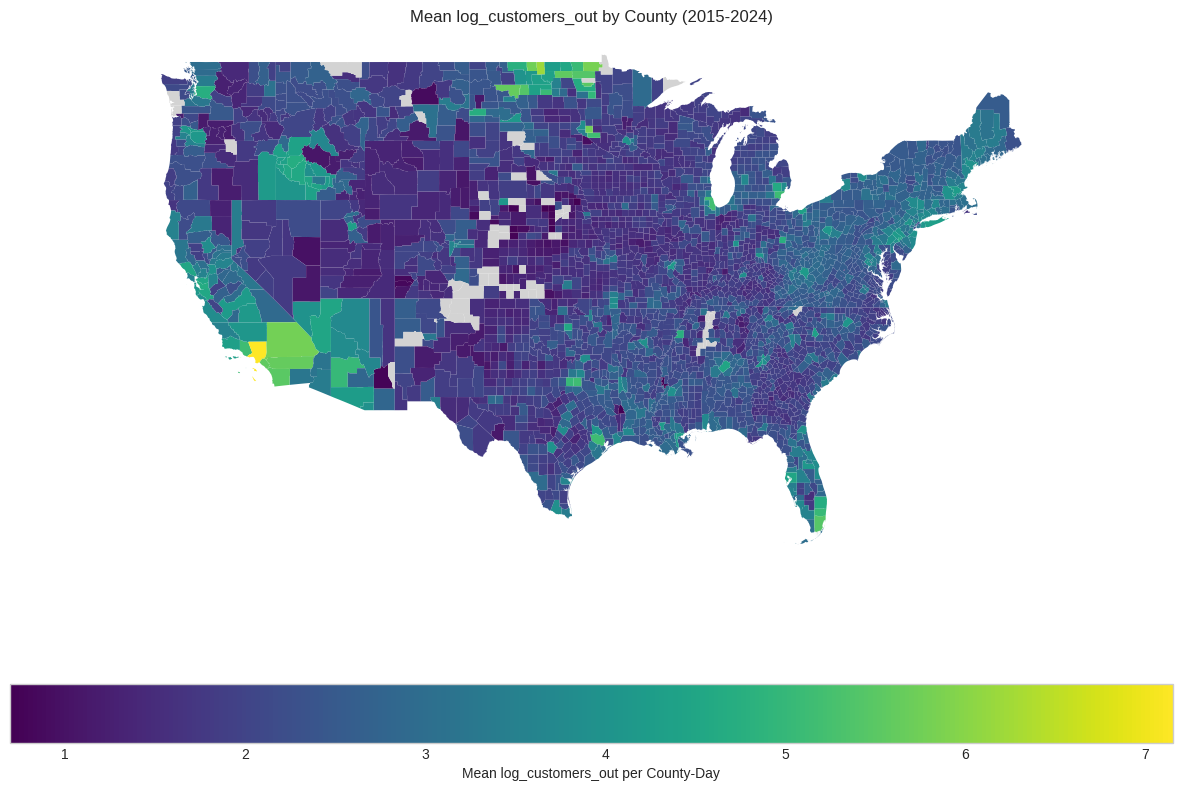

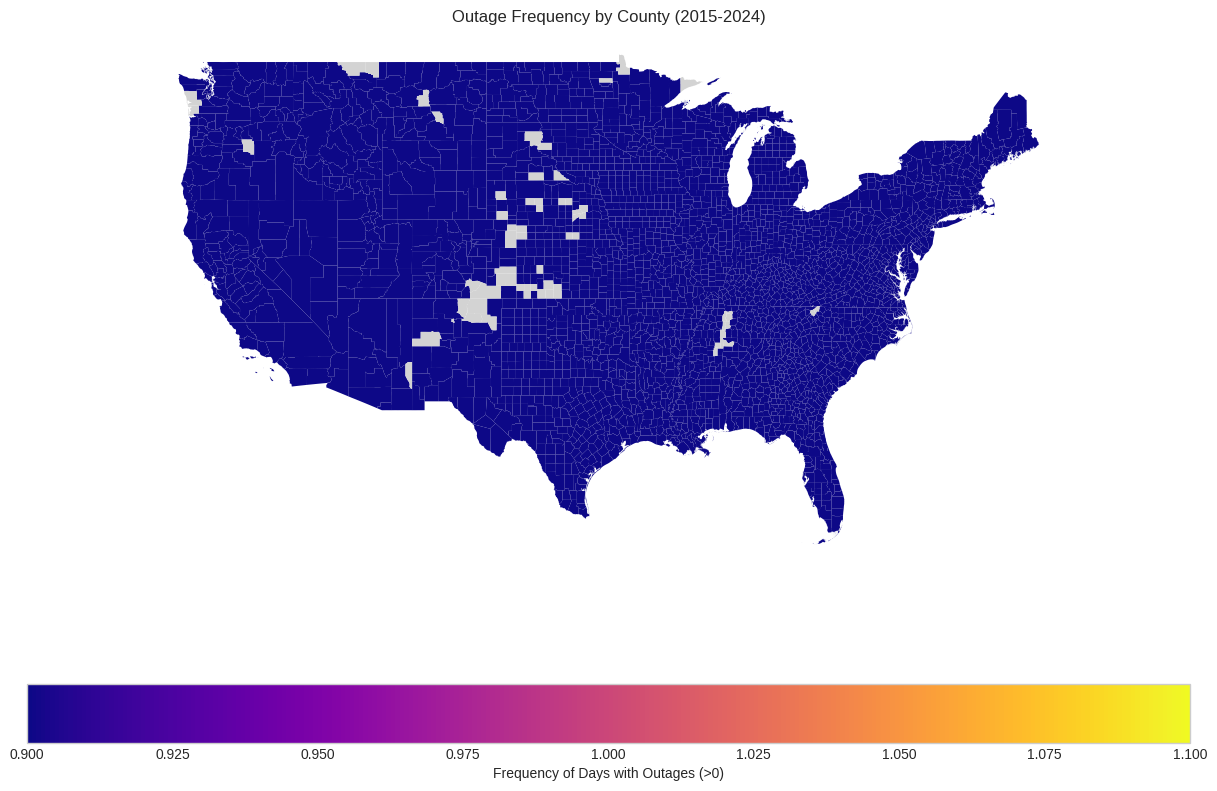

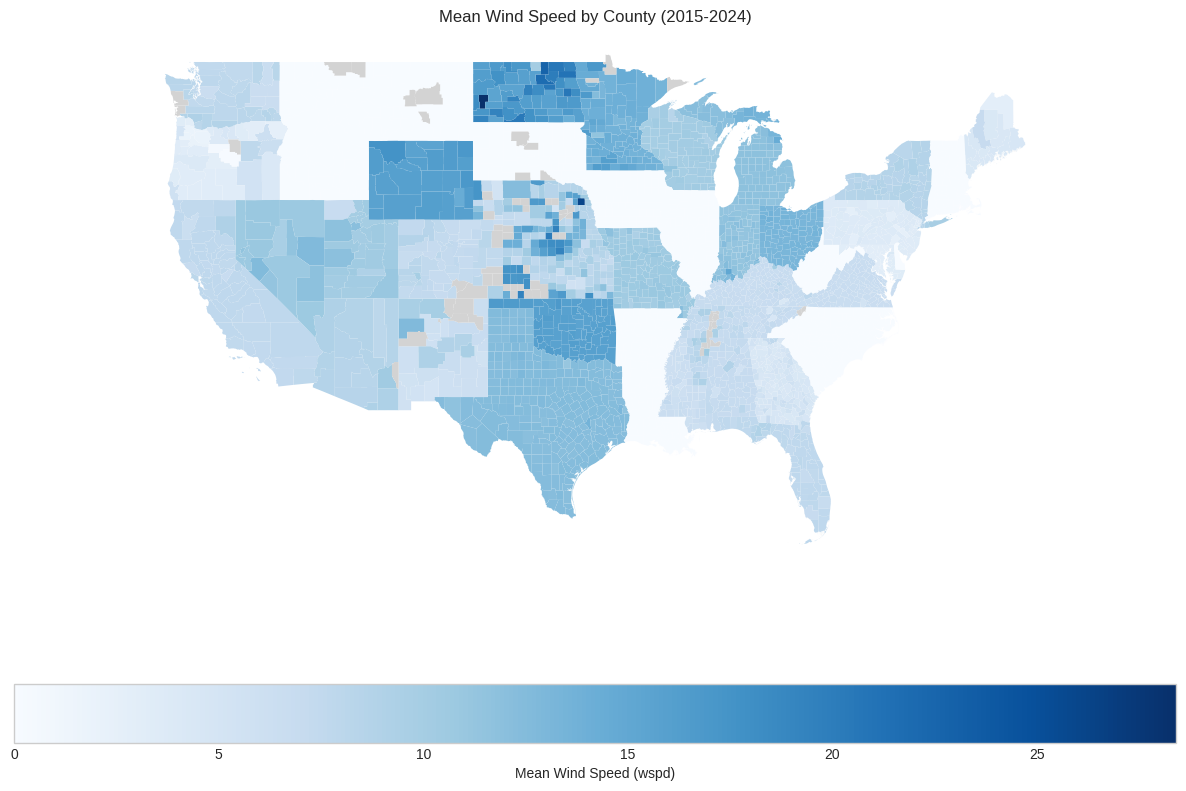

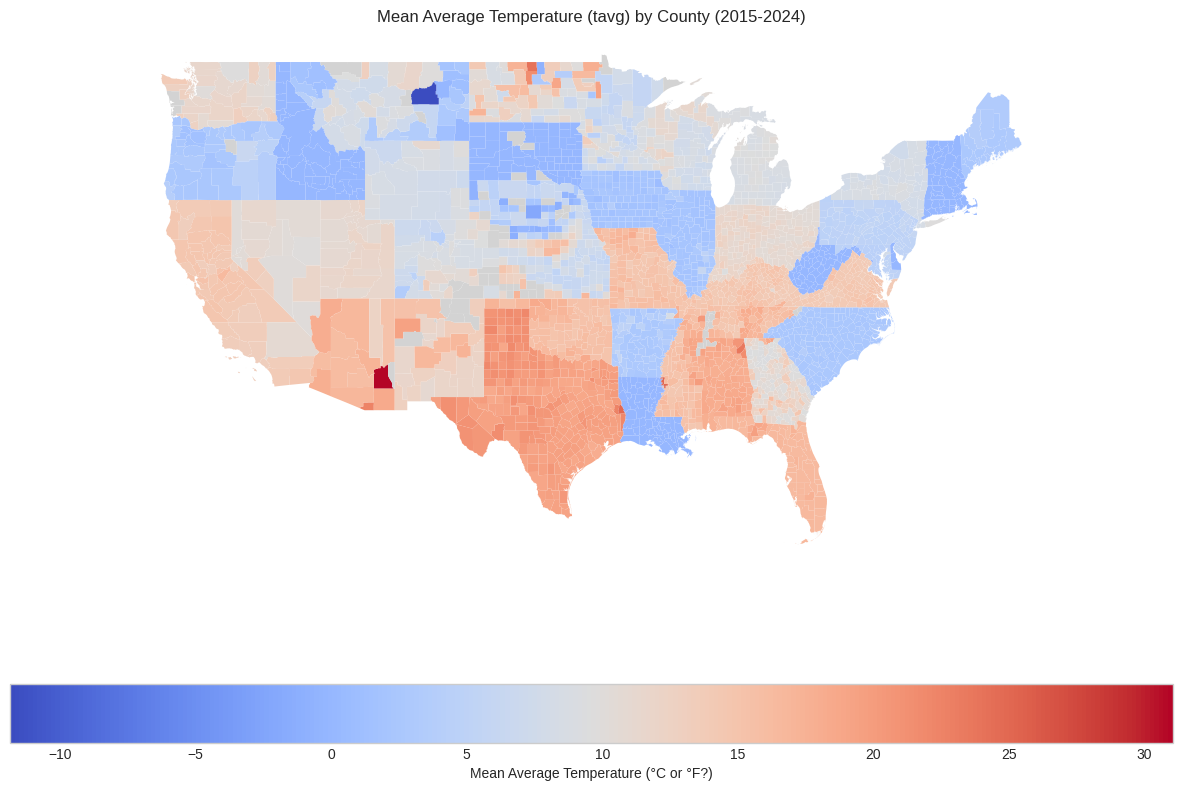

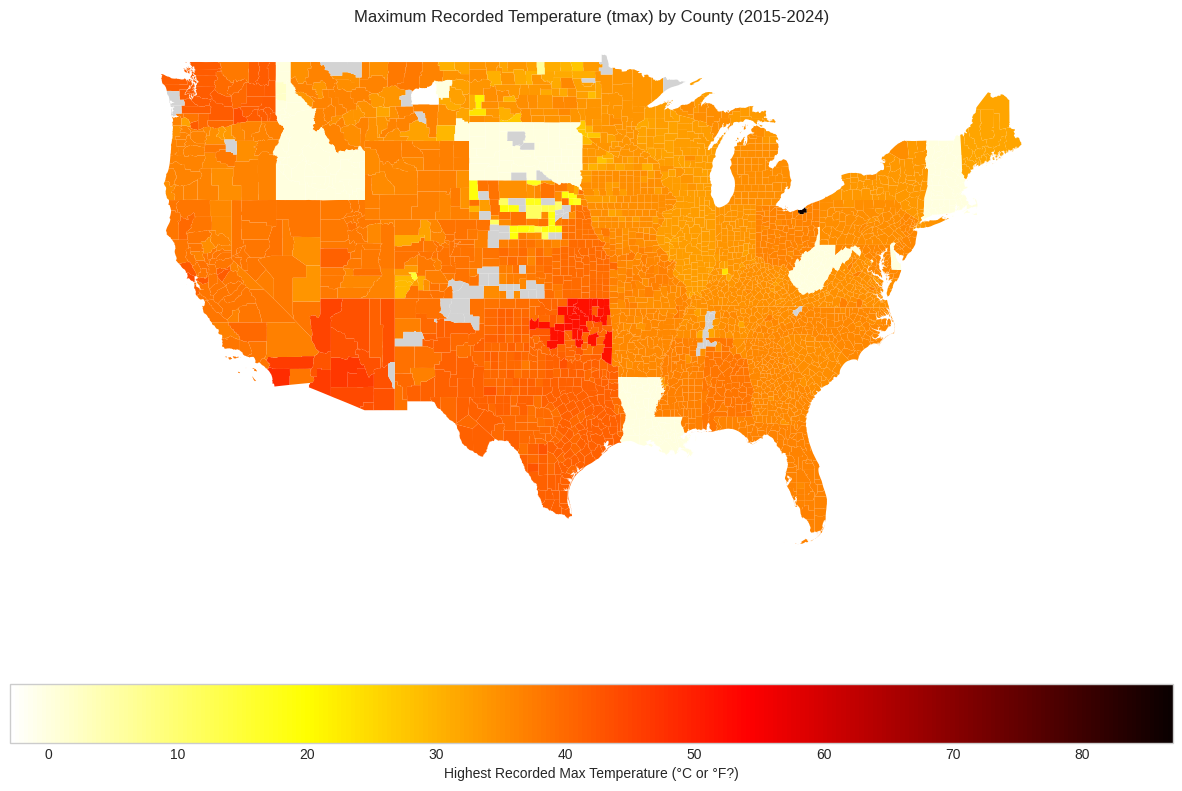

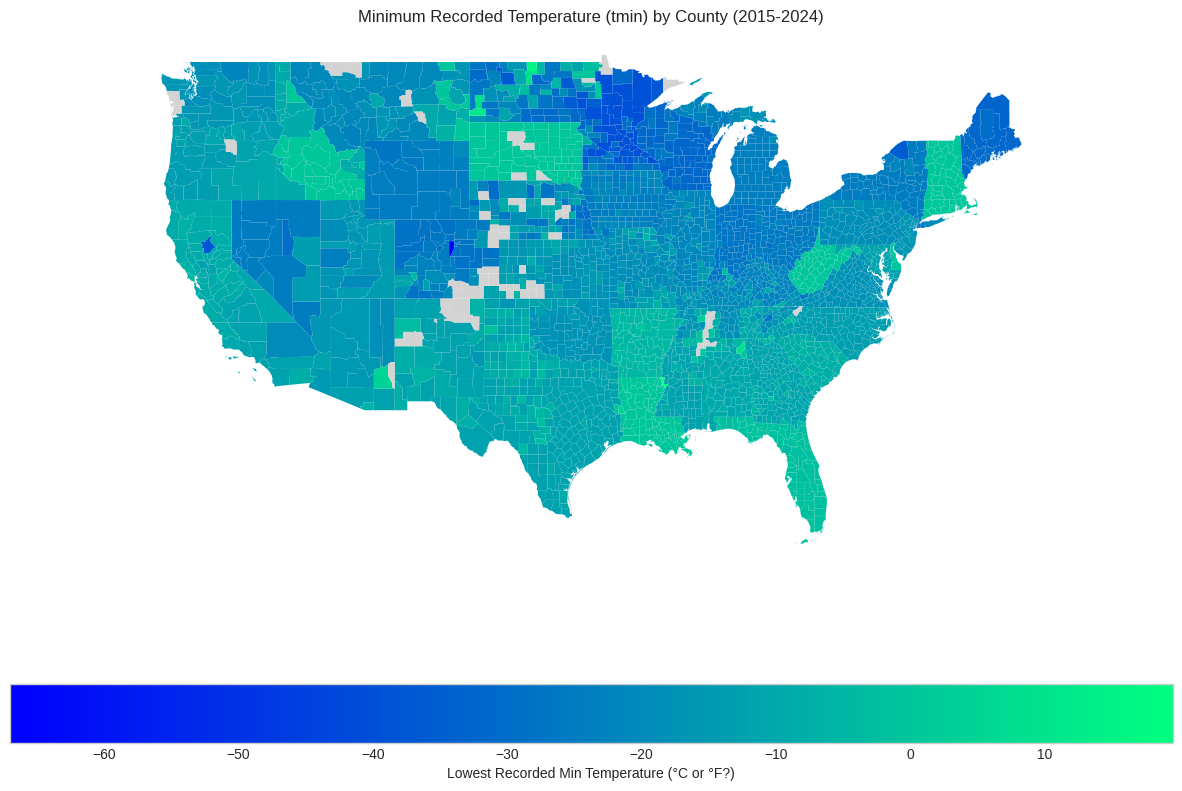

In [28]:
print("E. Geospatial Analysis (Using GeoPandas)")

if not GEOPANDAS_AVAILABLE:
    print("Skipping GeoPandas analysis as the library is not available.")
else:

    shapefile_path = '/content/cb_2020_us_county_500k.shp'
    shapefile_fips_col = 'GEOID' # GEOID or FIPS

    # Load Shapefile
    try:
        print(f"Loading shapefile from: {shapefile_path}")
        gdf = gpd.read_file(shapefile_path)
        print(f"Shapefile loaded successfully. Shape: {gdf.shape}")
        # print(f"Shapefile columns: {gdf.columns.tolist()}")

        # Data Aggregation per County (with Temperature)
        print("Aggregating outage and weather data (including temperature) per county...")
        if 'fips_code' not in df.columns:
             raise ValueError("'fips_code' column is required in the main DataFrame for merging.")

        # Add temperature aggregations
        agg_dict = {
            'total_outages': (target_col, 'sum'),
            'mean_outages': (target_col, 'mean'),
            'median_outages': (target_col, 'median'),
            'mean_log_outages': (log_target_col, 'mean'),
            'max_outages': (target_col, 'max'),
            'days_with_outages': (target_col, lambda x: (x > 0).sum()),
            'record_count': (target_col, 'count'),
            'mean_wspd': ('wspd', 'mean'),
            'mean_tavg': ('tavg', 'mean'),
            'median_tavg': ('tavg', 'median'),
            'max_tmax': ('tmax', 'max'), # Overall max temperature recorded
            'min_tmin': ('tmin', 'min')  # Overall min temperature recorded
        }

        # Filter dictionary for columns actually present in df
        valid_agg_dict = {
            new_col: (orig_col, func)
            for new_col, (orig_col, func) in agg_dict.items()
            if orig_col in df.columns
        }
        print(f"Performing aggregation for columns: {[v[0] for v in valid_agg_dict.values()]}")

        if not valid_agg_dict:
            raise ValueError("No valid columns found for aggregation.")

        county_agg = df.groupby('fips_code').agg(**valid_agg_dict).reset_index()

        # Calculate frequency separately as it uses an aggregated column
        if 'days_with_outages' in county_agg.columns and 'record_count' in county_agg.columns:
            county_agg['outage_frequency'] = county_agg['days_with_outages'] / county_agg['record_count']
        else:
             print("Warning: Could not calculate outage_frequency.")

        print(f"County aggregated data shape: {county_agg.shape}")
        # print(county_agg.head())

        # Prepare for Merge
        # Check if the specified FIPS column exists in the shapefile
        if shapefile_fips_col not in gdf.columns:
            print(f"Warning: Specified FIPS column '{shapefile_fips_col}' not found in shapefile.")
            print("Available columns:", gdf.columns.tolist())
            # Attempt common alternatives or creation if possible
            if 'GEOID' in gdf.columns:
                print("Trying 'GEOID' as FIPS column.")
                shapefile_fips_col = 'GEOID'
            elif 'FIPS' in gdf.columns:
                 print("Trying 'FIPS' as FIPS column.")
                 shapefile_fips_col = 'FIPS'
            elif 'STATEFP' in gdf.columns and 'COUNTYFP' in gdf.columns:
                 print("Attempting to create FIPS from STATEFP+COUNTYFP.")
                 gdf[shapefile_fips_col] = gdf['STATEFP'].astype(str).str.zfill(2) + gdf['COUNTYFP'].astype(str).str.zfill(3)
                 print(f"Created '{shapefile_fips_col}' column in GeoDataFrame.")
            else:
                 raise ValueError(f"Cannot find or create a suitable FIPS column in the shapefile.")

        # Ensure FIPS codes are strings for merging
        gdf[shapefile_fips_col] = gdf[shapefile_fips_col].astype(str).str.strip()
        county_agg['fips_code'] = county_agg['fips_code'].astype(str).str.strip()

        excluded_states = ['02', '15', '60', '66', '69', '72', '78']
        state_fips_col = 'STATEFP'
        if state_fips_col in gdf.columns:
            print("Filtering GeoDataFrame to Contiguous US (CONUS)...")
            gdf_conus = gdf[~gdf[state_fips_col].isin(excluded_states)].copy()
            if gdf_conus.empty: gdf_conus = gdf # Fallback
        else:
            print(f"Warning: State FIPS column '{state_fips_col}' not found. Cannot filter to CONUS.")
            gdf_conus = gdf

        # Merge GeoDataFrame with Aggregated Data
        print(f"Merging GeoDataFrame with aggregated data using FIPS code ('{shapefile_fips_col}' and 'fips_code')...")
        merged_gdf = gdf_conus.merge(county_agg, left_on=shapefile_fips_col, right_on='fips_code', how='left')
        print(f"Merged GeoDataFrame shape: {merged_gdf.shape}")

        # Check merge success
        merge_check_col = 'mean_log_outages'
        if merge_check_col in merged_gdf.columns:
            num_merged = merged_gdf[merge_check_col].notna().sum()
            print(f"Successfully merged data for {num_merged} out of {len(gdf_conus)} CONUS counties.")
            if num_merged == 0: print("Merge Warning: No counties matched. Check FIPS codes.")
        else:
             num_merged = 0
             print(f"Warning: Merge check column '{merge_check_col}' not found after merge.")


        # Create Choropleth Maps
        if num_merged > 0:
            print("\nCreating Choropleth Maps...")

            # Map 1: Mean Log Outages
            plot_col = 'mean_log_outages'
            if plot_col in merged_gdf.columns:
                fig1, ax1 = plt.subplots(1, 1, figsize=(15, 10))
                merged_gdf.plot(column=plot_col, ax=ax1, legend=True, cmap='viridis',
                                missing_kwds={'color': 'lightgrey'},
                                legend_kwds={'label': f"Mean {log_target_col} per County-Day", 'orientation': "horizontal"})
                ax1.set_title(f'Mean {log_target_col} by County (2015-2024)')
                ax1.set_axis_off()
                plt.show()
            else: print(f"Skipping map for {plot_col}, column not found.")

            # Map 2: Outage Frequency
            plot_col = 'outage_frequency'
            if plot_col in merged_gdf.columns:
                fig2, ax2 = plt.subplots(1, 1, figsize=(15, 10))
                merged_gdf.plot(column=plot_col, ax=ax2, legend=True, cmap='plasma',
                                missing_kwds={'color': 'lightgrey'},
                                legend_kwds={'label': "Frequency of Days with Outages (>0)", 'orientation': "horizontal"})
                ax2.set_title('Outage Frequency by County (2015-2024)')
                ax2.set_axis_off()
                plt.show()
            else: print(f"Skipping map for {plot_col}, column not found.")

            # Map 3: Mean Wind Speed
            plot_col = 'mean_wspd'
            if plot_col in merged_gdf.columns:
                 fig3, ax3 = plt.subplots(1, 1, figsize=(15, 10))
                 merged_gdf.plot(column=plot_col, ax=ax3, legend=True, cmap='Blues', # Changed cmap
                                 missing_kwds={'color': 'lightgrey'},
                                 legend_kwds={'label': "Mean Wind Speed (wspd)", 'orientation': "horizontal"})
                 ax3.set_title('Mean Wind Speed by County (2015-2024)')
                 ax3.set_axis_off()
                 plt.show()
            else: print(f"Skipping map for {plot_col}, column not found.")

            # Map 4: Mean Average Temperature (tavg)
            plot_col = 'mean_tavg'
            if plot_col in merged_gdf.columns:
                 fig4, ax4 = plt.subplots(1, 1, figsize=(15, 10))
                 merged_gdf.plot(column=plot_col, ax=ax4, legend=True, cmap='coolwarm', # Good cmap for temperature
                                 missing_kwds={'color': 'lightgrey'},
                                 legend_kwds={'label': "Mean Average Temperature (°C or °F?)", 'orientation': "horizontal"})
                 ax4.set_title('Mean Average Temperature (tavg) by County (2015-2024)')
                 ax4.set_axis_off()
                 plt.show()
            else: print(f"Skipping map for {plot_col}, column not found.")

            # Map 5: Max Recorded Temperature (tmax)
            plot_col = 'max_tmax'
            if plot_col in merged_gdf.columns:
                 fig5, ax5 = plt.subplots(1, 1, figsize=(15, 10))
                 merged_gdf.plot(column=plot_col, ax=ax5, legend=True, cmap='hot_r', # Reversed hot cmap for max temp
                                 missing_kwds={'color': 'lightgrey'},
                                 legend_kwds={'label': "Highest Recorded Max Temperature (°C or °F?)", 'orientation': "horizontal"})
                 ax5.set_title('Maximum Recorded Temperature (tmax) by County (2015-2024)')
                 ax5.set_axis_off()
                 plt.show()
            else: print(f"Skipping map for {plot_col}, column not found.")

            # Map 6: Min Recorded Temperature (tmin)
            plot_col = 'min_tmin'
            if plot_col in merged_gdf.columns:
                 fig6, ax6 = plt.subplots(1, 1, figsize=(15, 10))
                 merged_gdf.plot(column=plot_col, ax=ax6, legend=True, cmap='winter', # Winter cmap for min temp
                                 missing_kwds={'color': 'lightgrey'},
                                 legend_kwds={'label': "Lowest Recorded Min Temperature (°C or °F?)", 'orientation': "horizontal"})
                 ax6.set_title('Minimum Recorded Temperature (tmin) by County (2015-2024)')
                 ax6.set_axis_off()
                 plt.show()
            else: print(f"Skipping map for {plot_col}, column not found.")

        else:
            print("Skipping map creation as no data was successfully merged.")

    except FileNotFoundError:
        print(f"Error: Shapefile not found at '{shapefile_path}'.")
        print("Please update the 'shapefile_path' variable.")
    except ValueError as ve: # Catch specific errors like missing columns
        print(f"ValueError during Geospatial analysis: {ve}")
    except Exception as e:
        print(f"An unexpected error occurred during GeoPandas analysis: {e}")
        import traceback
        traceback.print_exc()

    gc.collect() # Clean up memory

---
## F. Focus on Extreme/Rare Events
---

In [29]:
print("Analysis Focused on Extreme/Rare Events")

# 1. Identify Extreme Thresholds
print("Identifying extreme weather thresholds (e.g., 95th percentile)...")
extreme_thresholds = {}
weather_cols_for_extremes = ['wspd', 'prcp', 'snow', 'tmax'] # Focus on potentially damaging weather
for col in weather_cols_for_extremes:
    if col in df.columns:
        # Consider threshold based on non-zero values for sparse data like snow/prcp
        if col in ['prcp', 'snow']:
            non_zero_values = df[df[col] > 0][col]
            if not non_zero_values.empty:
                extreme_thresholds[col] = non_zero_values.quantile(0.95)
            else:
                 extreme_thresholds[col] = 0 # Or handle differently if no non-zero values
        else:
            extreme_thresholds[col] = df[col].quantile(0.95)
        print(f"  - {col} > {extreme_thresholds[col]:.2f} (95th percentile{' of non-zero values' if col in ['prcp','snow'] and not non_zero_values.empty else ''})")


rare_event_cols = []
if 'target_event_corr' in locals(): # Use least frequent but potentially high impact
    rare_event_cols = sparsity_series[sparsity_series < 1.0].head(10).index.tolist() # Example: events occurring < 1% of days
    print(f"\nIdentifying rare event occurrences (e.g., <1% frequency): {rare_event_cols}")

Analysis Focused on Extreme/Rare Events
Identifying extreme weather thresholds (e.g., 95th percentile)...
  - wspd > 19.55 (95th percentile)
  - prcp > 42.70 (95th percentile of non-zero values)
  - snow > 102.00 (95th percentile of non-zero values)
  - tmax > 32.85 (95th percentile)

Identifying rare event occurrences (e.g., <1% frequency): ['event_count_Marine Thunderstorm Wind', 'event_count_Marine High Wind', 'event_count_Marine Strong Wind', 'event_count_Marine Tropical Storm', 'event_count_Marine Dense Fog', 'event_count_Marine Hail', 'event_count_Tsunami', 'event_count_Marine Lightning', 'event_count_Marine Tropical Depression', 'event_count_Marine Hurricane/Typhoon']



Comparing outage statistics on extreme vs non-extreme days...

Outage Statistics (log_customers_out):
--- Non-Extreme Days ---
count    3.579227e+06
mean     2.356500e+00
std      1.561787e+00
min      6.931472e-01
25%      1.078810e+00
50%      1.933934e+00
75%      3.308766e+00
max      1.367127e+01
Name: log_customers_out, dtype: float64

--- Extreme Days (High Weather Quantiles or Rare Events) ---
count    184522.000000
mean          2.539852
std           1.719038
min           0.693147
25%           1.098612
50%           2.036882
75%           3.652851
max          12.082136
Name: log_customers_out, dtype: float64


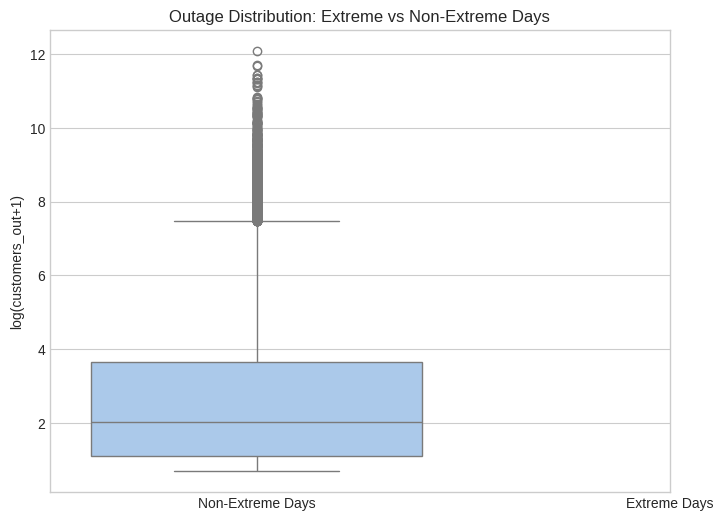

In [30]:
# 2. Analyze Outages During Extremes
print("\nComparing outage statistics on extreme vs non-extreme days...")

# Create boolean masks for extreme conditions
extreme_wspd_mask = df['wspd'] > extreme_thresholds.get('wspd', np.inf)
extreme_prcp_mask = df['prcp'] > extreme_thresholds.get('prcp', np.inf)
extreme_snow_mask = df['snow'] > extreme_thresholds.get('snow', np.inf)
extreme_tmax_mask = df['tmax'] > extreme_thresholds.get('tmax', np.inf) # Extreme heat

# Example: Combine conditions - e.g., high wind OR heavy precip OR heavy snow
extreme_weather_mask = extreme_wspd_mask | extreme_prcp_mask | extreme_snow_mask # Add others as needed

# Filter for rare event occurrences
rare_event_mask = pd.Series(False, index=df.index)
for event_col in rare_event_cols:
    if event_col in df.columns:
        rare_event_mask = rare_event_mask | (df[event_col] > 0)

# Combine masks: Any extreme weather OR a rare named event
combined_extreme_mask = extreme_weather_mask | rare_event_mask

df_extreme = df[combined_extreme_mask]
df_non_extreme = df[~combined_extreme_mask]

print("\nOutage Statistics (log_customers_out):")
print("--- Non-Extreme Days ---")
if not df_non_extreme.empty:
    print(df_non_extreme['log_customers_out'].describe())
else:
    print("No non-extreme days found.")

print("\n--- Extreme Days (High Weather Quantiles or Rare Events) ---")
if not df_extreme.empty:
    print(df_extreme['log_customers_out'].describe())
else:
    print("No extreme days found based on defined criteria.")


# Visualize comparison
if not df_extreme.empty and not df_non_extreme.empty:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=[df_non_extreme['log_customers_out'], df_extreme['log_customers_out']],
                palette='pastel')
    plt.xticks([0, 1], ['Non-Extreme Days', 'Extreme Days'])
    plt.ylabel(f'log({target_col}+1)')
    plt.title('Outage Distribution: Extreme vs Non-Extreme Days')
    plt.show()
else:
    print("Skipping extreme vs non-extreme plot due to empty subset(s).")

In [31]:
# 3. Event Correlation (Revisit specific rare/severe events)
print("\nRevisiting Correlation for specific rare/severe event types (if identified)...")
if 'event_count_Marine Hurricane/Typhoon' in df.columns:
     hurricane_corr, _ = spearmanr(df['log_customers_out'].fillna(0), df['event_count_Marine Hurricane/Typhoon'].fillna(0))
     print(f"Correlation between log(Outages+1) and 'event_count_hurricane': {hurricane_corr:.3f}")
     # Compare mean outages on hurricane days vs non-hurricane days
     mean_outage_hurricane = df.loc[df['event_count_Marine Hurricane/Typhoon'] > 0, 'log_customers_out'].mean()
     mean_outage_no_hurricane = df.loc[df['event_count_Marine Hurricane/Typhoon'] == 0, 'log_customers_out'].mean()
     print(f"  - Mean log(Outages+1) on Hurricane Days: {mean_outage_hurricane:.2f}")
     print(f"  - Mean log(Outages+1) on Non-Hurricane Days: {mean_outage_no_hurricane:.2f}")


Revisiting Correlation for specific rare/severe event types (if identified)...
Correlation between log(Outages+1) and 'event_count_hurricane': nan
  - Mean log(Outages+1) on Hurricane Days: nan
  - Mean log(Outages+1) on Non-Hurricane Days: 2.38


---
## G. Unsupervised Learning Approaches (Exploratory)
---
These are more advanced exploratory steps.

Unsupervised Learning: Outage Anomaly Detection (Exploratory)
Applying Isolation Forest to detect potentially anomalous outage days...
Detected 1268658 potential outage anomalies (33.71% of days with data).

Characteristics of Detected Outage Anomalies:

Weather during anomalies:
               tavg          tmin          tmax           prcp           snow  \
count  1.268658e+06  1.268658e+06  1.268658e+06  615591.000000  507184.000000   
mean   9.629778e+00  6.233827e+00  1.321345e+01       0.918621       0.020218   
std    1.061480e+01  9.161699e+00  1.288931e+01       6.162402       1.287399   
min   -3.315000e+01 -3.940000e+01 -2.900000e+01       0.000000       0.000000   
25%    0.000000e+00  0.000000e+00  0.000000e+00       0.000000       0.000000   
50%    6.825000e+00  1.350000e+00  1.200000e+01       0.000000       0.000000   
75%    2.000000e+01  1.430667e+01  2.588512e+01       0.000000       0.000000   
max    4.530000e+01  4.100000e+01  8.700000e+01     221.100006     178.

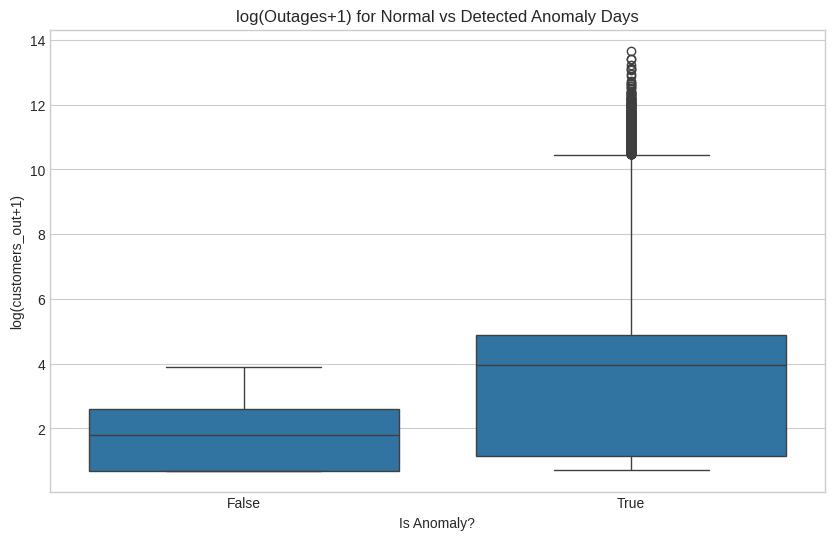


Overlap between detected anomalies and defined 'extreme' days:
col_0                False   True 
is_outage_anomaly                 
False              2378510  116581
True               1200717   67941


In [32]:
# 1. Outage Anomaly Detection
print("Unsupervised Learning: Outage Anomaly Detection (Exploratory)")
print("Applying Isolation Forest to detect potentially anomalous outage days...")

# Select features for anomaly detection - could be just the target, or target + key predictors
# Using just log_customers_out for simplicity here
features_for_anomaly = ['log_customers_out']
data_for_anomaly = df[features_for_anomaly].dropna()

if not data_for_anomaly.empty:
    # scaler = StandardScaler()
    # data_scaled = scaler.fit_transform(data_for_anomaly)

    # Initialize and fit Isolation Forest
    # contamination='auto' lets the algorithm estimate the proportion of outliers
    iso_forest = IsolationForest(contamination='auto', random_state=42)
    anomaly_preds = iso_forest.fit_predict(data_for_anomaly) # Returns 1 for inliers, -1 for outliers

    # Add anomaly predictions back to the original DataFrame (matching indices)
    df.loc[data_for_anomaly.index, 'is_outage_anomaly'] = anomaly_preds
    df['is_outage_anomaly'] = df['is_outage_anomaly'] == -1 # Convert to boolean True for anomalies

    n_anomalies = df['is_outage_anomaly'].sum()
    print(f"Detected {n_anomalies} potential outage anomalies ({n_anomalies / len(data_for_anomaly) * 100:.2f}% of days with data).")

    # Analyze characteristics of detected anomalies
    if n_anomalies > 0:
        print("\nCharacteristics of Detected Outage Anomalies:")
        anomaly_df = df[df['is_outage_anomaly'] == True]
        print("\nWeather during anomalies:")
        print(anomaly_df[weather_num_cols].describe())
        print("\nEvents during anomalies (sum):")
        if event_cols:
            print(anomaly_df[event_cols].sum().sort_values(ascending=False).head(10))
        else:
            print("No event columns found.")

        # Compare anomalies to non-anomalies
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x='is_outage_anomaly', y='log_customers_out')
        plt.title('log(Outages+1) for Normal vs Detected Anomaly Days')
        plt.xlabel('Is Anomaly?')
        plt.ylabel(f'log({target_col}+1)')
        plt.show()

        # Cross-reference: Do anomalies correspond to days flagged as 'extreme'?
        if 'combined_extreme_mask' in locals():
            print(f"\nOverlap between detected anomalies and defined 'extreme' days:")
            print(pd.crosstab(df['is_outage_anomaly'], combined_extreme_mask))

    else:
        print("No anomalies detected with current settings.")

else:
    print("Skipping anomaly detection: No data available after handling NaNs.")

Unsupervised Learning: Weather Pattern Clustering (Exploratory)
Applying K-Means to identify common daily weather patterns...
Running K-Means with k=5...

Analyzing Outages per Weather Cluster:
                     mean    median    count       std
weather_cluster                                       
2.0              2.736656  2.261788     2140  1.597348
3.0              2.584972  2.110968    12602  1.574012
0.0              2.395641  2.010974  1314907  1.578965
1.0              2.216196  1.728581   182683  1.380863
4.0              1.808715  1.098612      295  1.496248

Cluster Centers (Mean Weather Values for Each Cluster):
        tavg       prcp          snow       wspd
0   0.044979   0.003215  2.190343e-03   0.090968
1  20.664469   0.704014  7.636306e-03  12.785582
2  14.570105  68.640305 -3.664858e-07  12.892525
3  19.732513  22.436106  9.597176e-07  13.037271
4  -2.294187   3.999665  7.395914e+01  11.061463


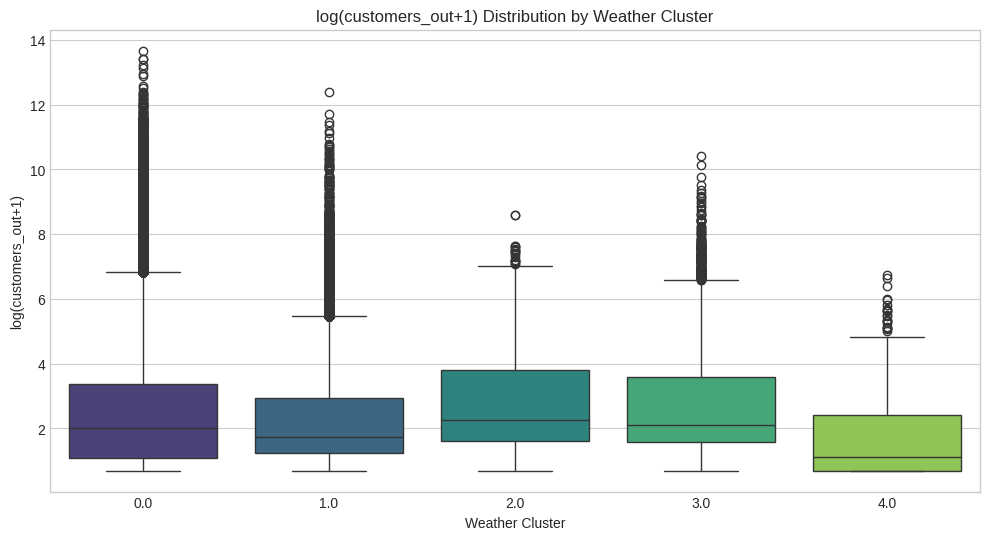

In [33]:
# 2. Weather Pattern Clustering (using K-Means)
print("Unsupervised Learning: Weather Pattern Clustering (Exploratory)")
print("Applying K-Means to identify common daily weather patterns...")

# Select numerical weather features for clustering
features_for_clustering = ['tavg', 'prcp', 'snow', 'wspd']
# Filter out columns that might not exist
features_for_clustering = [f for f in features_for_clustering if f in df.columns]

if len(features_for_clustering) > 1:
    data_for_clustering = df[features_for_clustering].dropna()

    if not data_for_clustering.empty:
        # Scale features before clustering
        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(data_for_clustering)

        n_clusters = 5 # Try to find 5 common weather patterns
        print(f"Running K-Means with k={n_clusters}...")

        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init suppresses warning
        cluster_labels = kmeans.fit_predict(data_scaled)

        # Add cluster labels back to the original DataFrame
        df.loc[data_for_clustering.index, 'weather_cluster'] = cluster_labels

        print("\nAnalyzing Outages per Weather Cluster:")
        # Ensure target variable is numeric for aggregation
        if pd.api.types.is_numeric_dtype(df['log_customers_out']):
           cluster_outage_summary = df.groupby('weather_cluster')['log_customers_out'].agg(['mean', 'median', 'count', 'std'])
           print(cluster_outage_summary.sort_values('mean', ascending=False))
        else:
           print("Target variable ('log_customers_out') is not numeric. Cannot calculate summary statistics.")


        # Characterize the clusters by looking at the mean weather values in each
        cluster_centers_scaled = kmeans.cluster_centers_
        # Inverse transform to get original scale centers
        cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)
        cluster_centers_df = pd.DataFrame(cluster_centers_original, columns=features_for_clustering)
        print("\nCluster Centers (Mean Weather Values for Each Cluster):")
        print(cluster_centers_df)

        # Visualize outage distribution per cluster
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=df.dropna(subset=['weather_cluster']), x='weather_cluster', y='log_customers_out', palette='viridis')
        plt.title(f'log({target_col}+1) Distribution by Weather Cluster')
        plt.xlabel('Weather Cluster')
        plt.ylabel(f'log({target_col}+1)')
        plt.show()

    else:
        print("Skipping clustering: No data available after handling NaNs for selected features.")
else:
     print(f"Skipping clustering: Need at least 2 features from {features_for_clustering}.")

---
## Addditional EDA
---

---
## 1. Deeper Dive: Weather -> Target Relationships
---


Visualizing interaction effects (example: wspd vs outages, colored by prcp)...


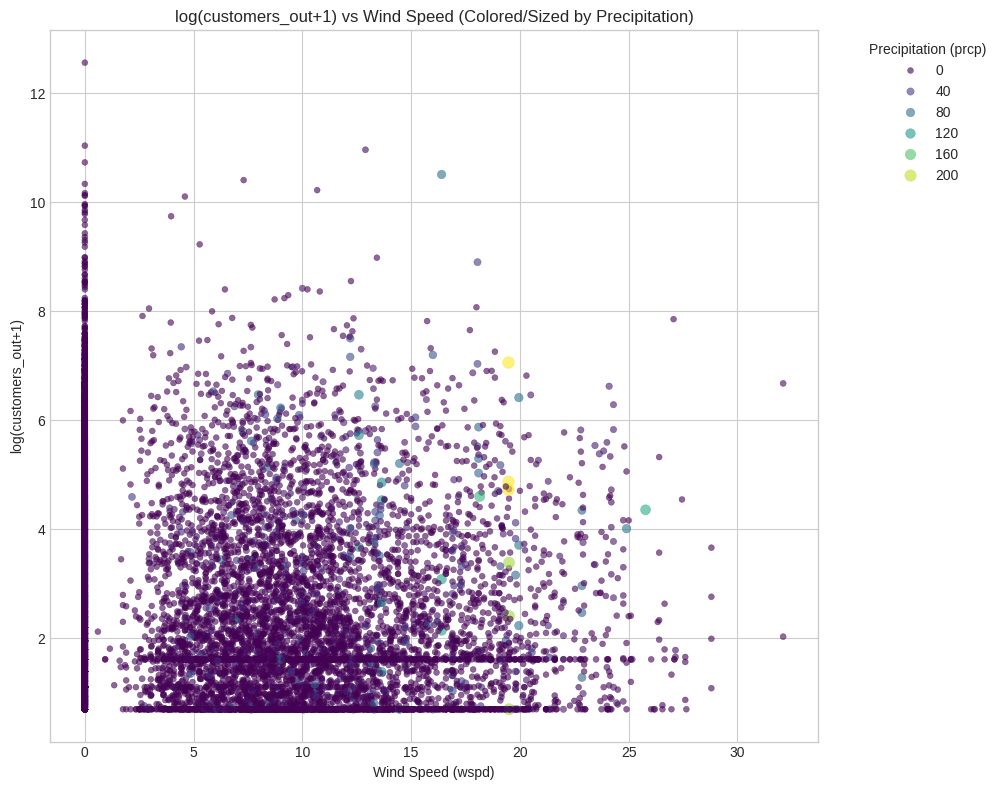

In [34]:
print("\nVisualizing interaction effects (example: wspd vs outages, colored by prcp)...")

# Use a sample for performance, the dataset is large
df_sample = df.sample(min(50000, len(df)), random_state=42) if len(df) > 50000 else df.copy()

if 'wspd' in df.columns and 'prcp' in df.columns:
    plt.figure(figsize=(12, 8))
    scatter = sns.scatterplot(
        data=df_sample,
        x='wspd',
        y=log_target_col,
        hue='prcp',  # Color by precipitation
        size='prcp', # Size by precipitation (optional, can be noisy)
        palette='viridis',
        alpha=0.6,
        edgecolor=None # Cleaner look
    )
    plt.title(f'log({target_col}+1) vs Wind Speed (Colored/Sized by Precipitation)')
    plt.xlabel('Wind Speed (wspd)')
    plt.ylabel(f'log({target_col}+1)')
    # Improve legend if using size
    h, l = scatter.get_legend_handles_labels()
    # Keep only a few representative legend items for hue/size if too many
    plt.legend(h[::len(h)//8+1], l[::len(l)//8+1], title='Precipitation (prcp)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout for legend
    plt.show()
else:
    print("Skipping interaction plot: 'wspd' or 'prcp' column not found.")

1. Deeper Weather -> Target Analysis 

Analyzing target variable statistics across weather variable bins...

--- Analyzing by tavg bins ---
         bin_range  mean_outages  median_outages  outage_frequency  \
0  (-33.15 - 0.00]     82.012863        6.000000               1.0   
1   (0.00 - 12.20]     71.608383        4.923077               1.0   
2  (12.20 - 21.53]     74.206947        6.000000               1.0   
3  (21.54 - 45.30]     92.249016        6.833333               1.0   

   record_count  
0       1521290  
1        738686  
2        751390  
3        752383  


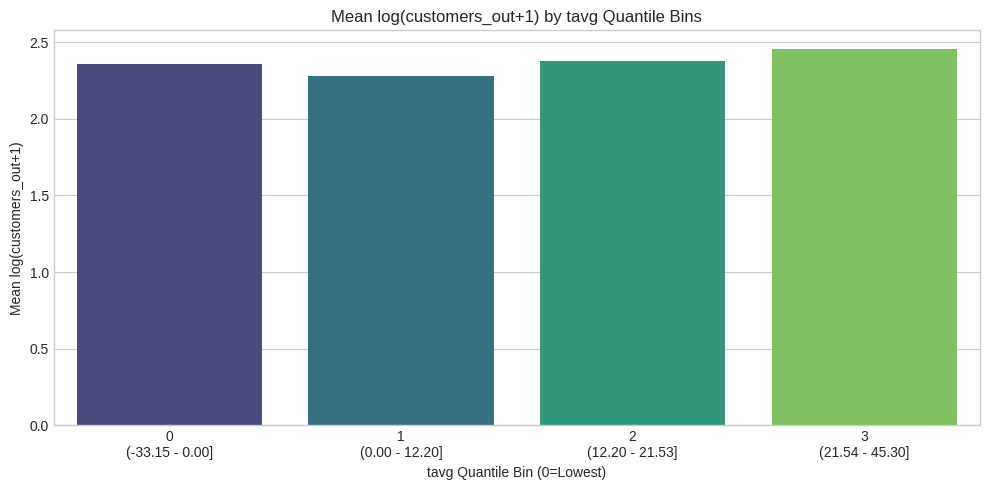

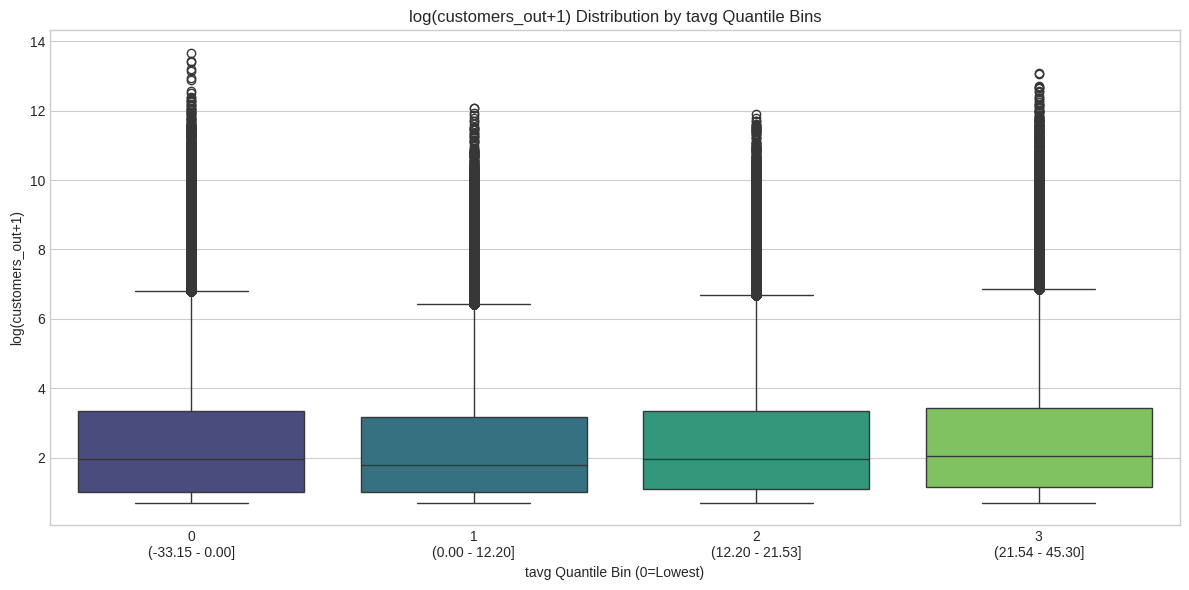


--- Analyzing by tmin bins ---
         bin_range  mean_outages  median_outages  outage_frequency  \
0  (-67.00 - 0.00]     80.913902        5.758621               1.0   
1    (0.00 - 6.30]     74.342155        5.000000               1.0   
2   (6.30 - 16.14]     71.714561        5.862069               1.0   
3  (16.14 - 41.00]     91.874153        7.000000               1.0   

   record_count  
0       1795845  
1        463923  
2        751426  
3        752555  


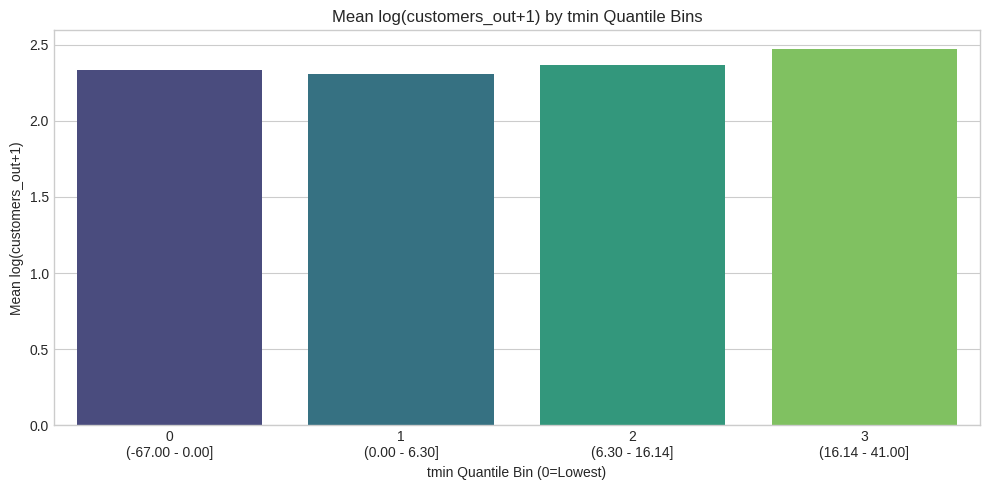

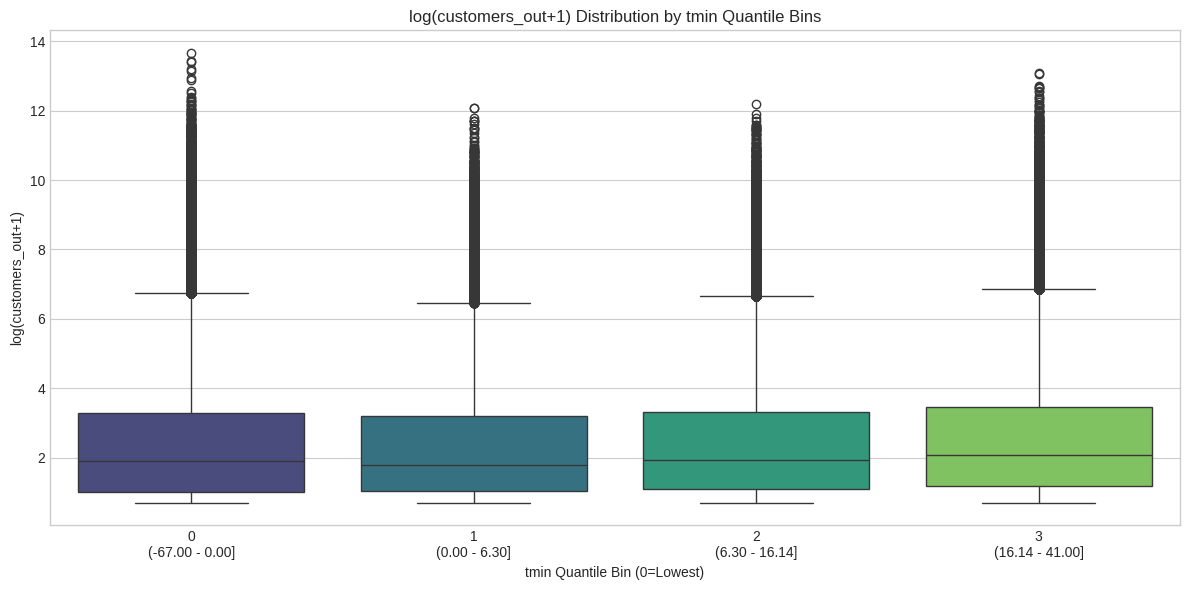


--- Analyzing by tmax bins ---
         bin_range  mean_outages  median_outages  outage_frequency  \
0  (-29.00 - 0.00]     84.301994        6.181818               1.0   
1    (0.00 - 3.15]     74.268745        4.166667               1.0   
2   (3.16 - 18.19]     73.920715        5.000000               1.0   
3  (18.20 - 27.36]     73.508080        5.967213               1.0   
4  (27.36 - 87.00]     87.532578        6.500000               1.0   

   record_count  
0       1410159  
1         95539  
2        752602  
3        752760  
4        752689  


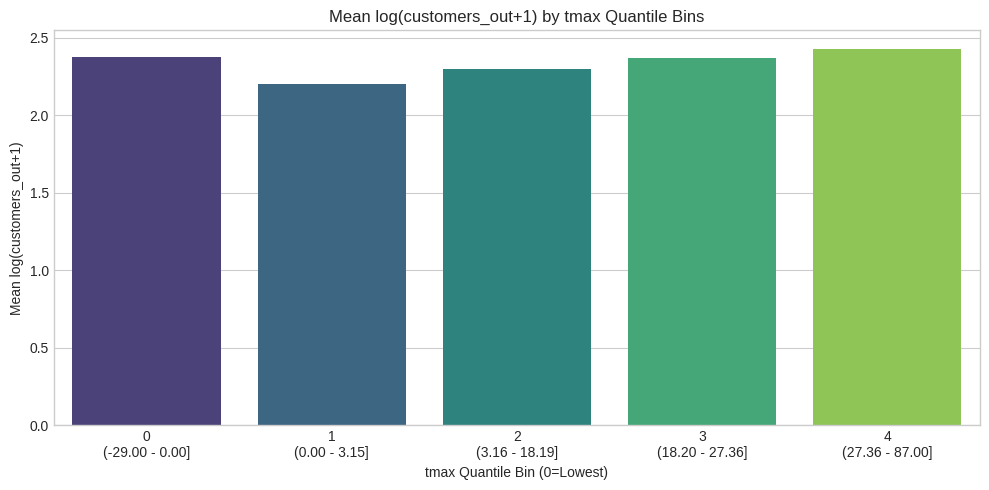

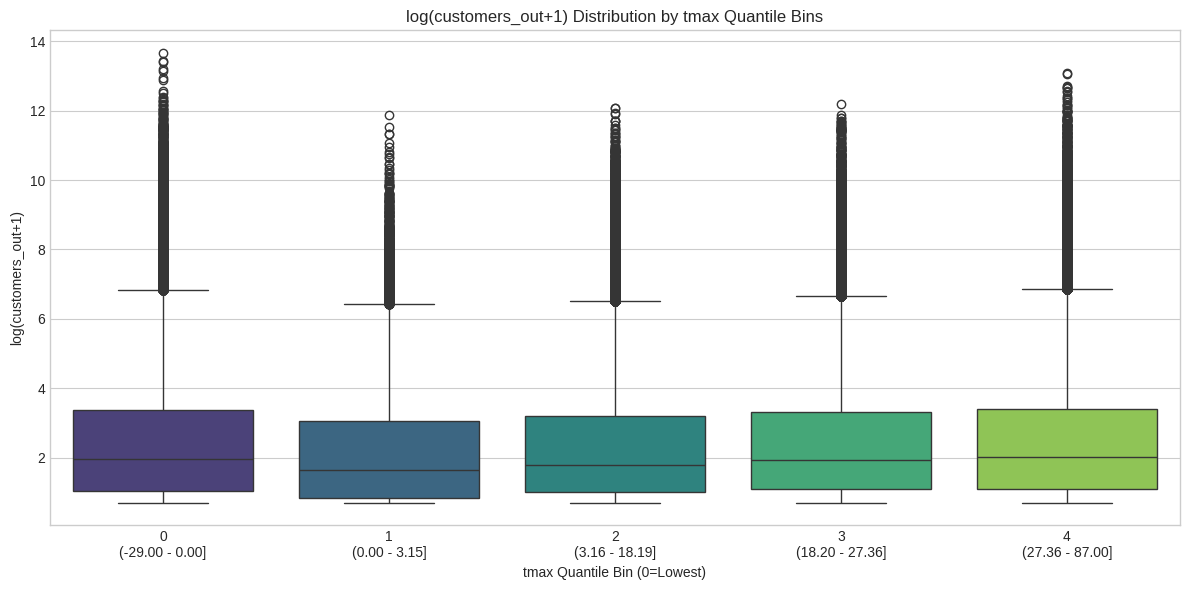


--- Analyzing by prcp bins ---
         bin_range  mean_outages  median_outages  outage_frequency  \
0  (0.00 - 221.10]     84.781036        6.083333               1.0   

   record_count  
0       1800019  


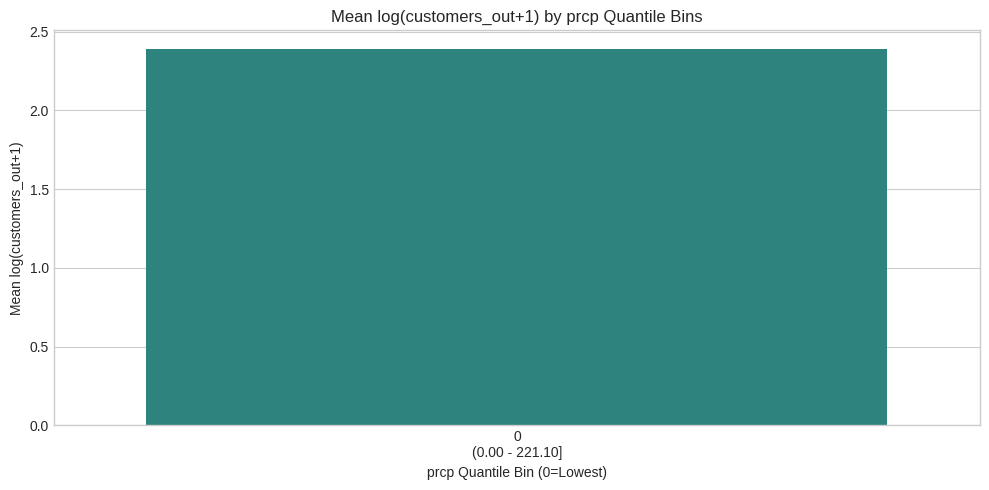

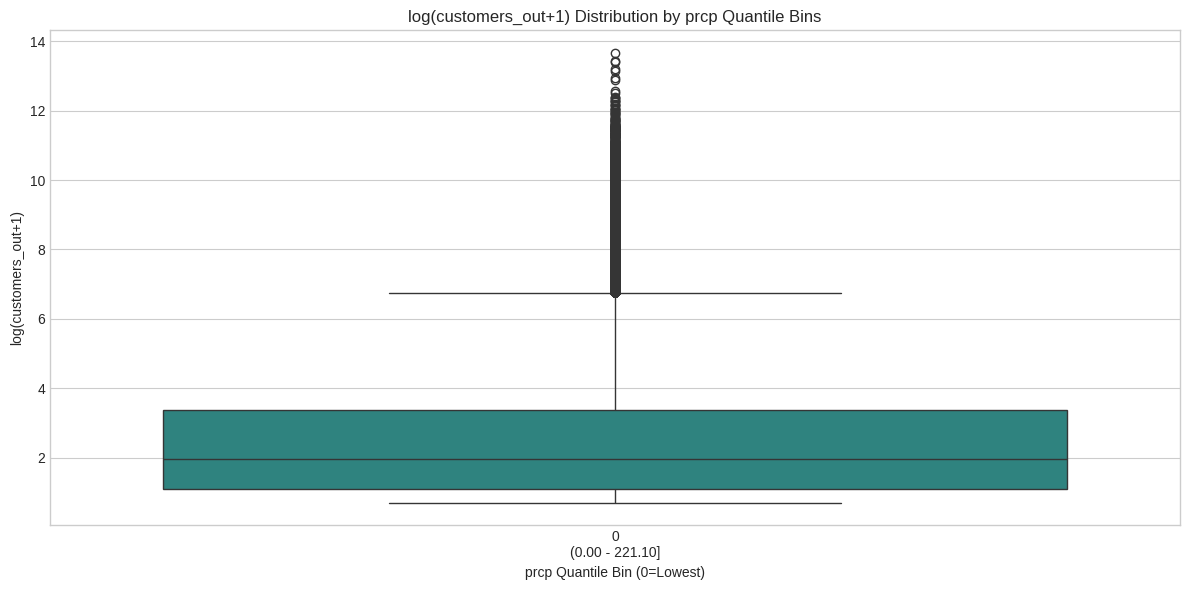


--- Analyzing by snow bins ---
         bin_range  mean_outages  median_outages  outage_frequency  \
0  (0.00 - 178.00]     80.789291           6.125               1.0   

   record_count  
0       1512755  


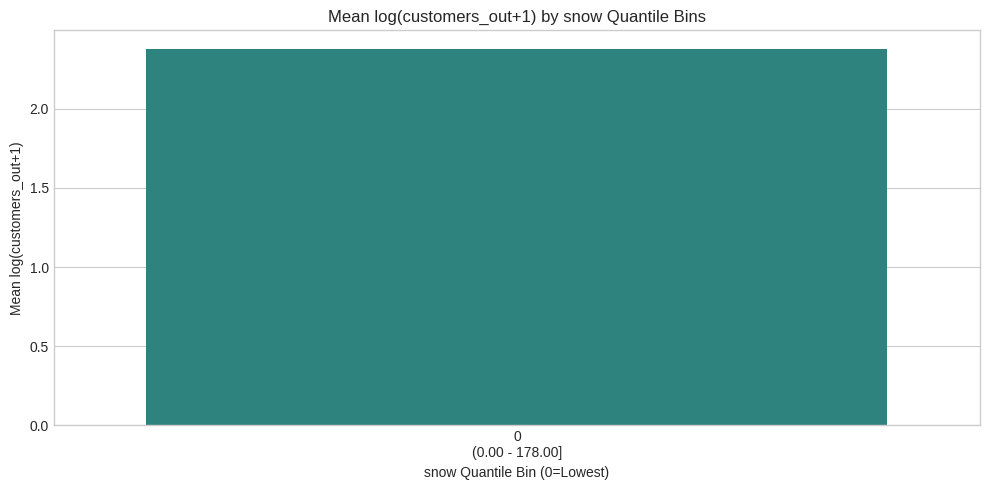

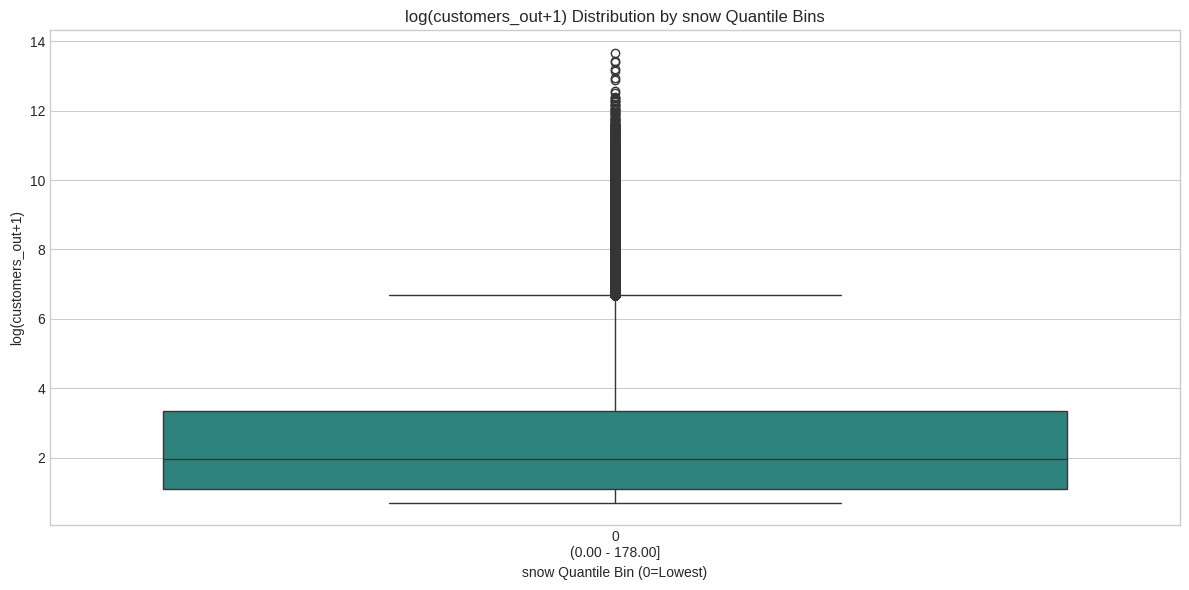


--- Analyzing by wspd bins ---
         bin_range  mean_outages  median_outages  outage_frequency  \
0    (0.00 - 3.20]     82.996811        6.333333               1.0   
1    (3.21 - 7.75]     72.537636        5.555555               1.0   
2   (7.76 - 12.40]     76.435051        5.662250               1.0   
3  (12.40 - 64.80]     86.262886        5.777778               1.0   

   record_count  
0       1439163  
1        717969  
2        720212  
3        715075  


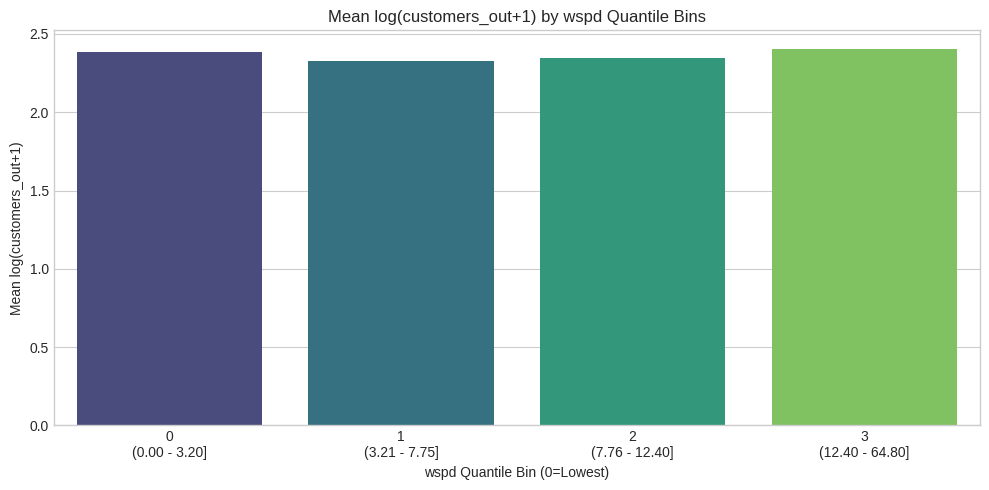

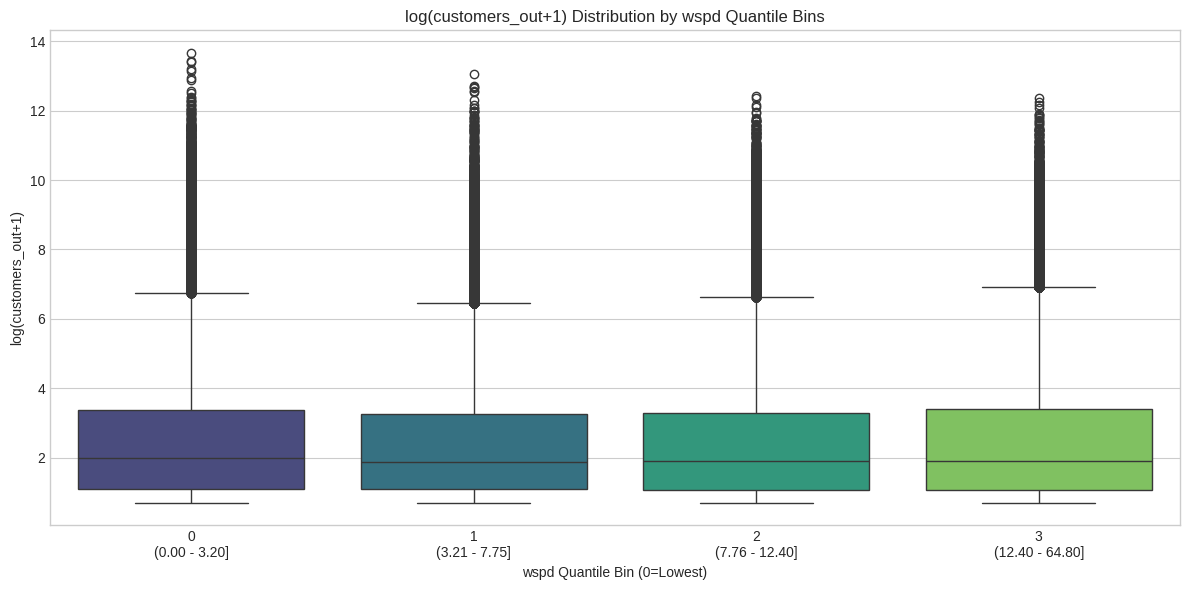

In [35]:
print("1. Deeper Weather -> Target Analysis ")

# Binning Weather Variables and Analyzing Target Statistics per Bin
print("\nAnalyzing target variable statistics across weather variable bins...")
n_bins = 5 # Number of bins for weather variables

for col in weather_num_cols:
    print(f"\n--- Analyzing by {col} bins ---")
    try:
        # Create bins using quantiles for potentially better distribution
        df[f'{col}_bin'] = pd.qcut(df[col], q=n_bins, labels=False, duplicates='drop')

        # Calculate statistics per bin
        bin_stats = df.groupby(f'{col}_bin').agg(
            mean_outages=(target_col, 'mean'),
            median_outages=(target_col, 'median'),
            mean_log_outages=(log_target_col, 'mean'),
            median_log_outages=(log_target_col, 'median'),
            outage_frequency=(target_col, lambda x: (x > 0).mean()), # Proportion of days with outages
            record_count=(target_col, 'count')
        ).reset_index()

        # Get approximate range for each bin label
        bin_ranges = df.groupby(f'{col}_bin')[col].agg(['min', 'max'])
        bin_stats = bin_stats.merge(bin_ranges, left_on=f'{col}_bin', right_index=True)
        bin_stats['bin_range'] = bin_stats.apply(lambda row: f"({row['min']:.2f} - {row['max']:.2f}]", axis=1)

        print(bin_stats[['bin_range', 'mean_outages', 'median_outages', 'outage_frequency', 'record_count']])

        # Visualize
        plt.figure(figsize=(10, 5))
        sns.barplot(data=bin_stats, x=f'{col}_bin', y='mean_log_outages', palette='viridis')
        plt.title(f'Mean log({target_col}+1) by {col} Quantile Bins')
        plt.xlabel(f'{col} Quantile Bin (0=Lowest)')
        plt.ylabel(f'Mean log({target_col}+1)')
        # Add text labels for ranges
        plt.xticks(ticks=bin_stats.index, labels=[f"{idx}\n{rng}" for idx, rng in zip(bin_stats.index, bin_stats['bin_range'])], rotation=0, ha='center')
        plt.tight_layout()
        plt.show()

        # Visualize distribution within bins (Box Plot)
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=df.dropna(subset=[f'{col}_bin']), x=f'{col}_bin', y=log_target_col, palette='viridis')
        plt.title(f'log({target_col}+1) Distribution by {col} Quantile Bins')
        plt.xlabel(f'{col} Quantile Bin (0=Lowest)')
        plt.ylabel(f'log({target_col}+1)')
        plt.xticks(ticks=bin_stats.index, labels=[f"{idx}\n{rng}" for idx, rng in zip(bin_stats.index, bin_stats['bin_range'])], rotation=0, ha='center')
        plt.tight_layout()
        plt.show()


        # Clean up bin column
        del df[f'{col}_bin']

    except Exception as e:
        print(f"Could not analyze bins for {col}: {e}")
        if f'{col}_bin' in df.columns: del df[f'{col}_bin']

---
## 5. Deeper Time Series Analysis (Multivariate Focus)
---

5. Deeper Time Series Analysis
Setting 'time' column as index for time series analysis.
Aggregating target variable daily across all counties...

Plotting ACF and PACF for aggregated daily 'log_customers_out'...


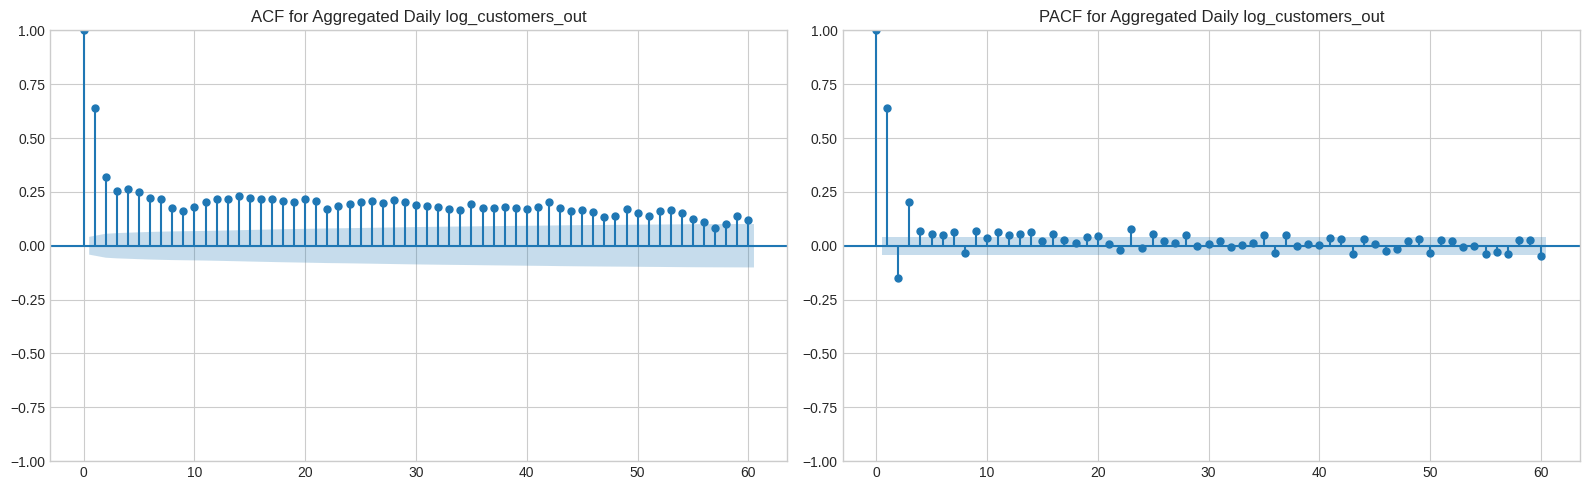

These plots confirm the autocorrelation structure of outages themselves.

Analyzing Cross-Correlation between aggregated outages and weather...
Calculating CCF for log_customers_out vs wspd...


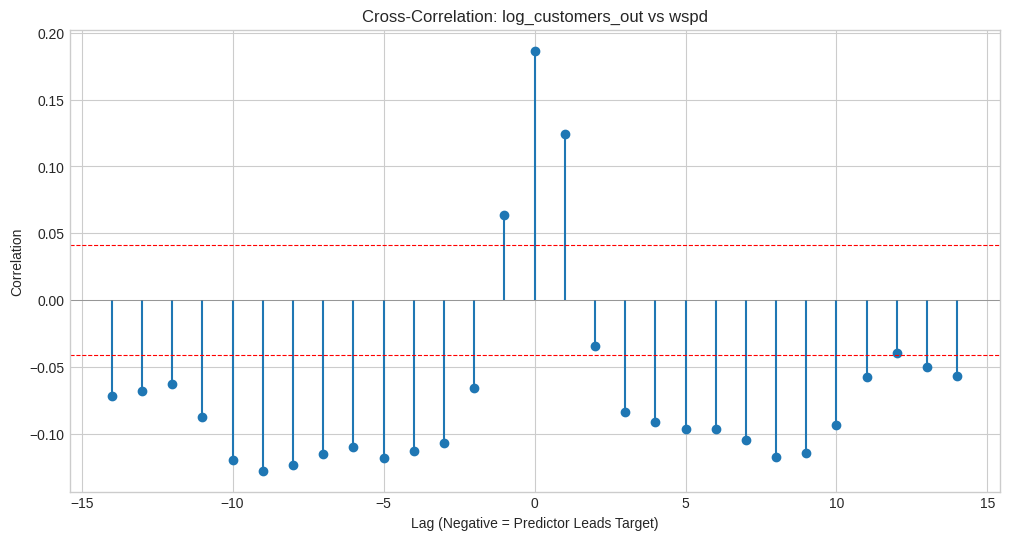

CCF shows correlation strength at different leads/lags for wspd.
Calculating CCF for log_customers_out vs prcp...


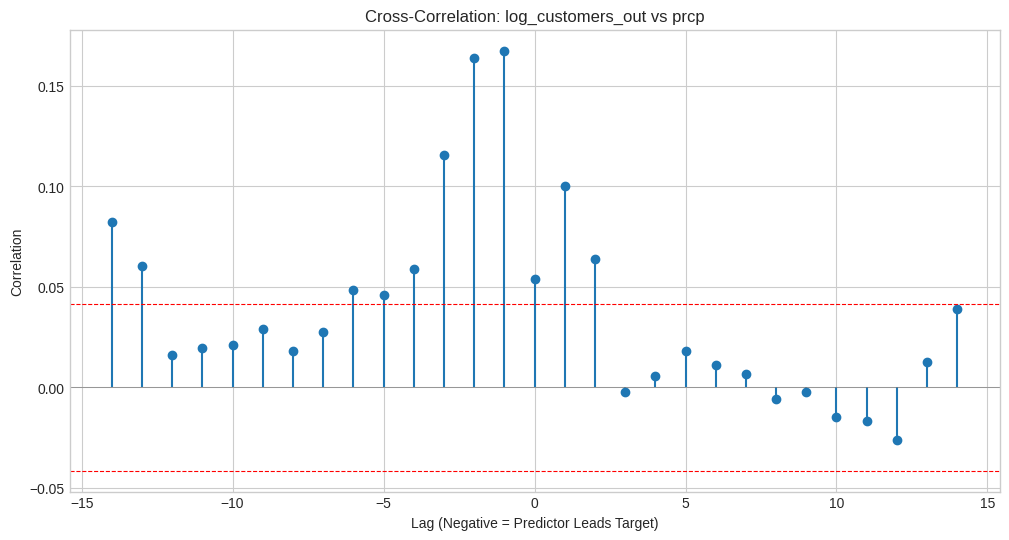

CCF shows correlation strength at different leads/lags for prcp.
Calculating CCF for log_customers_out vs tmax...


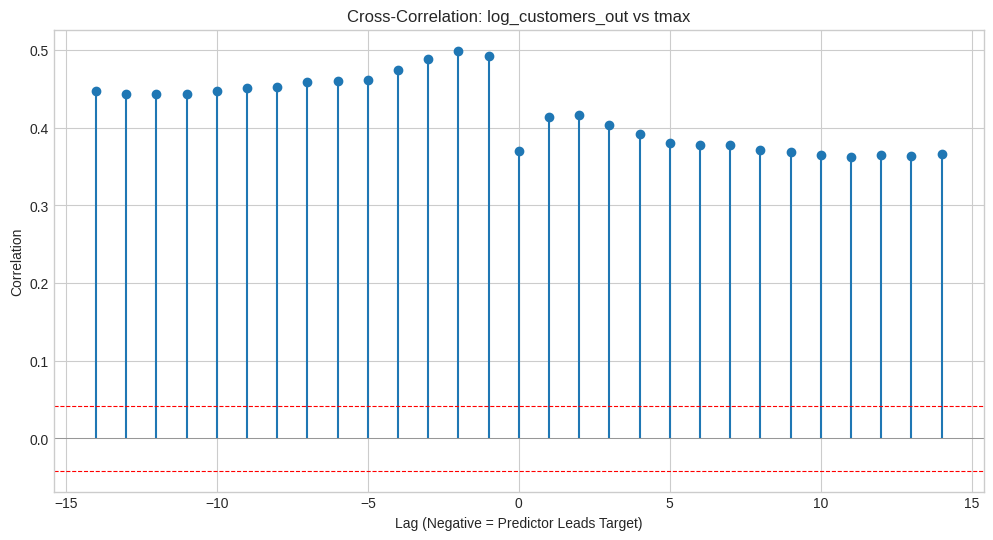

CCF shows correlation strength at different leads/lags for tmax.


In [36]:
print("5. Deeper Time Series Analysis")

# Ensure df has a datetime index for easier time series operations
if not isinstance(df.index, pd.DatetimeIndex):
    if 'time' in df.columns:
        print("Setting 'time' column as index for time series analysis.")
        df = df.set_index('time').sort_index()
    else:
        print("Warning: No 'time' column or datetime index found. Time series analysis will be limited.")

# Summing customers_out per day
if isinstance(df.index, pd.DatetimeIndex):
    print("Aggregating target variable daily across all counties...")
    # Ensure log_target_col exists before grouping
    cols_to_agg = [target_col]
    if log_target_col in df.columns:
        cols_to_agg.append(log_target_col)
    else:
         print(f"Warning: '{log_target_col}' not found, using only '{target_col}'.")

    # Handle potential non-numeric types before aggregation
    for col in cols_to_agg:
        if not pd.api.types.is_numeric_dtype(df[col]):
             print(f"Warning: Column '{col}' is not numeric, attempting conversion.")
             df[col] = pd.to_numeric(df[col], errors='coerce')


    daily_agg = df.groupby(df.index)[log_target_col].mean().dropna() # Mean of log is often more stable

    # Re-plot ACF/PACF for the aggregated target variable (focus on log target)
    if not daily_agg.empty:
        print(f"\nPlotting ACF and PACF for aggregated daily '{log_target_col}'...")
        lags = min(60, len(daily_agg)//2 - 1)
        if lags > 1:
            fig, ax = plt.subplots(1, 2, figsize=(16, 5))
            plot_acf(daily_agg, lags=lags, ax=ax[0])
            ax[0].set_title(f'ACF for Aggregated Daily {log_target_col}')
            plot_pacf(daily_agg, lags=lags, ax=ax[1])
            ax[1].set_title(f'PACF for Aggregated Daily {log_target_col}')
            plt.tight_layout()
            plt.show()
            print("These plots confirm the autocorrelation structure of outages themselves.")
        else:
            print("Skipping ACF/PACF: Not enough data points in aggregated series.")

        # **Multivariate Context: Cross-Correlation**
        # Analyze correlation between aggregated target and aggregated predictors
        print("\nAnalyzing Cross-Correlation between aggregated outages and weather...")
        predictors_for_ccf = ['wspd', 'prcp', 'tmax'] # Example predictors
        predictors_for_ccf = [p for p in predictors_for_ccf if p in df.columns]

        if predictors_for_ccf:
            # Aggregate predictors daily (e.g., mean)
            daily_predictors = df.groupby(df.index)[predictors_for_ccf].mean()
            aligned_target, aligned_predictors = daily_agg.align(daily_predictors, join='inner')
            aligned_target = aligned_target.fillna(0) # Or interpolate
            aligned_predictors = aligned_predictors.fillna(method='ffill').fillna(0) # Ffill then 0

            max_lag_ccf = 14 # Lags/leads to check

            if len(aligned_target) > max_lag_ccf * 2:
                for predictor in predictors_for_ccf:
                    print(f"Calculating CCF for {log_target_col} vs {predictor}...")
                    ccf_values = ccf(aligned_target, aligned_predictors[predictor], adjusted=False) # Using statsmodels ccf

                    # Extract relevant lags/leads (-max_lag to +max_lag) centered around 0
                    # statsmodels ccf output: ccf[0] is lag 0, ccf[1] is lag 1 (target vs predictor(t-1))
                    # We need to map this to conventional plots showing leads and lags.
                    lags_range = np.arange(-max_lag_ccf, max_lag_ccf + 1)
                    # Manually compute correlations for negative lags (leads)
                    ccf_symmetric = []
                    for lag in lags_range:
                        # Positive lag k: corr(target(t), predictor(t-k)) -> use ccf[k]
                        # Negative lag -k (lead k): corr(target(t), predictor(t+k)) == corr(target(t-k), predictor(t))
                        # This requires shifting the target *backwards* (or predictor forwards)
                        if lag >= 0:
                            ccf_symmetric.append(ccf_values[lag])
                        else:
                            # Calculate corr(target(t - abs(lag)), predictor(t))
                            #corr_lead, _ = spearmanr(aligned_target.shift(lag).dropna(), aligned_predictors[predictor].dropna())

                            # Align the shifted target with the predictor to ensure they have the same length
                            temp_target_shifted = aligned_target.shift(lag)
                            # Fix: Reindex temp_target_shifted to match aligned_predictors[predictor]'s index
                            temp_target_shifted = temp_target_shifted.reindex(aligned_predictors[predictor].index)

                            # Handle cases with insufficient data after alignment
                            valid_data = pd.concat([temp_target_shifted, aligned_predictors[predictor]], axis=1).dropna()
                            if len(valid_data) < 2:
                                corr_lead = np.nan
                            else:
                                # Calculate Spearman's correlation for the aligned series
                                corr_lead, _ = spearmanr(valid_data.iloc[:, 0], valid_data.iloc[:, 1])
                            ccf_symmetric.append(corr_lead)


                    plt.figure(figsize=(12, 6))
                    plt.stem(lags_range, ccf_symmetric, basefmt=" ") # Stem plot better for CCF
                    plt.axhline(0, color='grey', lw=0.5)
                    # Add confidence bounds (approximate)
                    conf_level = 1.96 / np.sqrt(len(aligned_target))
                    plt.axhline(conf_level, color='red', linestyle='--', lw=0.8)
                    plt.axhline(-conf_level, color='red', linestyle='--', lw=0.8)
                    plt.title(f'Cross-Correlation: {log_target_col} vs {predictor}')
                    plt.xlabel('Lag (Negative = Predictor Leads Target)')
                    plt.ylabel('Correlation')
                    plt.grid(True, axis='x')
                    plt.show()
                    print(f"CCF shows correlation strength at different leads/lags for {predictor}.")
            else:
                print("Skipping CCF plots: Not enough aligned data points.")
        else:
            print("Skipping CCF analysis: No suitable predictor columns found.")

    else:
        print("Skipping time series analysis: Aggregated daily target is empty.")
else:
    print("Skipping time series analysis: DataFrame does not have a DatetimeIndex.")

---
## 6. Past vs. Future Outages & Lead/Lag Features
---

In [37]:
import random

use_sampling = True
sampling_method = 'county'
sample_frac = 0.1
n_counties_sample = 10
random_seed = 42
max_lag_N = 14
max_lead_L = 14
group_col = 'fips_code'

print(f"Analyzing {max_lag_N} past days predicting {max_lead_L} future days.")

if use_sampling:
    print(f"\n--- Applying Sampling (Method: {sampling_method}) ---")
    original_shape = df.shape
    random.seed(random_seed)
    np.random.seed(random_seed)

    if sampling_method == 'fraction':
        print(f"Sampling {sample_frac * 100:.1f}% of rows randomly...")
        df_sampled = df.sample(frac=sample_frac, random_state=random_seed)
        print(f"Sampled DataFrame shape: {df_sampled.shape}")

    elif sampling_method == 'county':
        all_counties = df[group_col].unique()
        if n_counties_sample >= len(all_counties):
            print("Warning: n_counties_sample >= total unique counties. Using all counties.")
            df_sampled = df.copy()
        else:
            print(f"Sampling data for {n_counties_sample} random counties...")
            selected_counties = random.sample(list(all_counties), n_counties_sample)
            df_sampled = df[df[group_col].isin(selected_counties)].copy() # Use .copy() to avoid SettingWithCopyWarning later
            print(f"Selected {len(selected_counties)} counties.")
            print(f"Sampled DataFrame shape: {df_sampled.shape}")
            print(f"Sampled Time Range: {df_sampled.index.min()} to {df_sampled.index.max()}")

    else:
        raise ValueError("Invalid sampling_method. Choose 'fraction' or 'county'.")

    df_analysis  = df_sampled
    del df_sampled
    gc.collect()

else:
    print("\n--- Running analysis on the FULL dataset (no sampling) ---")
    df_analysis  = df.copy()

Analyzing 14 past days predicting 14 future days.

--- Applying Sampling (Method: county) ---
Sampling data for 10 random counties...
Selected 10 counties.
Sampled DataFrame shape: (14529, 80)
Sampled Time Range: 2014-11-01 00:00:00 to 2020-12-31 00:00:00


6. Past vs. Future Outages & Lead/Lag Features 

Creating lead features for target variables (up to 14 days ahead)...
Created lead columns: ['customers_out_lead1', 'customers_out_lead2', 'customers_out_lead3', 'customers_out_lead4', 'customers_out_lead5', 'customers_out_lead6', 'customers_out_lead7', 'customers_out_lead8', 'customers_out_lead9', 'customers_out_lead10', 'customers_out_lead11', 'customers_out_lead12', 'customers_out_lead13', 'customers_out_lead14', 'log_customers_out_lead1', 'log_customers_out_lead2', 'log_customers_out_lead3', 'log_customers_out_lead4', 'log_customers_out_lead5', 'log_customers_out_lead6', 'log_customers_out_lead7', 'log_customers_out_lead8', 'log_customers_out_lead9', 'log_customers_out_lead10', 'log_customers_out_lead11', 'log_customers_out_lead12', 'log_customers_out_lead13', 'log_customers_out_lead14']

Analyzing correlation between current predictors and future outages (up to 14 days)...


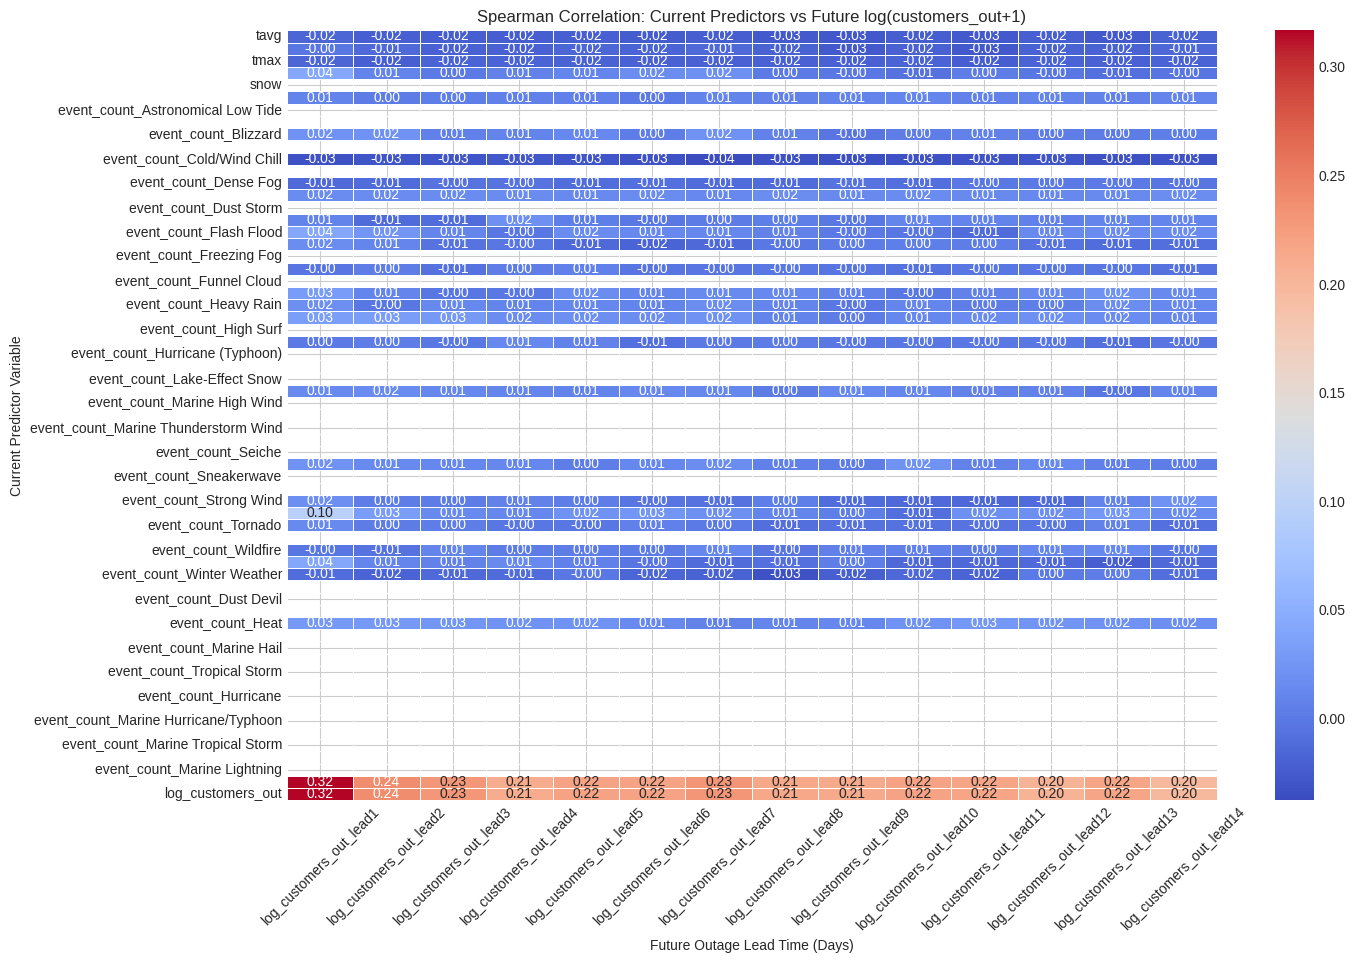

This heatmap shows how well current conditions predict outages 1 to 7 days ahead.

Top 5 Current Predictors Correlated with Future Outages (across leads 1-7):
customers_out                    3.151218
log_customers_out                3.151218
event_count_Cold/Wind Chill      0.448529
event_count_Thunderstorm Wind    0.326513
tavg                             0.324932
dtype: float64


In [38]:
print("6. Past vs. Future Outages & Lead/Lag Features ")

# We already examined ACF/PACF for past lags. Let's focus on future lags (leads).

# Create lead features for the target variable (future outages)
max_lead = 14 # days into the future
lead_target_cols = []
print(f"\nCreating lead features for target variables (up to {max_lead} days ahead)...")
target_vars_for_lead = [target_col, log_target_col]
if severity_col in df.columns:
    # Lagging categorical needs care For now, just lag numeric.
    pass

# Need to group by county before shifting to avoid data leakage across counties
# Store original index if it's time
original_index = df_analysis .index if isinstance(df_analysis .index, pd.DatetimeIndex) else None
df_reset = df_analysis .reset_index() # Work with temp df with standard index

# Create lead columns grouped by county
for col in target_vars_for_lead:
    if col in df_reset.columns:
        for k in range(1, max_lead + 1):
            lead_col_name = f'{col}_lead{k}'
            df_reset[lead_col_name] = df_reset.groupby('fips_code')[col].shift(-k) # Negative shift for lead
            lead_target_cols.append(lead_col_name)

# Restore index if it was datetime
if original_index is not None and 'time' in df_reset.columns:
     df_analysis  = df_reset.set_index('time').sort_index()
else:
     df_analysis  = df_reset # Keep modified df if no time index originally

print(f"Created lead columns: {lead_target_cols}")

# Analyze correlation between CURRENT predictors and FUTURE outages
print(f"\nAnalyzing correlation between current predictors and future outages (up to {max_lead} days)...")
predictors_current = weather_num_cols + event_cols + [target_col, log_target_col] # Include current outage value
predictors_current = [p for p in predictors_current if p in df.columns]

if lead_target_cols and predictors_current:
    # Select relevant columns and drop NaNs for correlation
    cols_for_lead_corr = predictors_current + lead_target_cols
    corr_df = df_analysis [cols_for_lead_corr].dropna(subset=lead_target_cols) # Drop rows where future is unknown

    if not corr_df.empty:
        lead_correlation_matrix = corr_df.corr(method='spearman')

        # Focus on correlation between current predictors and future log_target
        future_log_target_cols = [c for c in lead_target_cols if log_target_col in c]
        predictor_vs_future_corr = lead_correlation_matrix.loc[predictors_current, future_log_target_cols]

        plt.figure(figsize=(15, 10))
        sns.heatmap(predictor_vs_future_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=True)
        plt.title(f'Spearman Correlation: Current Predictors vs Future log({target_col}+1)')
        plt.xlabel('Future Outage Lead Time (Days)')
        plt.ylabel('Current Predictor Variable')
        plt.yticks(rotation=0)
        plt.xticks(rotation=45)
        plt.show()

        print("This heatmap shows how well current conditions predict outages 1 to 7 days ahead.")
        # Highlight predictors strongly correlated with future outages
        abs_corr_sum = predictor_vs_future_corr.abs().sum(axis=1).sort_values(ascending=False)
        print("\nTop 5 Current Predictors Correlated with Future Outages (across leads 1-7):")
        print(abs_corr_sum.head())

    else:
        print("Skipping lead correlation: No data available after handling NaNs from shifts.")
else:
    print("Skipping lead correlation: Lead target columns or predictor columns not available.")

---
## 7. IN DEPTH Past vs. Future Outages & Lead/Lag Features
---

In [39]:
def create_grouped_lags_leads(df, group_col, cols_to_shift, shift_range, shift_type='lag'):
    """
    Creates lag or lead features for specified columns, grouped by group_col.

    Args:
        df (pd.DataFrame): Input DataFrame.
        group_col (str): Column name to group by.
        cols_to_shift (list): List of column names to create lags/leads for.
        shift_range (range): Range of shifts (e.g., range(1, N+1) for lags).
        shift_type (str): 'lag' or 'lead'.

    Returns:
        pd.DataFrame: DataFrame with new lag/lead columns added.
    """
    df_out = df.copy()
    op_name = shift_type.capitalize()
    shift_sign = 1 if shift_type == 'lag' else -1

    # Ensure group_col is not in cols_to_shift
    cols_to_shift = [c for c in cols_to_shift if c != group_col]

    print(f"Creating {op_name} features for: {cols_to_shift}")
    with tqdm(total=len(cols_to_shift) * len(shift_range), desc=f"Creating {op_name}s") as pbar:
        for col in cols_to_shift:
            if col not in df.columns:
                print(f"Warning: Column '{col}' not found in DataFrame. Skipping.")
                pbar.update(len(shift_range))
                continue
            for k in shift_range:
                new_col_name = f'{col}_{shift_type}{k}'
                # Group by county, shift, and assign back (aligns index automatically)
                df_out[new_col_name] = df_out.groupby(group_col)[col].shift(k * shift_sign)
                pbar.update(1)
            gc.collect()

    return df_out

## Scenario 1: Analysis WITHOUT Storm Events
Predictors: Lagged Weather + Lagged Outages

Scenario 1: WITHOUT Storm Events
Creating lag/lead features for Scenario 1...
Creating Lag features for: ['tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wspd', 'customers_out']


Creating Lags:   0%|          | 0/98 [00:00<?, ?it/s]

Creating Lead features for: ['customers_out']


Creating Leads:   0%|          | 0/14 [00:00<?, ?it/s]

Number of lag features (including lag 0): 105
Number of lead features: 14
Calculating Spearman correlations between 105 lags and 14 leads...
Shape of data for correlation after dropping NaN leads: (14398, 119)
Correlation calculation successful.

Plotting correlation decay for key past features...


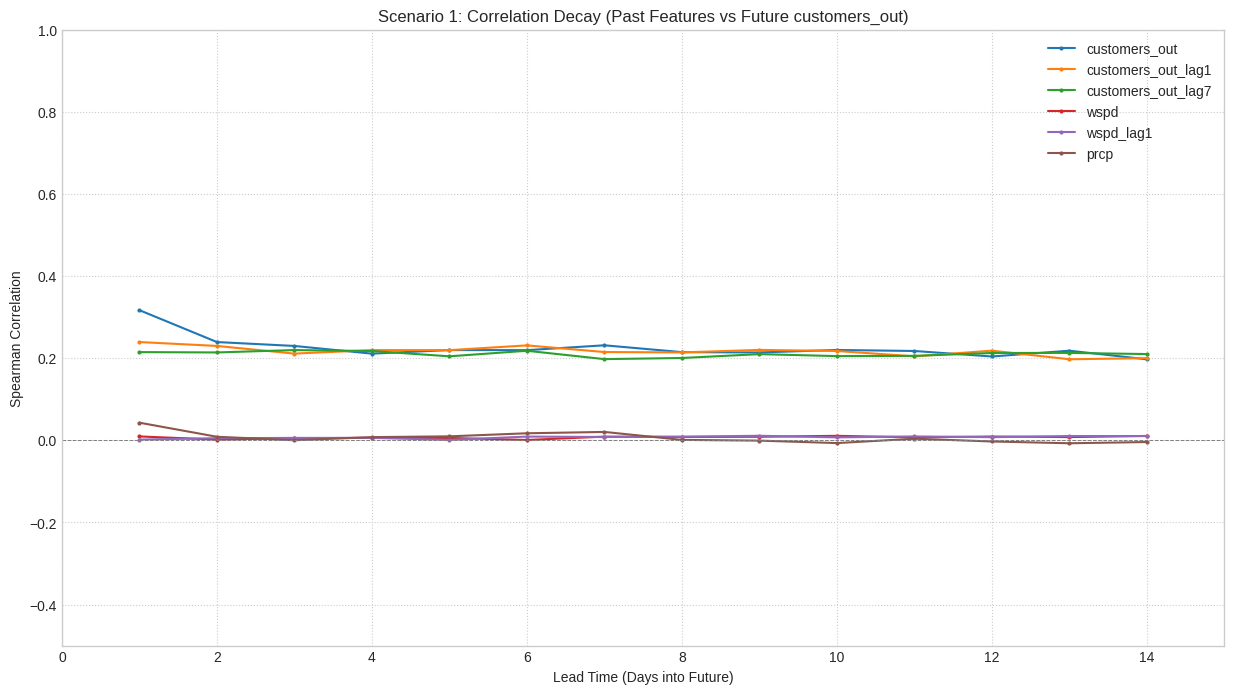


Calculating average absolute correlation across the future horizon...

Top 15 Past Features by Average Absolute Correlation with Future customers_out (Leads 1-14):
customers_out          0.225087
customers_out_lag1     0.216809
customers_out_lag2     0.214644
customers_out_lag3     0.212922
customers_out_lag4     0.212452
customers_out_lag5     0.212043
customers_out_lag6     0.211562
customers_out_lag7     0.210037
customers_out_lag8     0.209530
customers_out_lag9     0.208755
customers_out_lag10    0.208098
customers_out_lag11    0.206737
customers_out_lag12    0.206659
customers_out_lag14    0.206239
customers_out_lag13    0.205163
dtype: float64

Bottom 10 Past Features by Average Absolute Correlation:
snow_lag5    NaN
snow_lag6    NaN
snow_lag7    NaN
snow_lag8    NaN
snow_lag9    NaN
snow_lag10   NaN
snow_lag11   NaN
snow_lag12   NaN
snow_lag13   NaN
snow_lag14   NaN
dtype: float64

Cleaned up Scenario 1 data.


In [40]:
print("Scenario 1: WITHOUT Storm Events")

lag_features_s1 = weather_num_cols + [target_col]
lead_features_s1 = [target_col] # Only need leads for the target

print("Creating lag/lead features for Scenario 1...")
df_s1 = df_analysis .copy() # Work on a copy for this scenario
df_s1 = create_grouped_lags_leads(df_s1, group_col, lag_features_s1, range(1, max_lag_N + 1), 'lag')
df_s1 = create_grouped_lags_leads(df_s1, group_col, lead_features_s1, range(1, max_lead_L + 1), 'lead')
gc.collect()

# Get lists of generated lag and lead column names
lag_col_names_s1 = [f'{col}_lag{k}' for col in lag_features_s1 for k in range(1, max_lag_N + 1) if f'{col}_lag{k}' in df_s1.columns]
# Include lag 0 (current value) for predictors
lag0_col_names_s1 = [col for col in lag_features_s1 if col in df_s1.columns] # Use original col name for lag 0
all_lags_s1 = lag0_col_names_s1 + lag_col_names_s1

lead_col_names_s1 = [f'{target_col}_lead{k}' for k in range(1, max_lead_L + 1) if f'{target_col}_lead{k}' in df_s1.columns]

print(f"Number of lag features (including lag 0): {len(all_lags_s1)}")
print(f"Number of lead features: {len(lead_col_names_s1)}")

# Calculate Correlations (Spearman)
# This is slow/memory-intensive
if not all_lags_s1 or not lead_col_names_s1:
    print("Error: No lag or lead columns generated for Scenario 1. Skipping correlation.")
else:
    print(f"Calculating Spearman correlations between {len(all_lags_s1)} lags and {len(lead_col_names_s1)} leads...")
    cols_for_corr_s1 = all_lags_s1 + lead_col_names_s1
    # Drop rows where *any* lead value is NaN, as we can't correlate with the future there.
    # Dropping based on lag NaNs would remove too much initial data. Correlation handles pairwise NaNs.
    df_corr_s1 = df_s1[cols_for_corr_s1].dropna(subset=lead_col_names_s1)
    print(f"Shape of data for correlation after dropping NaN leads: {df_corr_s1.shape}")

    if df_corr_s1.shape[0] < 2:
         print("Error: Not enough non-NaN data points after creating leads. Cannot calculate correlations.")
    else:
        # Calculate full correlation matrix (might need optimization)
        try:
            correlation_matrix_s1 = df_corr_s1.corr(method='spearman')
            # Extract the sub-matrix of interest: Lags vs Leads
            lag_vs_lead_corr_s1 = correlation_matrix_s1.loc[all_lags_s1, lead_col_names_s1]
            print("Correlation calculation successful.")
            corr_calculated_s1 = True
        except Exception as e:
            print(f"Error calculating full correlation matrix: {e}")
            print("Attempting column-wise correlation (slower)...")
            corr_calculated_s1 = False
            lag_vs_lead_corr_s1 = pd.DataFrame(index=all_lags_s1, columns=lead_col_names_s1, dtype=float)
            try:
                for lead_col in tqdm(lead_col_names_s1, desc="Lead Columns"):
                    for lag_col in all_lags_s1:
                        # Calculate pairwise correlation, dropping NaNs for this pair only
                        valid_data = df_corr_s1[[lag_col, lead_col]].dropna()
                        if len(valid_data) > 1:
                            corr, _ = spearmanr(valid_data[lag_col], valid_data[lead_col])
                            lag_vs_lead_corr_s1.loc[lag_col, lead_col] = corr
                        else:
                             lag_vs_lead_corr_s1.loc[lag_col, lead_col] = np.nan
                print("Column-wise correlation calculation successful.")
                corr_calculated_s1 = True
            except Exception as e_inner:
                 print(f"Error during column-wise correlation: {e_inner}")
                 corr_calculated_s1 = False

        # Analyze Correlations (Scenario 1)
        if corr_calculated_s1:
            # 1. Plot Correlation Decay for Key Lags
            print("\nPlotting correlation decay for key past features...")
            key_lags_to_plot = [
                target_col, # Lag 0 outage
                f'{target_col}_lag1', # Lag 1 outage
                f'{target_col}_lag7', # Lag 7 outage
                'wspd', # Lag 0 wind
                f'wspd_lag1',
                'prcp' # Lag 0 precipitation
            ]
            key_lags_to_plot = [lag for lag in key_lags_to_plot if lag in lag_vs_lead_corr_s1.index]

            plt.figure(figsize=(15, 8))
            for lag_col in key_lags_to_plot:
                # Extract correlations for this lag across all leads
                decay_data = lag_vs_lead_corr_s1.loc[lag_col, lead_col_names_s1]
                # Leads are 1 to L, so index should map correctly if lead_col_names_s1 is sorted
                plt.plot(range(1, len(decay_data) + 1), decay_data.values, label=lag_col, marker='.', markersize=4, linestyle='-')

            plt.title(f'Scenario 1: Correlation Decay (Past Features vs Future {target_col})')
            plt.xlabel('Lead Time (Days into Future)')
            plt.ylabel('Spearman Correlation')
            plt.axhline(0, color='grey', linestyle='--', linewidth=0.7)
            plt.ylim(-0.5, 1.0)
            plt.xlim(0, max_lead_L + 1)
            plt.legend(loc='upper right')
            plt.grid(True, linestyle=':')
            plt.show()

            # 2. Calculate Average Correlation over the Horizon
            print("\nCalculating average absolute correlation across the future horizon...")
            avg_abs_corr_s1 = lag_vs_lead_corr_s1.abs().mean(axis=1).sort_values(ascending=False)

            print(f"\nTop 15 Past Features by Average Absolute Correlation with Future {target_col} (Leads 1-{max_lead_L}):")
            print(avg_abs_corr_s1.head(15))

            print(f"\nBottom 10 Past Features by Average Absolute Correlation:")
            print(avg_abs_corr_s1.tail(10))

        else:
            print("Skipping analysis for Scenario 1 due to correlation calculation failure.")

del df_s1, df_corr_s1
if 'correlation_matrix_s1' in locals(): del correlation_matrix_s1
if 'lag_vs_lead_corr_s1' in locals(): del lag_vs_lead_corr_s1
gc.collect()
print("\nCleaned up Scenario 1 data.")

In [43]:
# Colab Link: https://colab.research.google.com/drive/1rj9nALPjTVnUrU4Xke0dWbDXMwD5FgCn?usp=sharing